# This script processes and visualizes muon distribution data from various simulations and experimental data.

Global Variables:
- `size_outside_cut` (int): Size threshold for data outside the cut. Value: 500
- `muon_efficiency_cut` (int): Efficiency cut-off for muon data. Value: 1
- `min_impact` (float): Minimum impact parameter for data selection. Value: 2.2199933748101555
- `max_impact` (float): Maximum impact parameter for data selection. Value: 9.983608702234397

Dictionaries:
- `color_dict` (dict): Maps dataset names to colors for plotting.

- `fmt_dict` (dict): Maps dataset names to marker formats for plotting.

- `ls_dict` (dict): Maps dataset names to line styles for plotting.



# The simulations used here can be found on the lst cluster. 

## Muons table are here:

1. Simulations with mirror reflectivity tuned to 2024 year (-1 \% due to my recent study on optical throughput) and with tuned NSB to mean value of 2024 year:

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/lstchain_postprocess/output/proper_mc_config/nsbtune2024year_tuned_reflectivity`

2. Simulations with mirror reflectivity tuned to 2024 year, with tuned NSB to mean value of 2024 year, and with mirror_random_align = 0.0025

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/lstchain_postprocess/output/proper_mc_config/nsbtune2024year_tuned_reflectivity_00025alignment`

3. mirror_random_align = 0.015

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/lstchain_postprocess/output/proper_mc_config/nsbtune2024year_tuned_reflectivity_0015alignment`

3. mirror_random_align = 0.02

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/lstchain_postprocess/output/proper_mc_config/nsbtune2024year_tuned_reflectivity_002alignment`

## simtel are here:

1. Simulations with mirror reflectivity tuned to 2024 year (-1 \% due to my recent study on optical throughput) and with tuned NSB to mean value of 2024 year:

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/simtel/run_dir/prod_proton_NSBtuned2024year_reflectivity_additionalstatistic_true.toml`

2. Simulations with mirror reflectivity tuned to 2024 year, with tuned NSB to mean value of 2024 year, and with mirror_random_align = 0.0025

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/simtel/run_dir/prod_proton_NSBtuned2024year_reflectivity_additionalstatistic_mirroralignment00025.toml`

3. mirror_random_align = 0.015

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/simtel/run_dir/prod_proton_NSBtuned2024year_reflectivity_additionalstatistic_mirroralignment0015.toml`

4. mirror_random_align = 0.02

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/simtel/run_dir/prod_proton_NSBtuned2024year_reflectivity_additionalstatistic_mirroralignment002.toml`


## corsika are here

`/fefs/aswg/workspace/vadym.voitsekhovskyi/2024muons/lst_study/corsika/zenith_nodes/additional_statistic/node_corsika_theta_10.0_az_180.000_/output`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from astropy.table import Table, vstack
import pandas as pd
import glob as glob

size_outside_cut = 500
muon_efficiency_cut = 1
min_impact = 2.2199933748101555
max_impact = 9.983608702234397

color_dict = {
    'df_sim_00025': 'purple',
    'df_sim_00046': 'orange',
    'df_sim_00092': 'green',
    'df_sim_0015': 'red',
    'df_sim_002': 'blue',
    'df_sim_no_int_corr' : 'yellow',
    'winter_data_2024': 'black'
}

fmt_dict = {
    'df_sim_00025': 'o',
    'df_sim_00046': 'o',
    'df_sim_00092': 'o',
    'df_sim_0015': 'o',
    'df_sim_002': 'o',
    'df_sim_no_int_corr' : 'o',
    'winter_data_2024': 'x'   
}

ls_dict = {
    'df_sim_00025': '--',
    'df_sim_00046': '--',
    'df_sim_00092': '--',
    'df_sim_0015': '--',
    'df_sim_002': '--',
    'df_sim_no_int_corr' : '--',
    'winter_data_2024': '-'
} 


# Methods

In [4]:
def reweight_gaug(data, zenith, is_data=False):
    """
    Calculate reweighting factors for given data based on zenith angle and energy.

    Parameters:
    data (pd.DataFrame): The input data containing 'mc_energy' column.
    zenith (float or array-like): The zenith angle(s) in degrees.
    is_data (bool, optional): Flag to indicate if the input is real data or simulated data. 
                              Default is False (simulated data).

    Returns:
    np.ndarray: The calculated weights for the input data.
    """
    if is_data:
        weights = np.ones(len(data))/len(data)
    else:
        zenith = np.deg2rad(zenith)
        weights = np.ones(len(data))
        weights = data['mc_energy']**-0.7 * (1/(1 + 1.1 * data['mc_energy'] * 1000 * np.cos(zenith)/115) + 0.054/(1 + 1.1 * data['mc_energy'] * 1000 * np.cos(zenith)/850))
        return weights / np.sum(weights)
    
def read_and_process_fits(files):
    """
    Reads and processes a list of FITS files, converting specific columns to boolean and stacking the tables.
    Parameters:
    files (list of str): List of file paths to the FITS files to be read and processed.
    Returns:
    astropy.table.Table: A single table containing the stacked data from all the input FITS files.
    Notes:
    - The function reads each FITS file into an Astropy Table.
    - If the columns 'good_ring', 'is_valid', or 'parameters_at_limit' exist in the table, they are converted to boolean type.
    - The tables from each file are stacked vertically into a single table.
    """
    dat = None
    for muon_file in files:
        dat2 = Table.read(muon_file, format='fits')
        
        # Convert columns to boolean if they exist
        for col in ['good_ring', 'is_valid', 'parameters_at_limit']:
            if col in dat2.colnames:
                dat2[col] = dat2[col].astype(bool)
        
        # Stack the tables
        dat = vstack([dat, dat2]) if dat is not None else dat2
    
    return dat

def filter_dataframe(df, muon_efficiency_cut, size_outside_cut):
    """
    Filters the given DataFrame based on specified conditions.

    Parameters:
    df (pandas.DataFrame): The DataFrame to filter.
    muon_efficiency_cut (float): The threshold value for the 'muon_efficiency' column.
    size_outside_cut (float): The threshold value for the 'size_outside' column.

    Returns:
    pandas.DataFrame: A filtered DataFrame containing rows where 'good_ring' is True,
                      'muon_efficiency' is less than muon_efficiency_cut, and
                      'size_outside' is less than size_outside_cut.
    """
    return df[
        df['good_ring'] & 
        (df['muon_efficiency'] < muon_efficiency_cut) & 
        (df['size_outside'] < size_outside_cut)
    ]

def calculate_survival_percentage(df, df_cut):
    """
    Calculate the survival percentage of entries in a DataFrame after applying a cut.

    Parameters:
    df (pandas.DataFrame): The original DataFrame before applying the cut.
    df_cut (pandas.DataFrame): The DataFrame after applying the cut.

    Returns:
    float: The survival percentage of entries in df_cut relative to df.
    """
    return (len(df_cut) / len(df)) * 100

def apply_radius_cut(df, min_radius_cut, max_radius_cut):
    """
    Filters the DataFrame to include only rows where the 'ring_radius' column
    values are within the specified range.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing a 'ring_radius' column.
    min_radius_cut (float): The minimum value for the 'ring_radius' filter.
    max_radius_cut (float): The maximum value for the 'ring_radius' filter.

    Returns:
    pandas.DataFrame: A DataFrame containing only the rows where 'ring_radius'
    is greater than min_radius_cut and less than max_radius_cut.
    """
    return df[
        (df['ring_radius'] > min_radius_cut) &
        (df['ring_radius'] < max_radius_cut)
    ]
    
def apply_cuts(df, completeness_cut, containment_cut, min_radius_cut, max_radius_cut, center_distance_cut, impact_distance_cut, quantile_cut=1):
    """
    Apply cuts to the dataframe based on various criteria.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing the data to be filtered.
    completeness_cut (float): The minimum value for the 'ring_completeness' column.
    containment_cut (float): The minimum value for the 'ring_containment' column.
    min_radius_cut (float): The minimum value for the 'ring_radius' column.
    max_radius_cut (float): The maximum value for the 'ring_radius' column.
    center_distance_cut (float): The maximum absolute value for the 'ring_center_x' and 'ring_center_y' columns.
    impact_distance_cut (float): The maximum value for the 'impact_parameter' column.
    quantile_cut (float, optional): The quantile value for the 'ring_width' column to apply the cut. Default is 1 (no cut).
    
    Returns:
    pandas.DataFrame: The filtered dataframe after applying the cuts.
    """
    
    ring_width_quantile = df['ring_width'].quantile(quantile_cut)
    
    return df[
        (df['ring_completeness'] > completeness_cut) &
        (df['ring_containment'] > containment_cut) &
        (df['ring_radius'] > min_radius_cut) &
        (df['ring_radius'] < max_radius_cut) &
        (df['ring_center_x'].abs() < center_distance_cut) &
        (df['ring_center_y'].abs() < center_distance_cut) &
        (df['impact_parameter'] < impact_distance_cut) &
        (df['ring_width'] < ring_width_quantile)  # Apply the cut on ring_width
    ]


def plot_columns(df_data, df_sim, columns, apply_weight=True, df_name='None'):
    """
    Plots histograms for specified columns from two dataframes, with optional weighting.
    
    Parameters:
    df_data (pd.DataFrame): DataFrame containing the data values.
    df_sim (pd.DataFrame): DataFrame containing the simulation values.
    columns (list of str): List of column names to plot.
    apply_weight (bool, optional): Whether to apply weights to the histograms. Default is True.
    df_name (str, optional): Name of the simulation DataFrame for labeling. Default is 'None'.
    
    Returns:
    None
    """


    fig, axes = plt.subplots(4, 2, figsize=(15, 20))
    axes = axes.flatten()
    data_weights = reweight_gaug(df_data, 10, True)
    sim_weights = reweight_gaug(df_sim, 10, False)
    for i, col in enumerate(columns):
        data_values = df_data[col]
        sim_values = df_sim[col]

        combined_values = pd.concat([data_values, sim_values])

        min_value = combined_values.min()
        max_value = combined_values.max()

        total_events = len(combined_values)
        num_bins = int(np.sqrt(total_events))  

        num_bins = max(10, min(num_bins, 100)) 
        if col == 'ring_width':
            axes[i].set_xlim(0,0.15)
            num_bins = int(max(len(df_data), len(df_sim))**0.5)
        
        bins = np.linspace(min_value, max_value, num_bins + 1)
        if apply_weight:
            axes[i].hist(data_values, weights = data_weights, bins=bins, alpha=0.6, color='k', density=True, label='Data', histtype='step', lw=2)
            axes[i].hist(sim_values, weights = sim_weights, bins=bins, alpha=0.85, color='orange', density=True, label=f'Simulation {df_name}', histtype='step', lw=2)
        else:
            axes[i].hist(data_values, bins=bins, alpha=0.6, color='k', density=True, label='Data', histtype='step', lw=2)
            axes[i].hist(sim_values, bins=bins, alpha=0.85, color='orange', density=True, label=f'Simulation {df_name}', histtype='step', lw=2)

        axes[i].set_title(f'Histogram of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Normalized Frequency')
        axes[i].legend()


    plt.tight_layout()
    plt.show()

# Simulations

Uploading of the standard `.fits` files with muon data (produced by `lstchain`) into the pandas dataframes

In [5]:
listdir = glob.glob('/Users/vdk/muons2024/lapalma_simulations/proper_mc_config/nsbtune2024year_tuned_reflectivity_00025alignment/tables/*')
dat = read_and_process_fits(listdir)
df = dat.to_pandas()
df_sim_00025_align = filter_dataframe(df, muon_efficiency_cut, size_outside_cut)
df_sim_00025_align.name = 'df_sim_00025'

listdir1 = glob.glob('/Users/vdk/muons2024/lapalma_simulations/proper_mc_config/nsbtune2024year_tuned_reflectivity/tables/*')
listdir2 = glob.glob('/Users/vdk/muons2024/lapalma_simulations/for_paper/nsbtune2024year_no_outliers_additional_true/tables/*')
dat = read_and_process_fits(listdir1 + listdir2)
df = dat.to_pandas()
df_sim_00046_align = filter_dataframe(df, muon_efficiency_cut, size_outside_cut)
df_sim_00046_align.name = 'df_sim_00046'

listdir = glob.glob('/Users/vdk/muons2024/lapalma_simulations/proper_mc_config/psf_sim/nsbtune2024year_tuned_reflectivity_00092alignment/tables/*')
dat = read_and_process_fits(listdir)
df = dat.to_pandas()
df_sim_00092_align = filter_dataframe(df, muon_efficiency_cut, size_outside_cut)
df_sim_00092_align.name = 'df_sim_00092'

listdir = glob.glob('/Users/vdk/muons2024/lapalma_simulations/proper_mc_config/nsbtune2024year_tuned_reflectivity_0015alignment/tables/*')
dat = read_and_process_fits(listdir)
df = dat.to_pandas()
df_sim_0015_align = filter_dataframe(df, muon_efficiency_cut, size_outside_cut)
df_sim_0015_align.name = 'df_sim_0015'

listdir= glob.glob('/Users/vdk/muons2024/lapalma_simulations/proper_mc_config/psf_sim/nsbtune2024year_tuned_reflectivity_002alignment/tables/*')
dat = read_and_process_fits(listdir)
df = dat.to_pandas()
df_sim_002_align = filter_dataframe(df, muon_efficiency_cut, size_outside_cut)
df_sim_002_align.name = 'df_sim_002'

listdir= glob.glob('/Users/vdk/muons2024/psf_work/no_integration_cor/tables/*')
dat = read_and_process_fits(listdir)
df = dat.to_pandas()
df_sim_intcor = filter_dataframe(df, muon_efficiency_cut, size_outside_cut)
df_sim_intcor.name = 'df_sim_no_int_corr'

## Parameters of simulation

Corsika:

    parameter_list = ['theta', 'az', 'phip', 'viewcone', 'CSCAT', 'NSCAT', 'Emin', 'Emax', 'NShower', 'IO_BUFFER', 'MAX_BUNCHES', 'FIXCHI']
    parameter_values = [['10.0', '180.000', '-4.84', '0.9', '980', '1', '8.4', '1000', '10000', '5000000000', '5000000', '620']]

simtel:

    mirror_degraded_reflection = 0.7722 
    nightsky_background = all:0.42406581 
    focus_offset        = 6.55

    mirror_align_random_horizontal = *** ,28.,0.0,0.0           % no zenith dependence due to active mirror control
    mirror_align_random_vertical   = *** ,28.,0.0,0.0           % no zenith dependence due to active mirror control

    *** - scan over this parameter

# Data

In [6]:
listdir = glob.glob('/Users/vdk/muons2024/data_quality_winter_2024/tables/*')
dat = read_and_process_fits(listdir)
df = dat.to_pandas()
df_winter_data = filter_dataframe(df, muon_efficiency_cut, size_outside_cut)
df_winter_data.name = 'winter_data_2024'

# Applying cuts, binning ring radius, ring width and adding statistical errors

## Reweighted:

# #1 Basic distributions, cuts only on ring center and impact point 

## Base cuts explanation:

- Cut on ring radius coming from the energy range in simulations (8.4 GeV - 1 TeV), i.e. radius is 1.003 - 1.235 deg

 - Cut on ring center distance comes from the narrow cone of simulated muons, viewcone = 0.9 degrees

 - Muons were simulated to be randomly scattered in the circle with radius of 9.8 meters

In [ ]:
"""
This script applies a series of cuts to a list of dataframes containing muon simulation data, 
bins the data based on ring radius, and calculates summary statistics for each bin.
Constants:
    QUANTILE_CUT (int): Cut value on the quantile of dataset.
    ring_completeness_cut (int): Cut value for ring completeness.
    ring_containment_cut (int): Cut value for ring containment.
    min_radius_cut (float): Minimum radius cut value based on energy range in simulations.
    max_radius_cut (float): Maximum radius cut value based on energy range in simulations.
    ring_center_distance_cut (float): Cut value for ring center distance based on simulated muon viewcone.
    impact_distance_cut (float): Cut value for impact distance based on simulation parameters.
Variables:
    df_list (list): List of dataframes to which cuts will be applied.
    cut_datasets (dict): Dictionary to store datasets after cuts are applied.
    data_width_binned_dict (dict): Dictionary to store binned data width statistics.
    bin_edges (float): Difference between max and min radius cut values.
    bin_bins (ndarray): Array of bin edges for radius binning.
    bin_centers (ndarray): Array of bin centers for radius binning.
Functions:
    apply_cuts(df, ring_completeness_cut, ring_containment_cut, min_radius_cut, max_radius_cut, ring_center_distance_cut, impact_distance_cut, QUANTILE_CUT):
        Applies the specified cuts to the dataframe and returns the filtered dataframe.
    calculate_survival_percentage(original_df, cut_df):
        Calculates the percentage of events that survived the cuts.
Processing:
    For each dataframe in df_list:
        - Apply the specified cuts and store the result in cut_datasets.
        - Assign radius bins to the filtered dataframe.
        - Calculate summary statistics (mean, sum, count, std) for ring width in each radius bin.
        - Calculate the error for each bin as std / sqrt(count).
        - Print the number of events that survived the cuts and the survival percentage.
"""


QUANTILE_CUT = 1
ring_completeness_cut = 0
ring_containment_cut = 0

# Cut on ring radius coming from the energy range in simulations (8.4 GeV - 1 TeV)
min_radius_cut = 1.003 
max_radius_cut = 1.235

# Cut on ring center distance comes from the narrow cone of simulated muons, viewcone = 0.9 degrees
ring_center_distance_cut = 0.9

# Muons were simulated to be randomly scattered in the circle with radius of 9.8 meters
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_sim_intcor, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 881123 (77.98%)
Events survived for df_sim_00046: 1105419 (78.12%)
Events survived for df_sim_00092: 1042370 (78.03%)
Events survived for df_sim_0015: 841515 (78.26%)
Events survived for df_sim_002: 1040426 (78.19%)
Events survived for df_sim_no_int_corr: 257528 (84.17%)
Events survived for winter_data_2024: 334868 (21.99%)


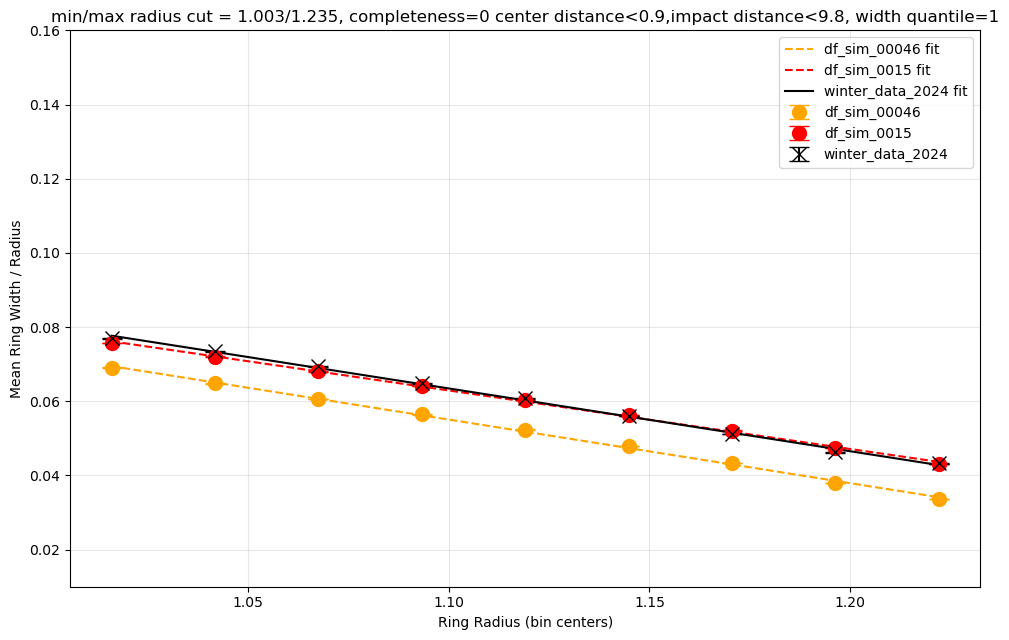

In [ ]:
# Here one can choose what dataset to plot by setting flag = True
df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'df_sim_no_int_corr': False,
    'winter_data_2024': True
}

plt.figure(figsize=(10, 6.5))

# Plotting cycle
for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name], label=f'{name} fit')

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.16)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()  # Adjust layout for better spacing
plt.show()



This script below is standard throughput this notebook and it processes and plots data from various datasets. It prints information about the data and simulation for mirror alignment and plots specified columns.

**Variables**

- **`name_of_columns`** (`list`):  
  List of column names from muon fits tables to be plotted.

- **`cut_datasets`** (`dict`):  
  Dictionary containing datasets to be processed.

- **`df_to_plot`** (`dict`):  
  Dictionary indicating which datasets to plot.

**Functions**

- **`plot_columns(df1, df2, columns, df_name)`**:  
  Function to plot specified columns from two dataframes.



-----------> Data + Simulation for mirror alignment 00046 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0 
center distance<0.9,
impact distance<9.8, 
width quantile=1




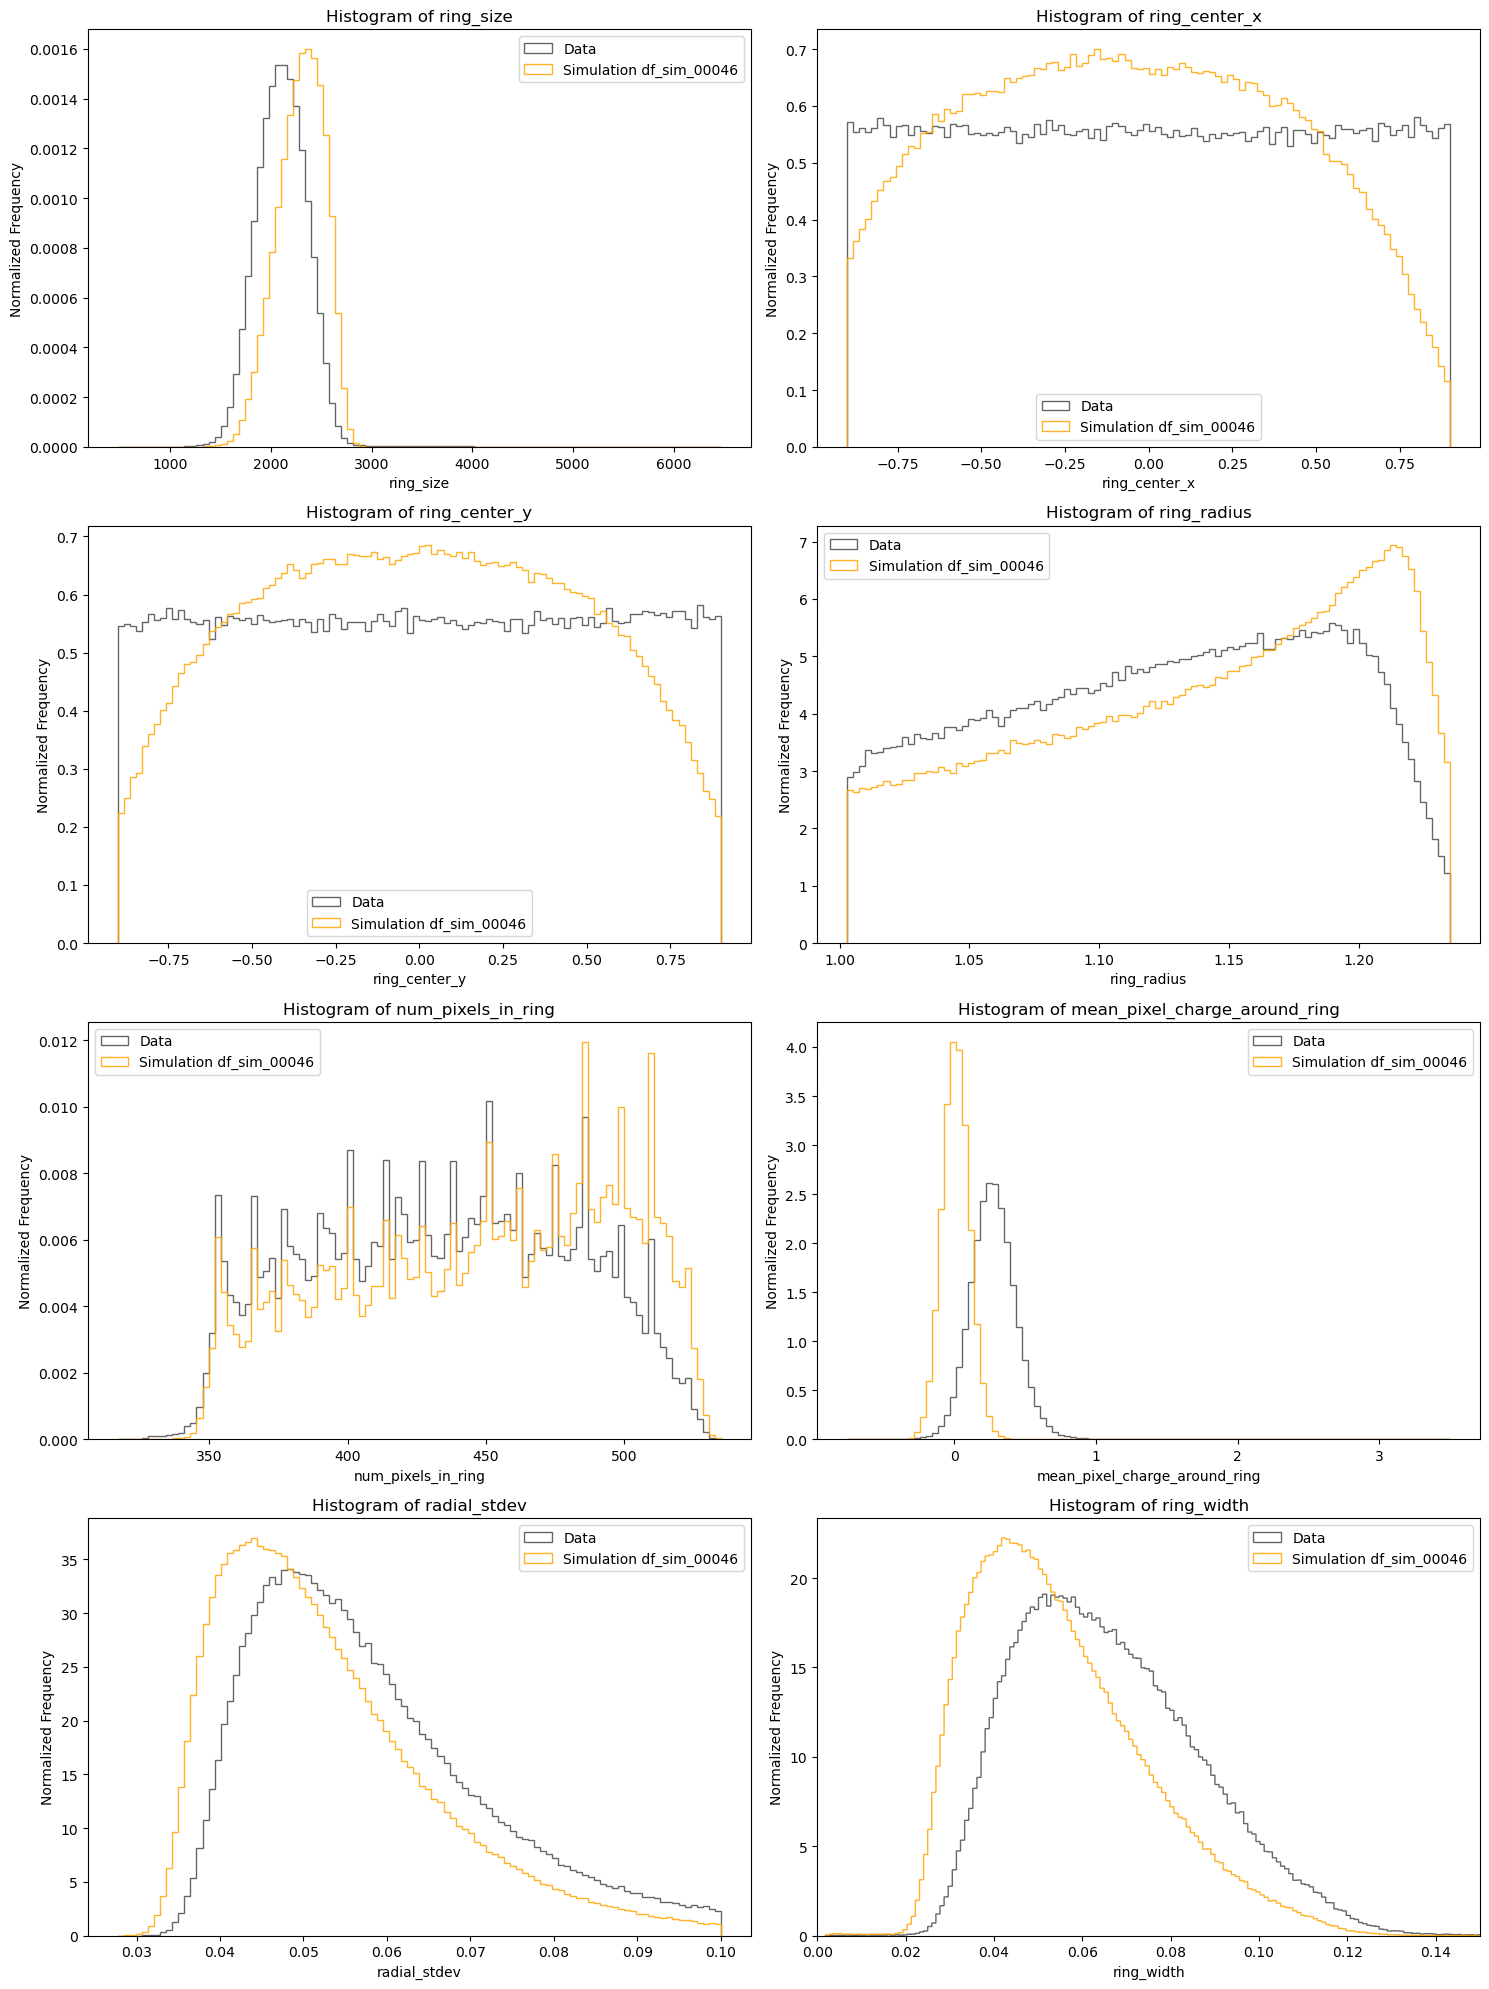



-----------> Data + Simulation for mirror alignment _0015 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0 
center distance<0.9,
impact distance<9.8, 
width quantile=1




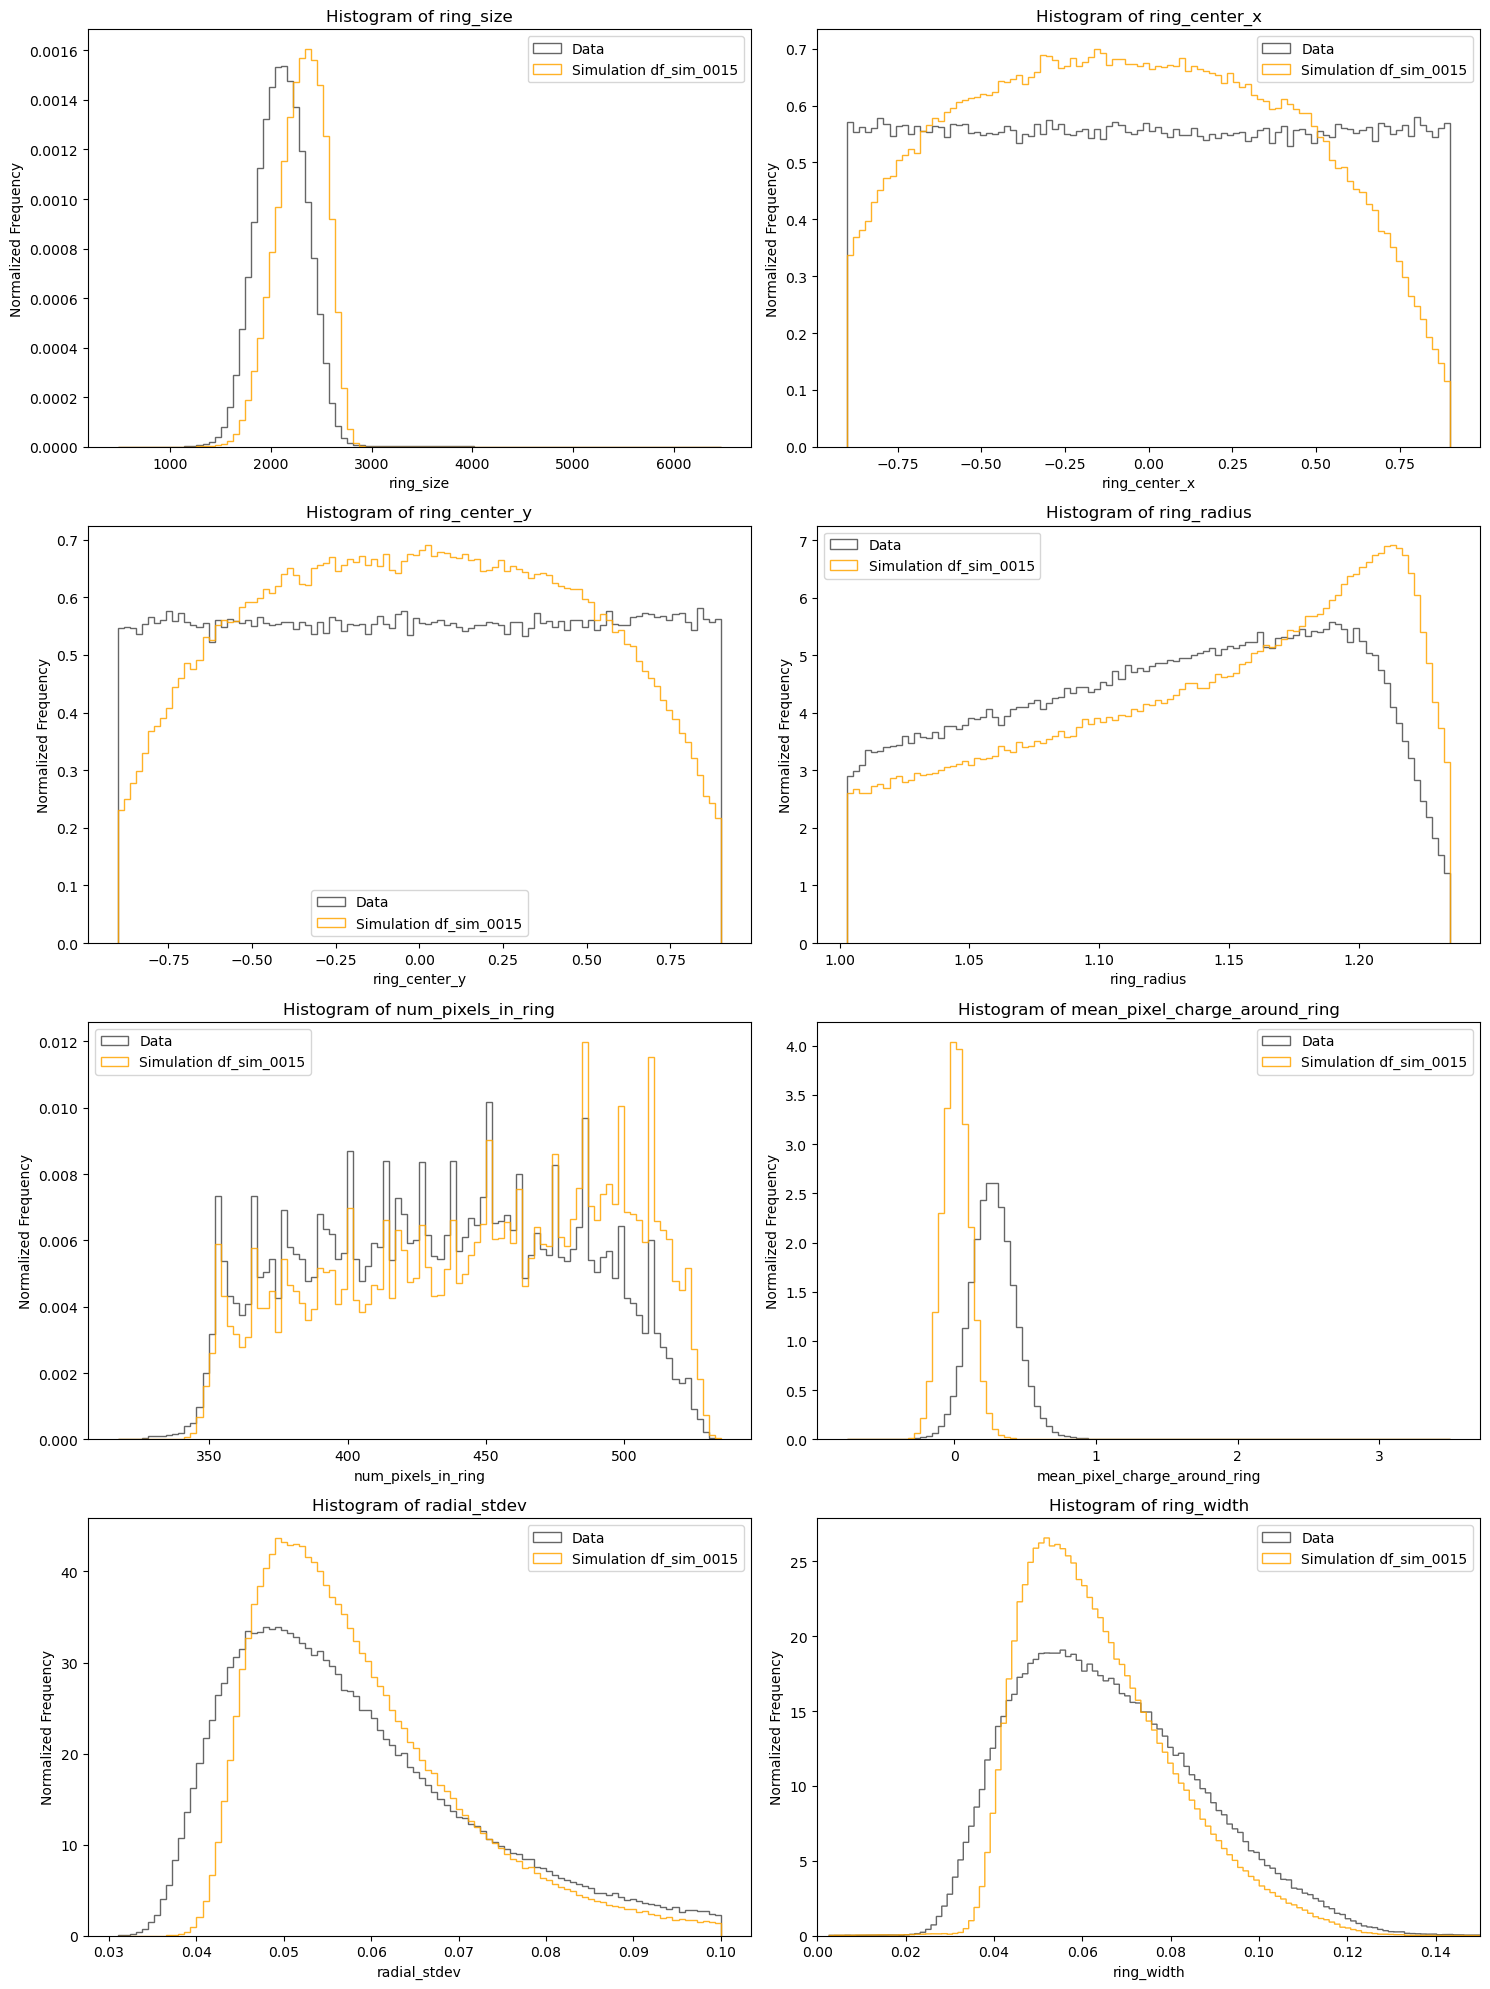

In [14]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']

for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('-----------> Data + Simulation for mirror alignment', name[-5:], 'deg <--------------\n')
        print(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, \ncompleteness>{ring_completeness_cut} \ncenter distance<{ring_center_distance_cut},\nimpact distance<{impact_distance_cut}, \nwidth quantile={QUANTILE_CUT}')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name)

# #2 Basic distributions cuts (added cut on ring completeness > 0.9)

In [15]:
QUANTILE_CUT = 1

ring_completeness_cut = 0.9
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 31284 (2.77%)
Events survived for df_sim_00046: 42578 (3.01%)
Events survived for df_sim_00092: 50123 (3.75%)
Events survived for df_sim_0015: 81135 (7.55%)
Events survived for df_sim_002: 135897 (10.21%)
Events survived for winter_data_2024: 11366 (0.75%)


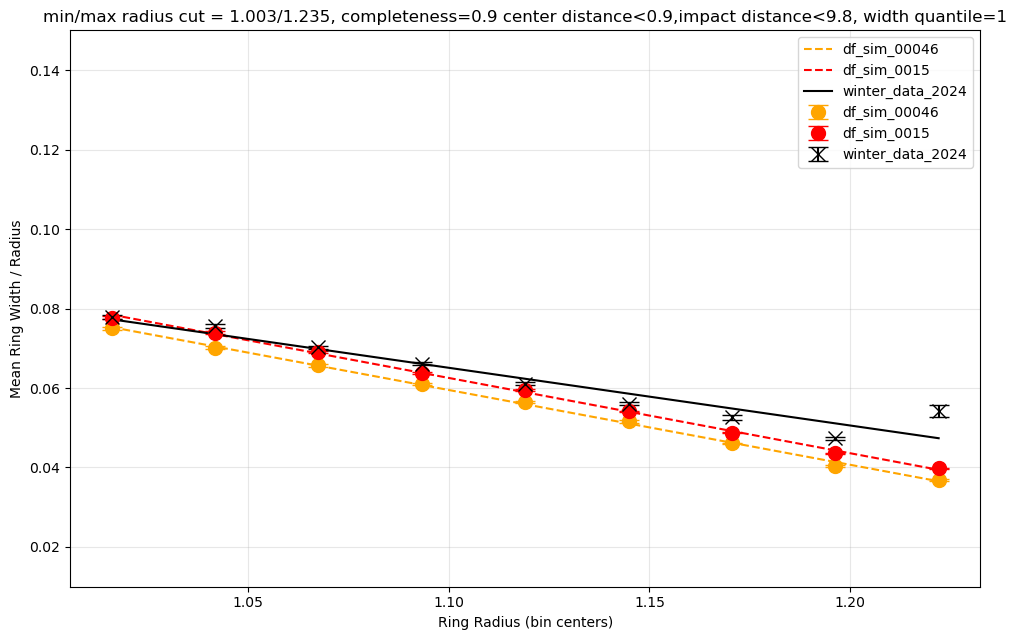

In [16]:
df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name], label=name)

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.15)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



-----------> Data + Simulation for mirror alignment 00046 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.9 
center distance<0.9,
impact distance<9.8, 
width quantile=1




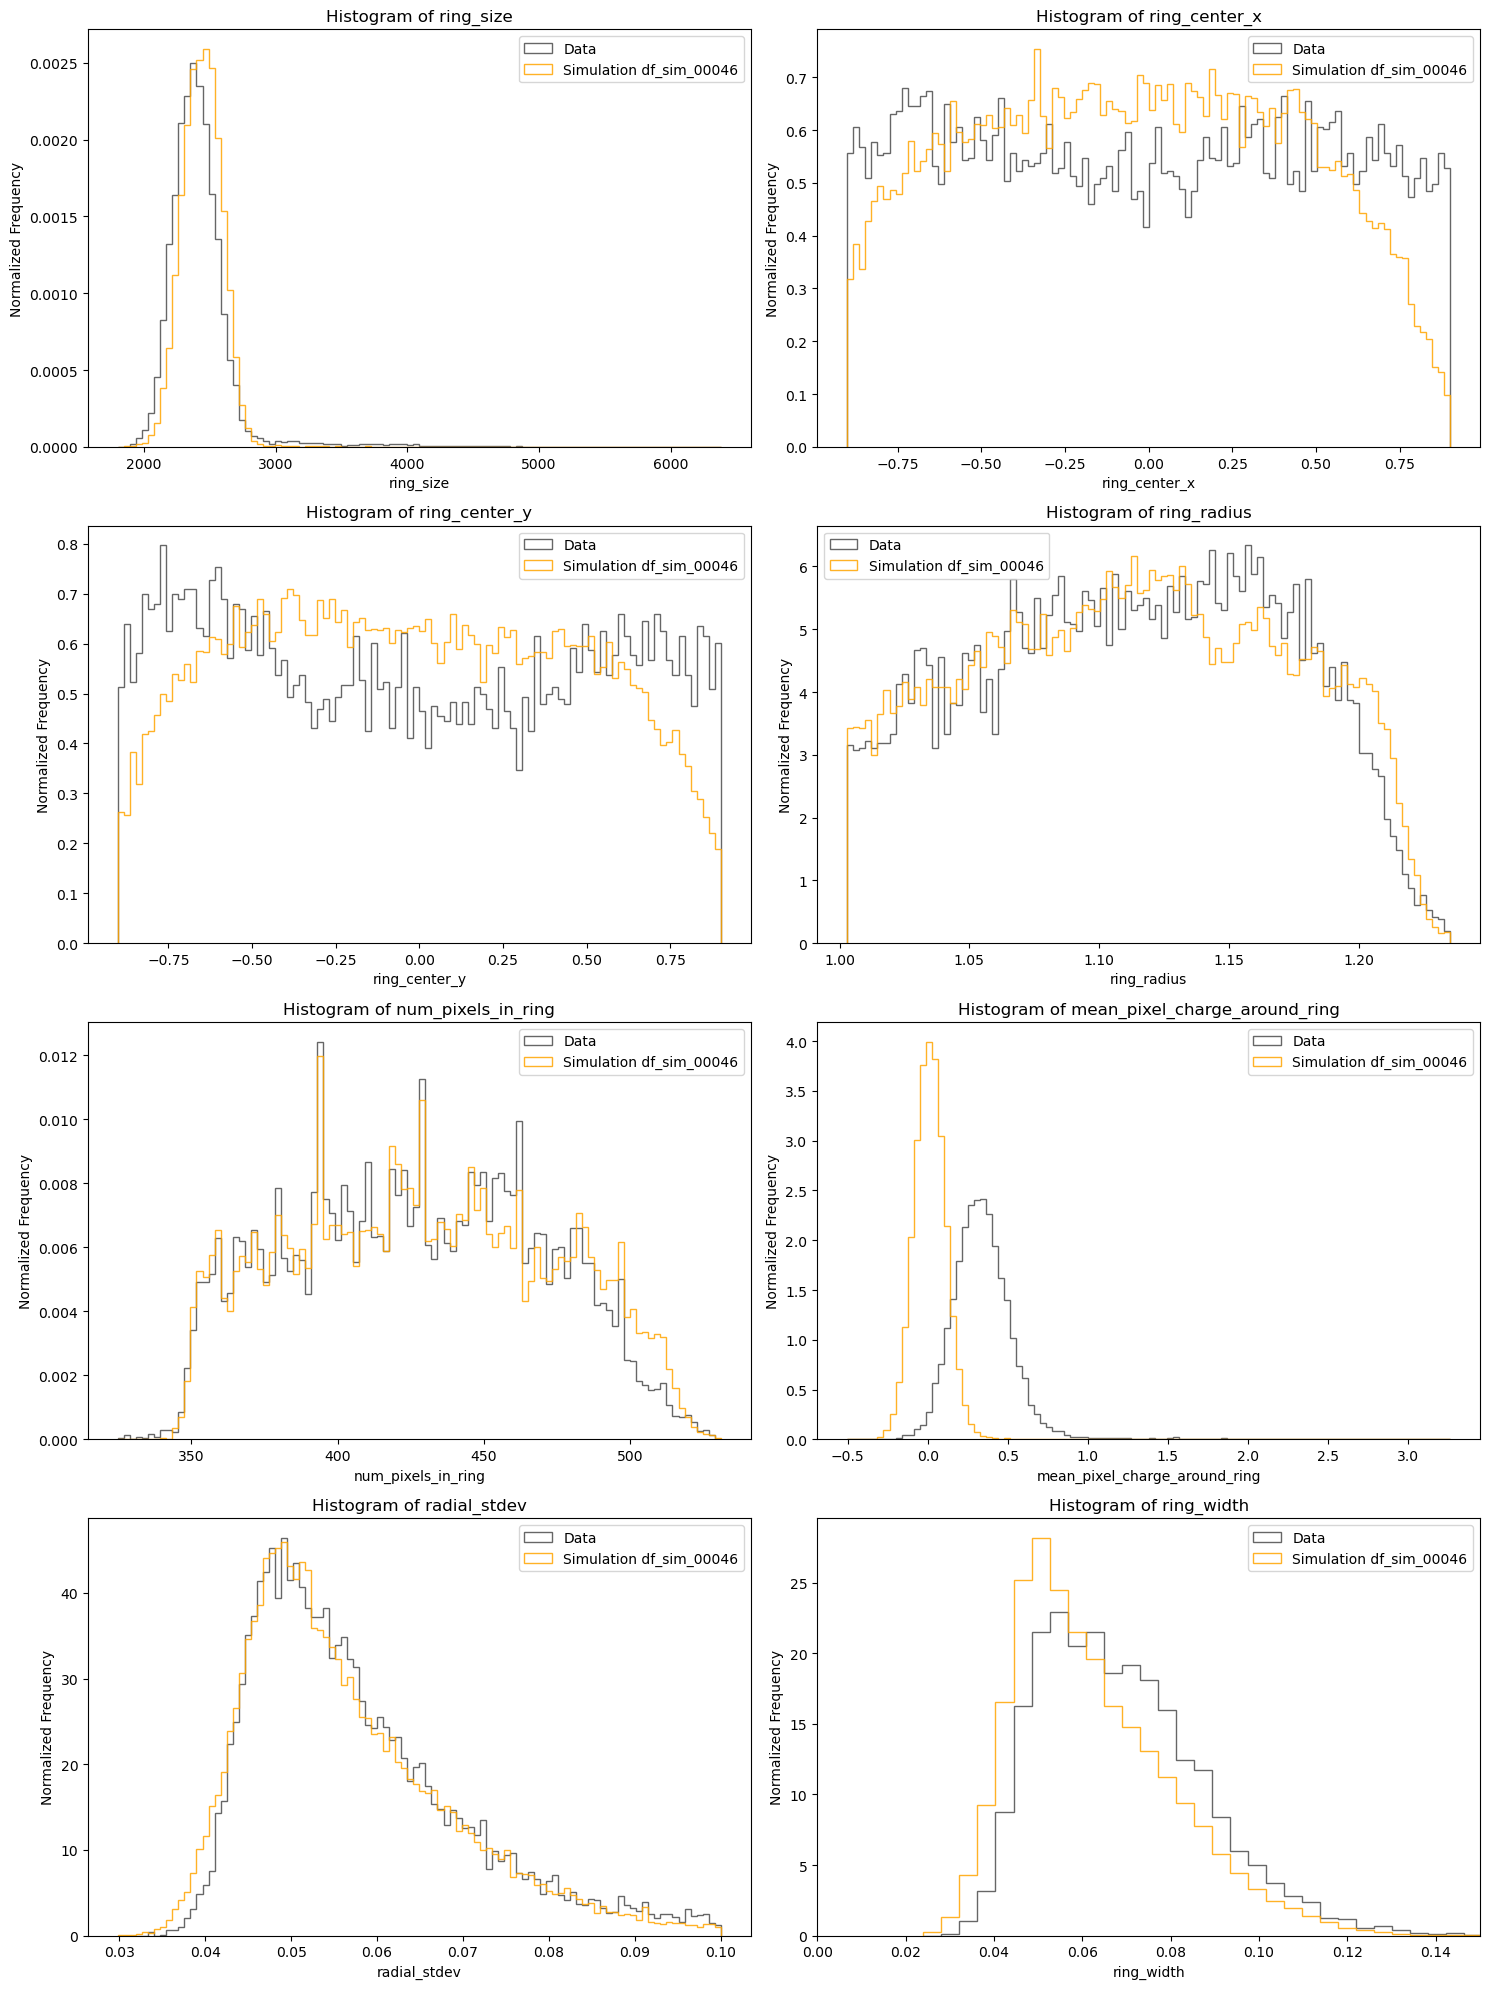



-----------> Data + Simulation for mirror alignment _0015 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.9 
center distance<0.9,
impact distance<9.8, 
width quantile=1




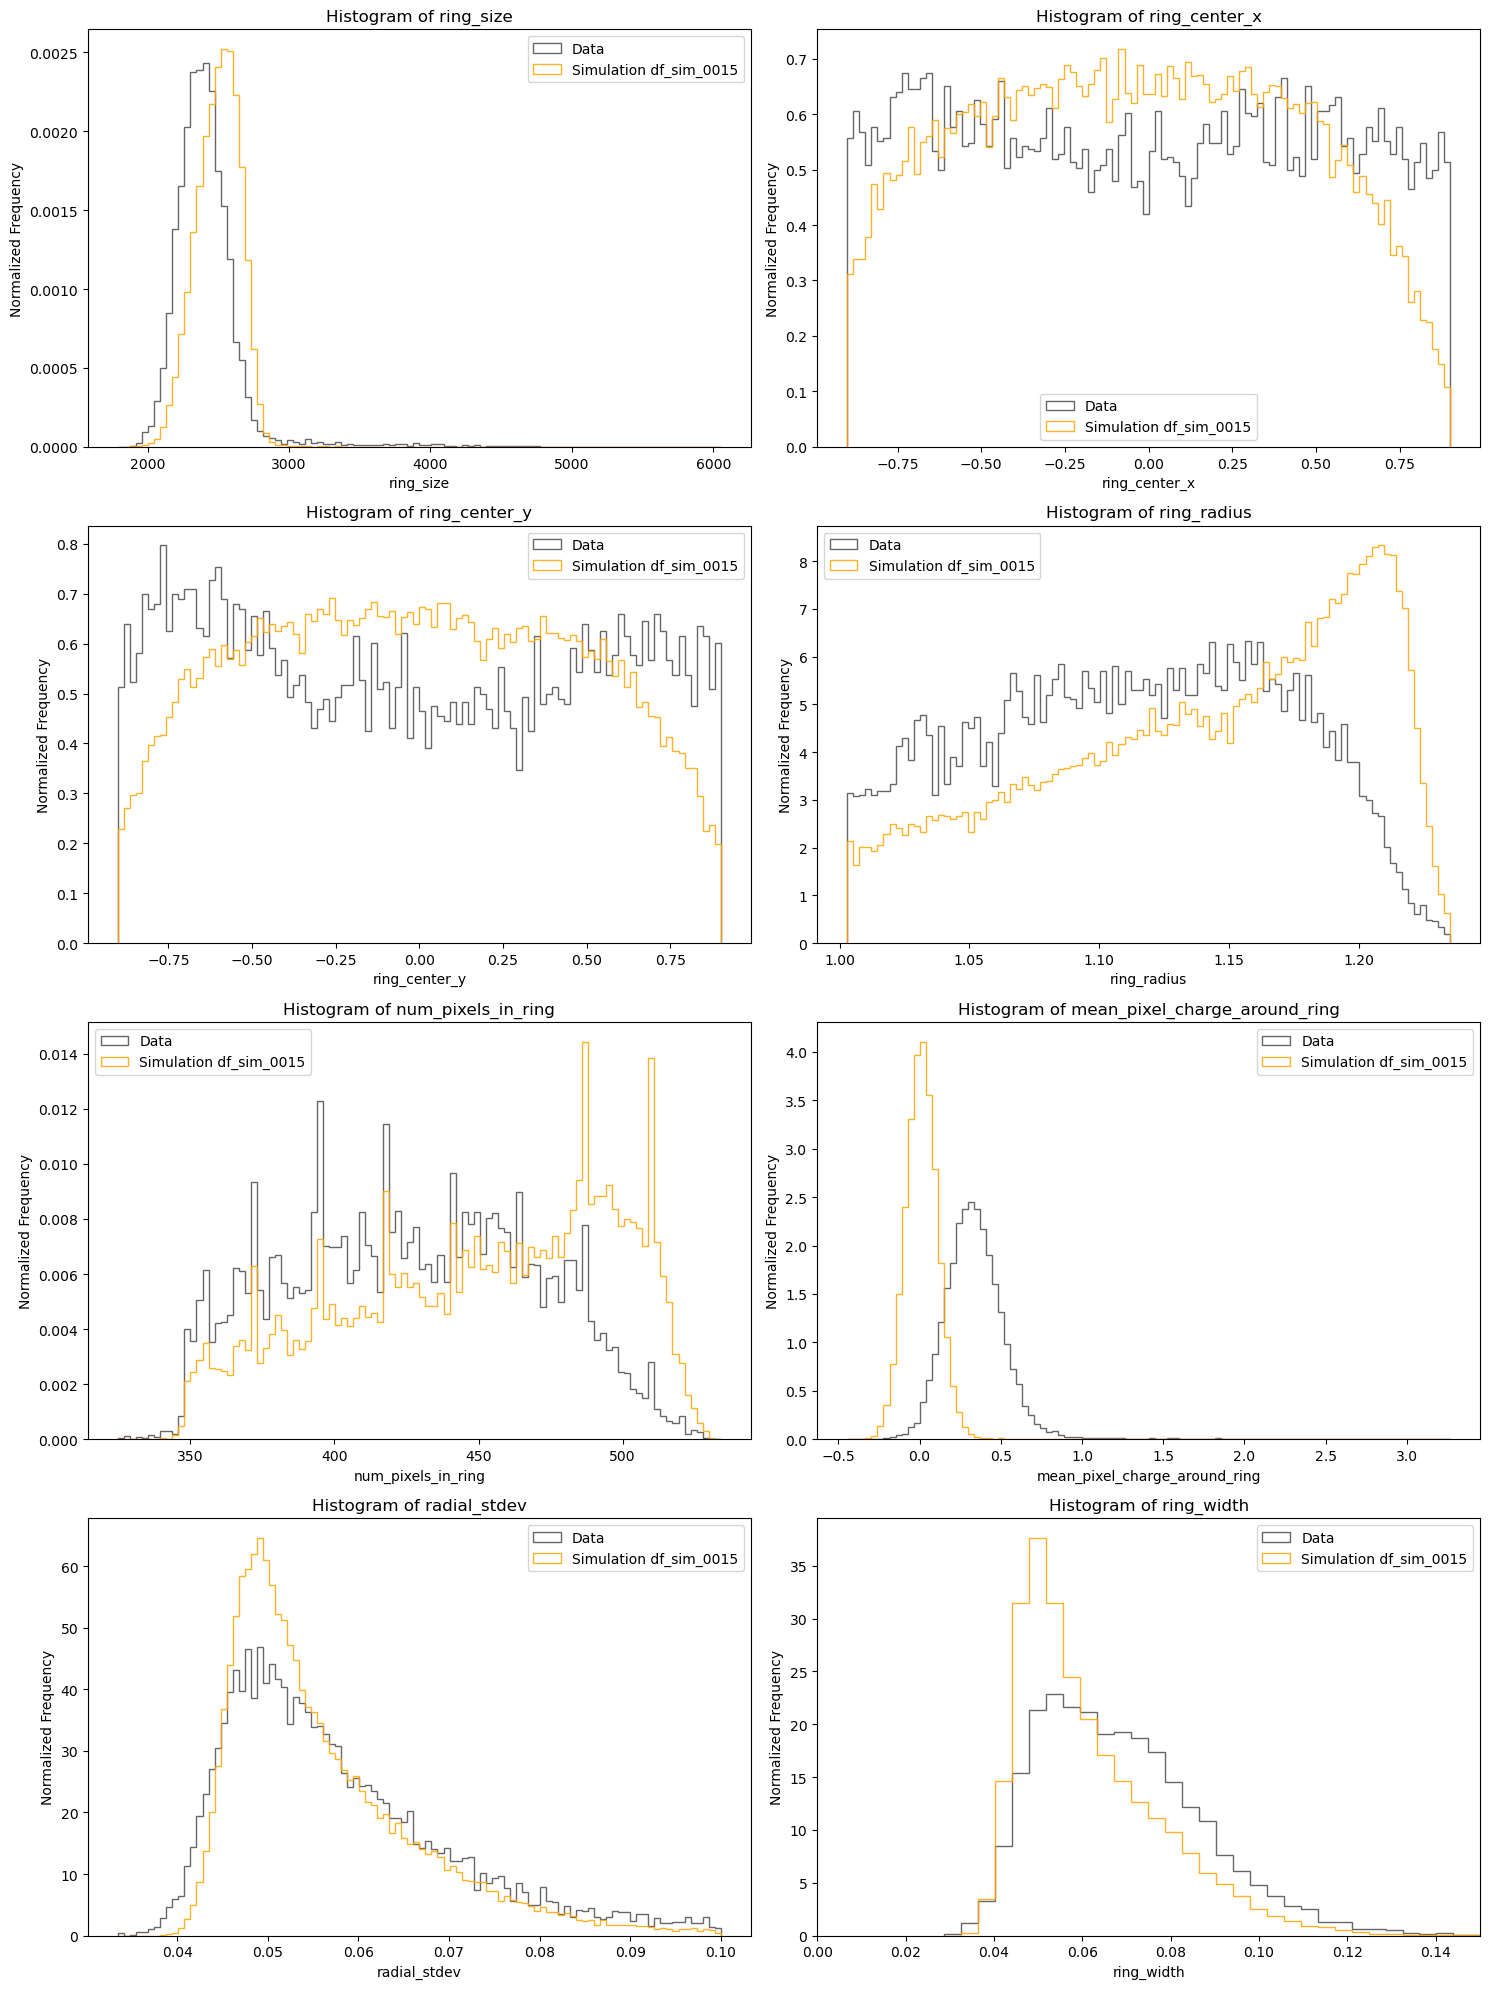

In [17]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('-----------> Data + Simulation for mirror alignment', name[-5:], 'deg <--------------\n')
        print(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, \ncompleteness>{ring_completeness_cut} \ncenter distance<{ring_center_distance_cut},\nimpact distance<{impact_distance_cut}, \nwidth quantile={QUANTILE_CUT}')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name)

## #2.1 completeness > 0.8

In [18]:
QUANTILE_CUT = 1

ring_completeness_cut = 0.8
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 176778 (15.65%)
Events survived for df_sim_00046: 238290 (16.84%)
Events survived for df_sim_00092: 275976 (20.66%)
Events survived for df_sim_0015: 324109 (30.14%)
Events survived for df_sim_002: 438315 (32.94%)
Events survived for winter_data_2024: 53499 (3.51%)


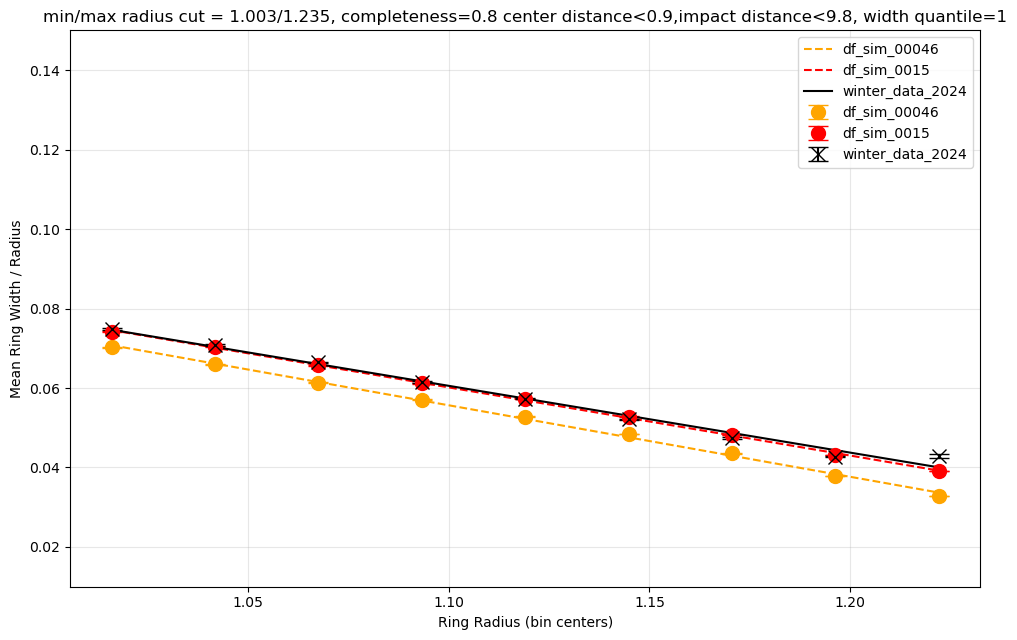

In [19]:
df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name], label=name)

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.15)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



-----------> Data + Simulation for mirror alignment 00046 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.8 
center distance<0.9,
impact distance<9.8, 
width quantile=1




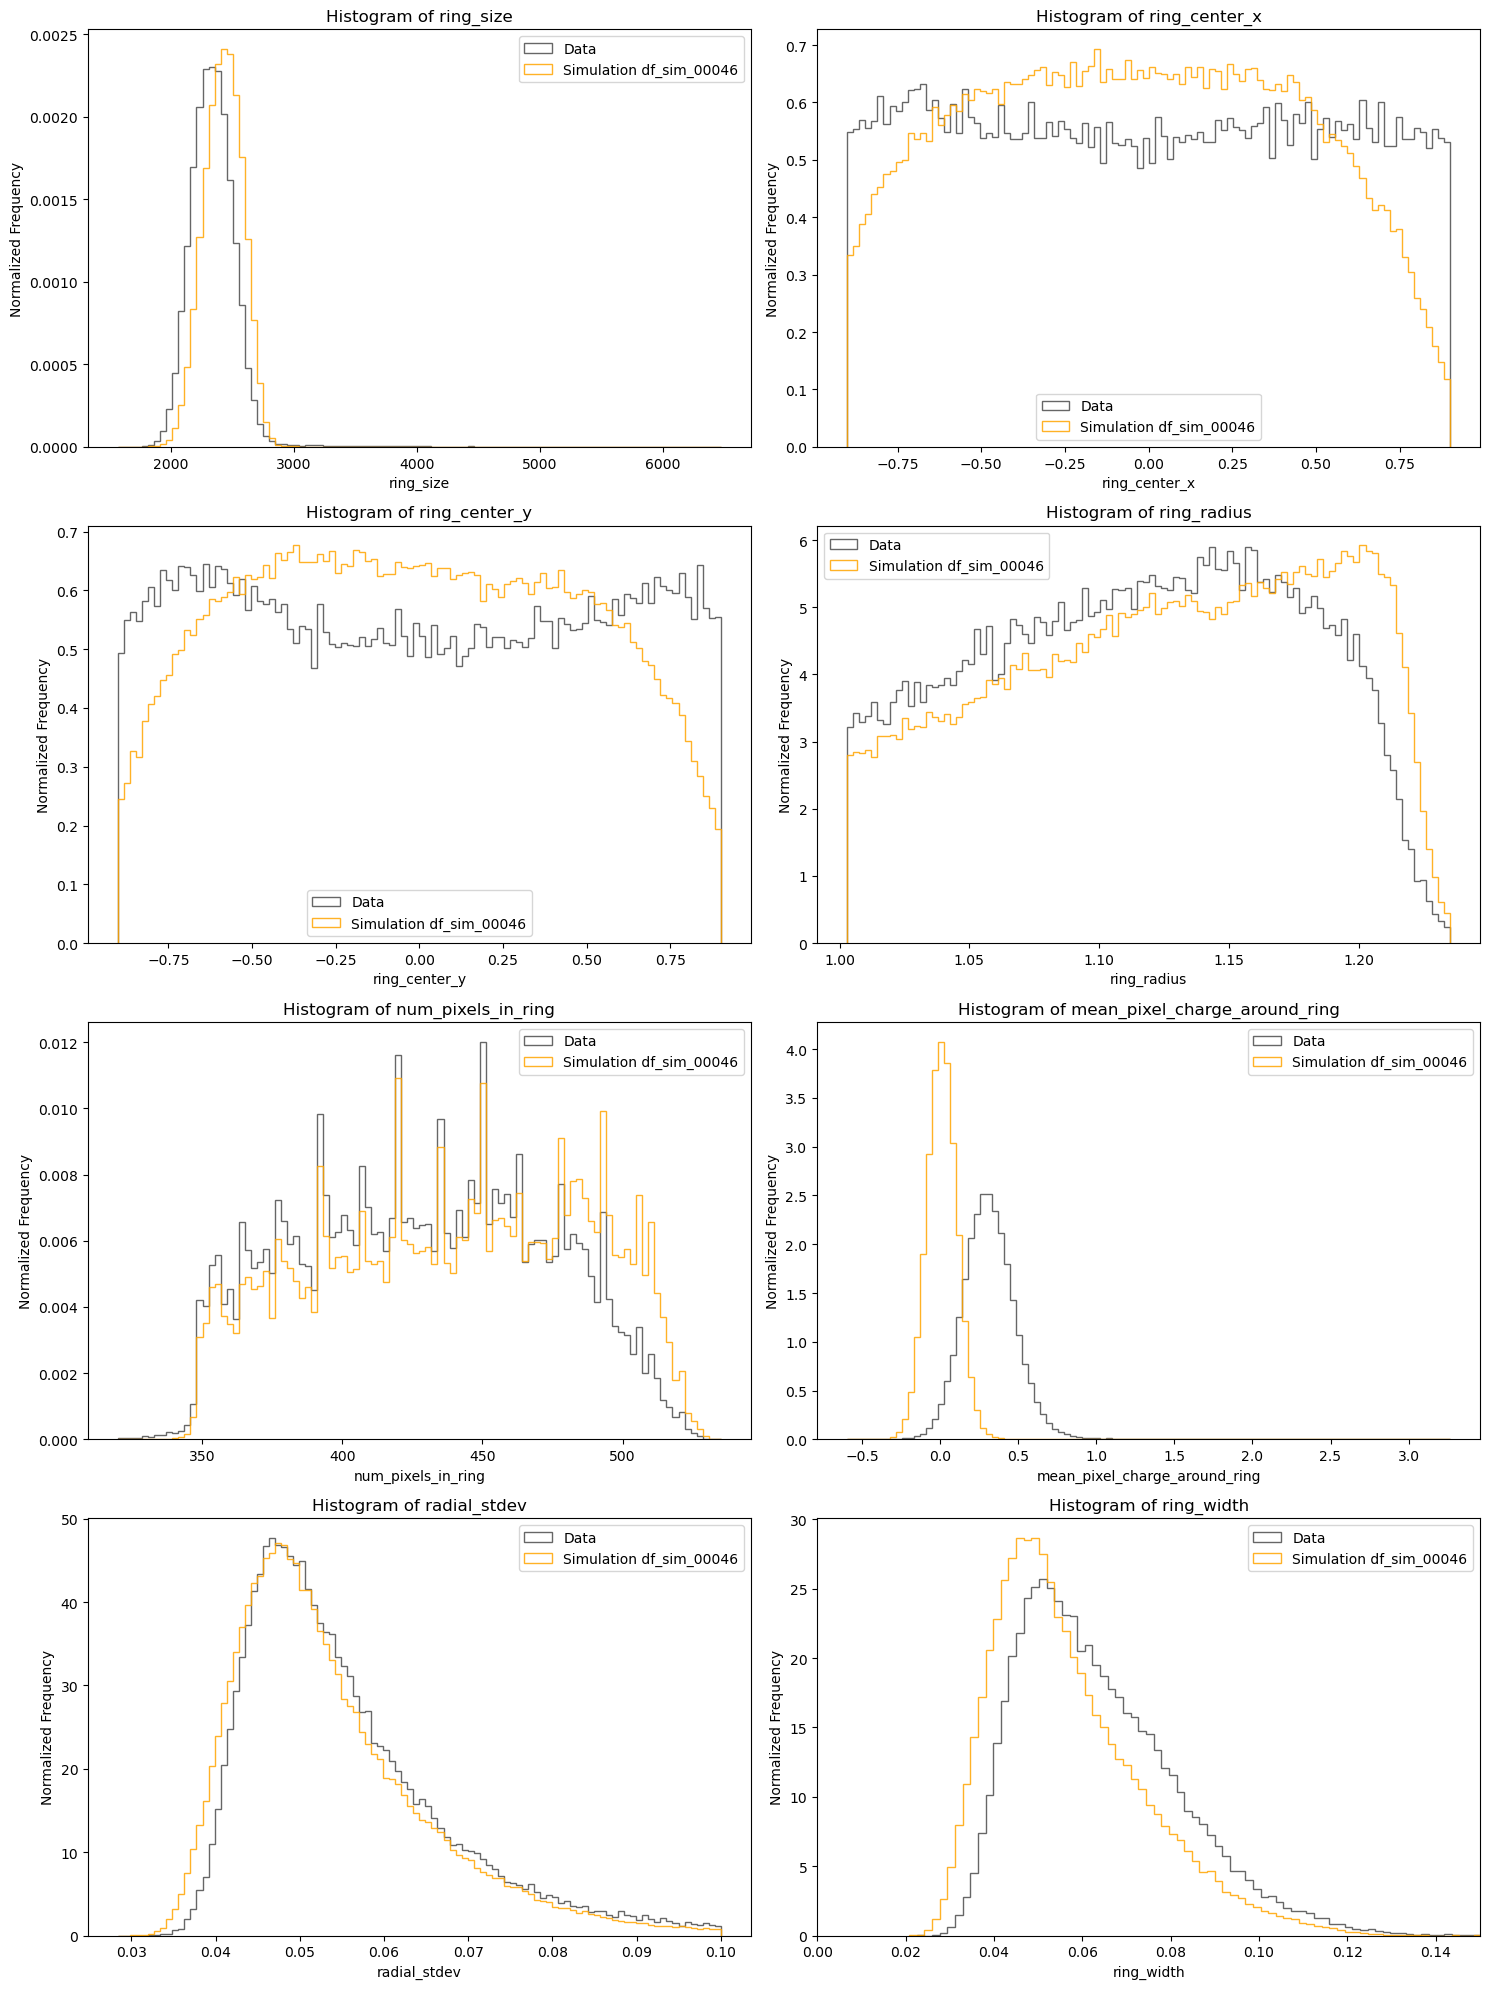



-----------> Data + Simulation for mirror alignment _0015 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.8 
center distance<0.9,
impact distance<9.8, 
width quantile=1




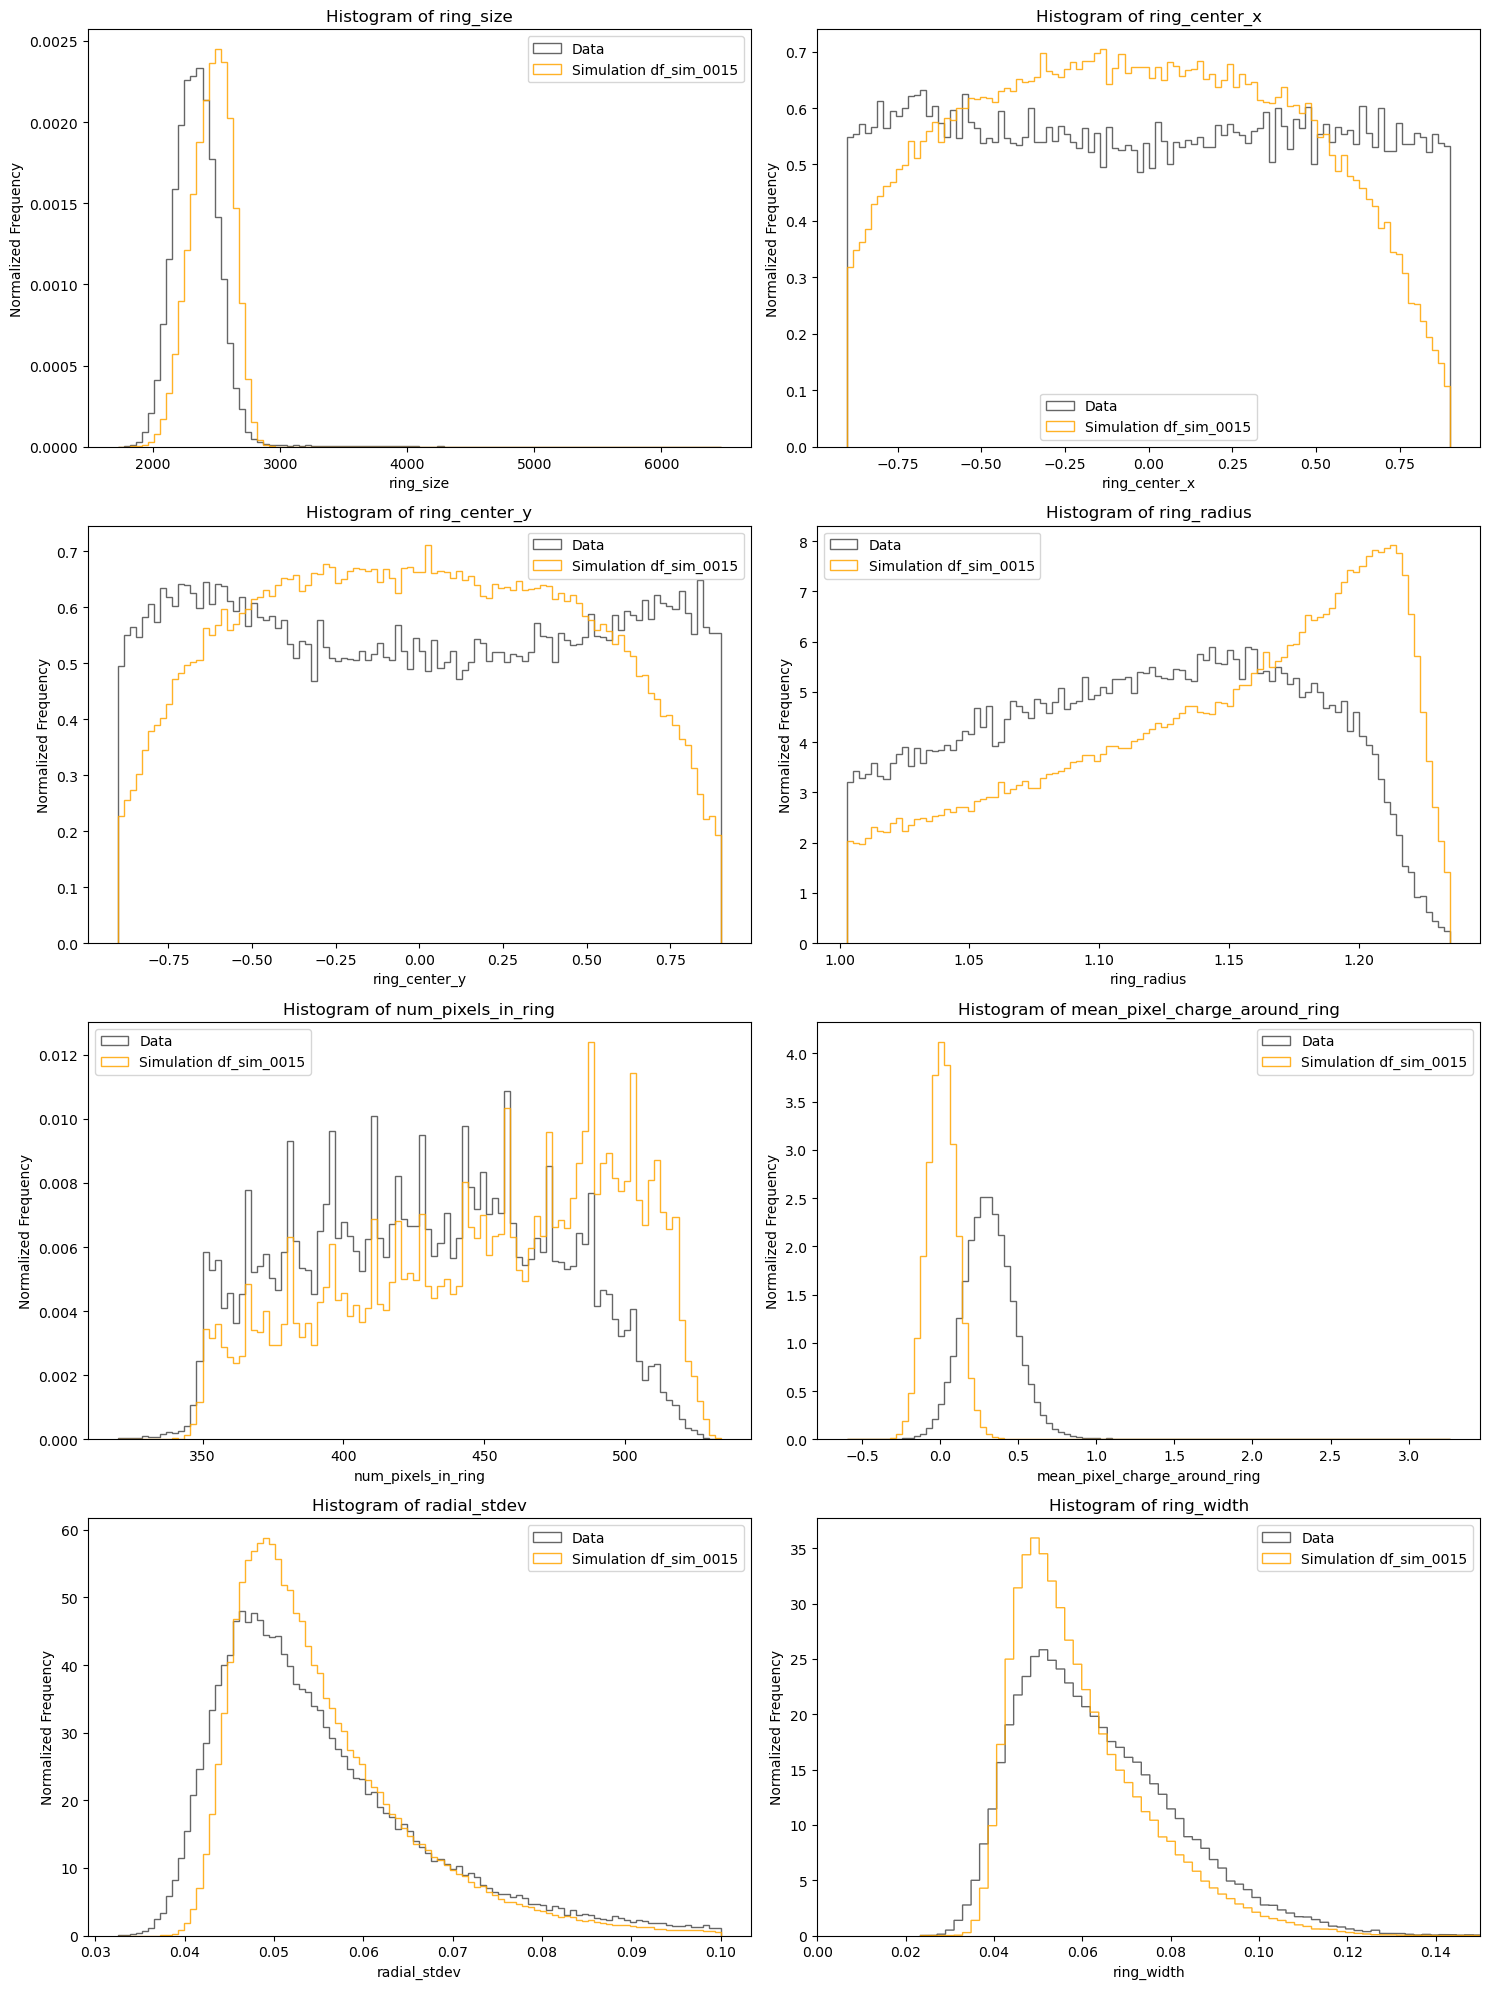

In [20]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('-----------> Data + Simulation for mirror alignment', name[-5:], 'deg <--------------\n')
        print(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, \ncompleteness>{ring_completeness_cut} \ncenter distance<{ring_center_distance_cut},\nimpact distance<{impact_distance_cut}, \nwidth quantile={QUANTILE_CUT}')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name)

## #2.2 completeness > 0.85

In [21]:
QUANTILE_CUT = 1

ring_completeness_cut = 0.85
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 113173 (10.02%)
Events survived for df_sim_00046: 153342 (10.84%)
Events survived for df_sim_00092: 181014 (13.55%)
Events survived for df_sim_0015: 238324 (22.16%)
Events survived for df_sim_002: 340681 (25.60%)
Events survived for winter_data_2024: 36331 (2.39%)


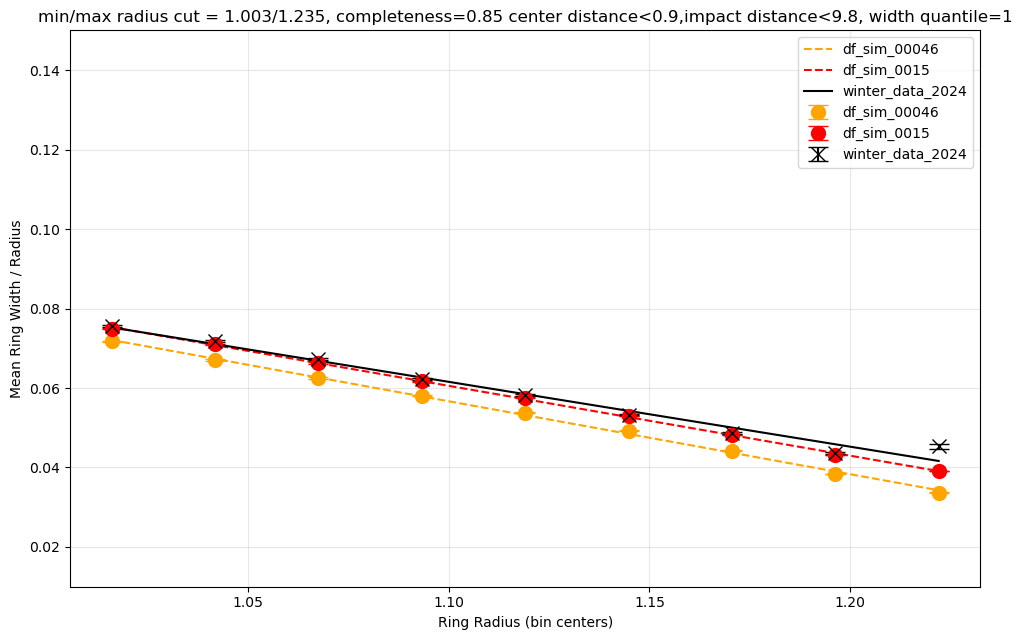

In [22]:
df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name], label=name)

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.15)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



-----------> Data + Simulation for mirror alignment 00046 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.85 
center distance<0.9,
impact distance<9.8, 
width quantile=1




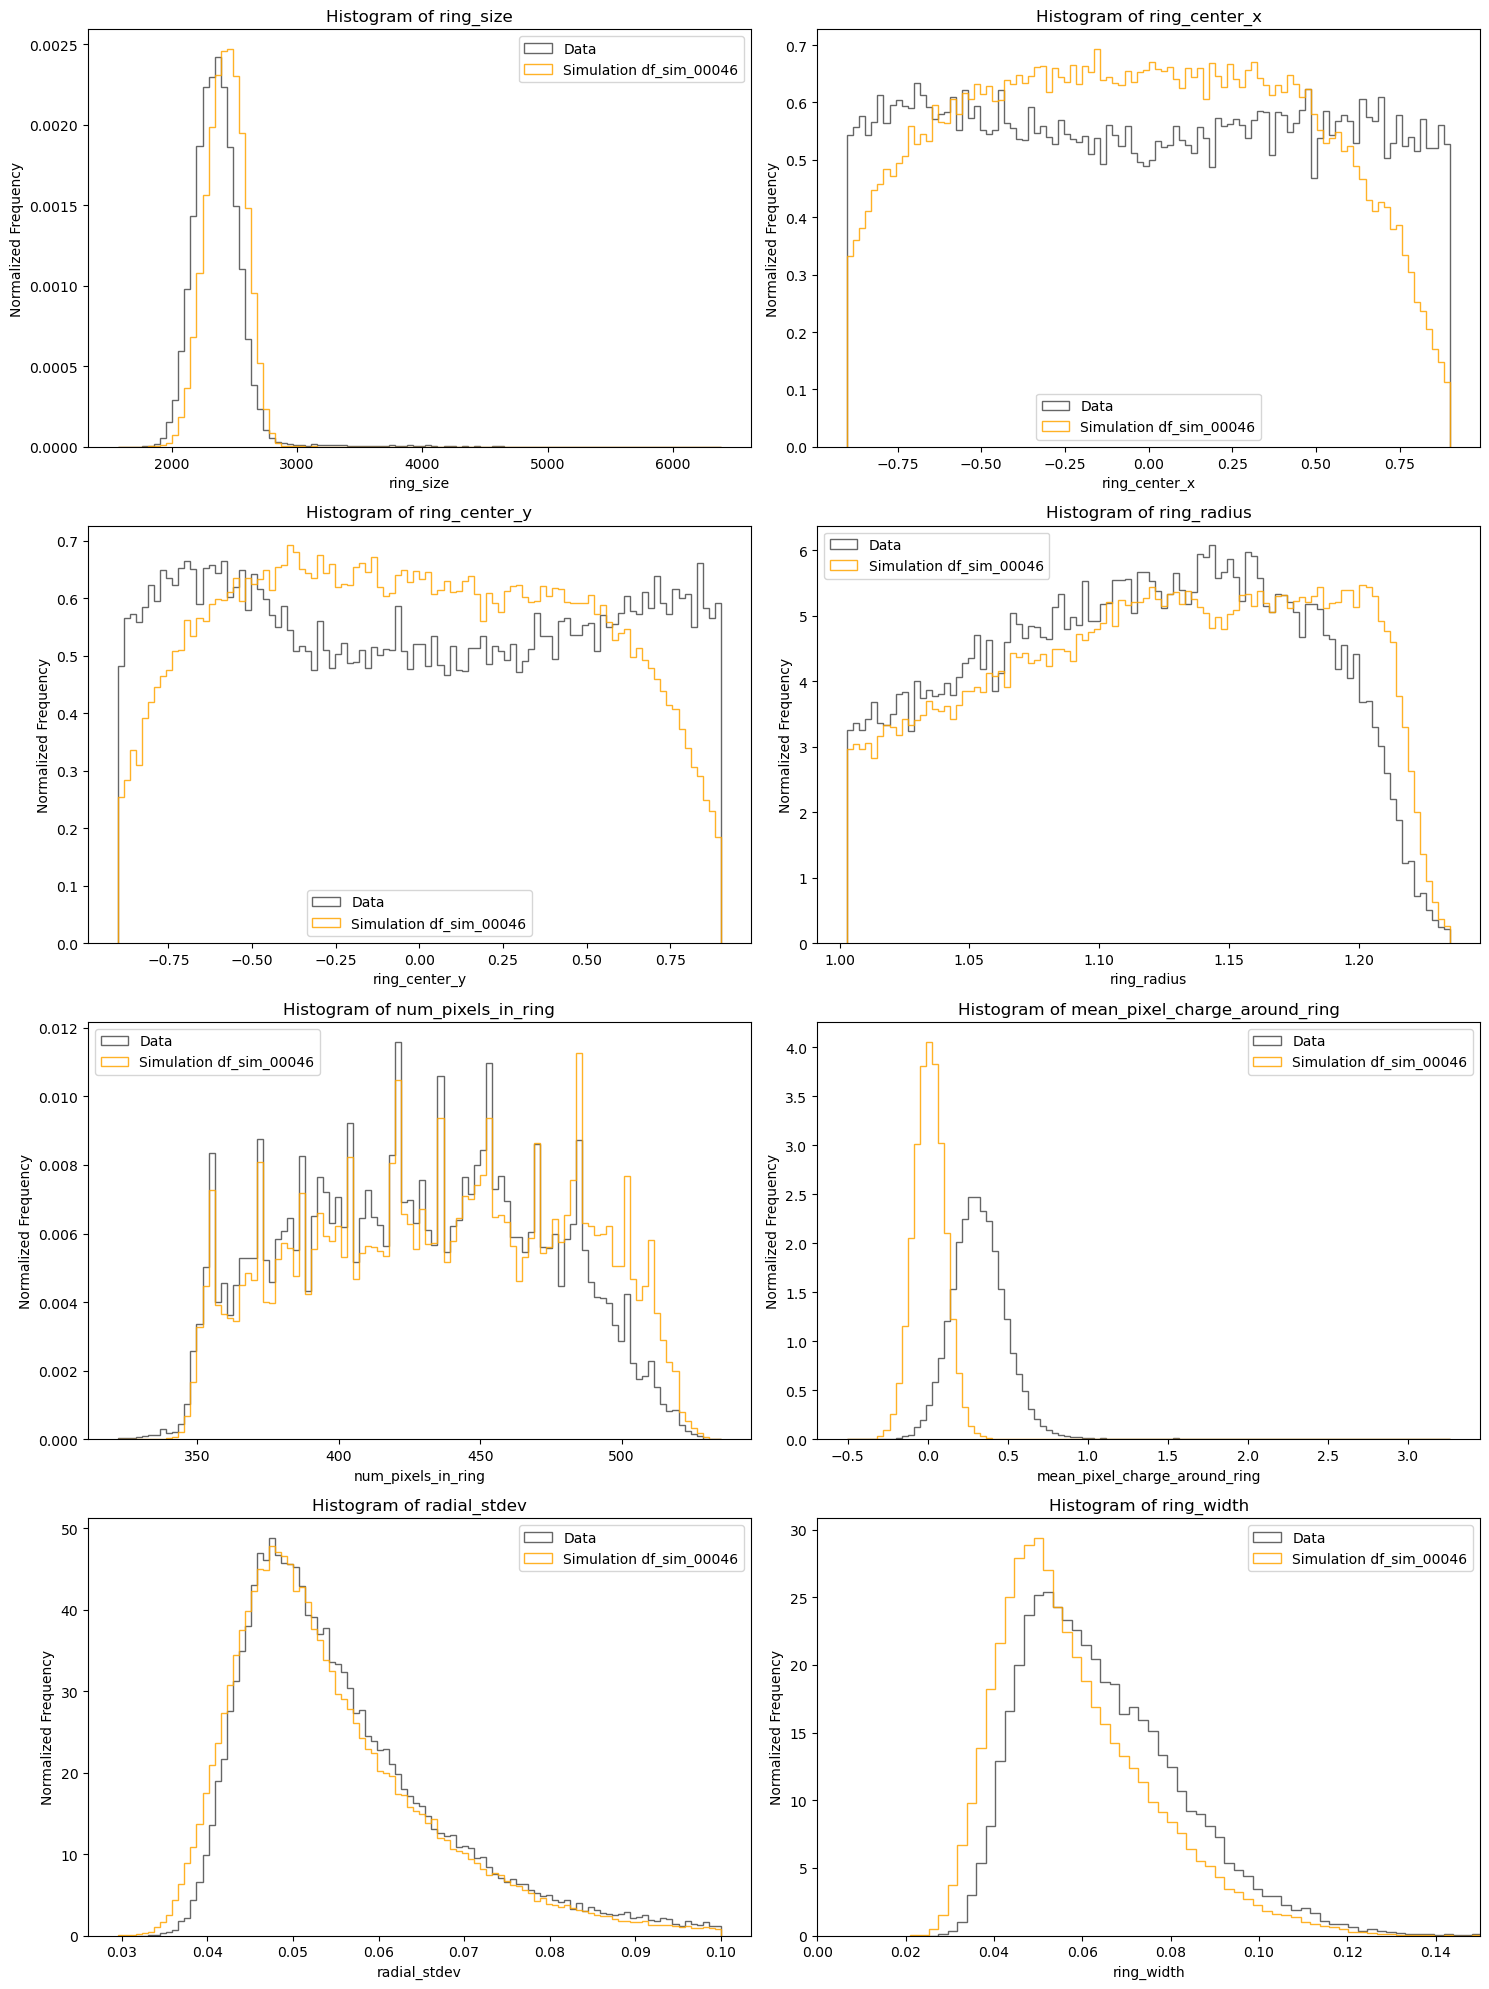



-----------> Data + Simulation for mirror alignment _0015 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.85 
center distance<0.9,
impact distance<9.8, 
width quantile=1




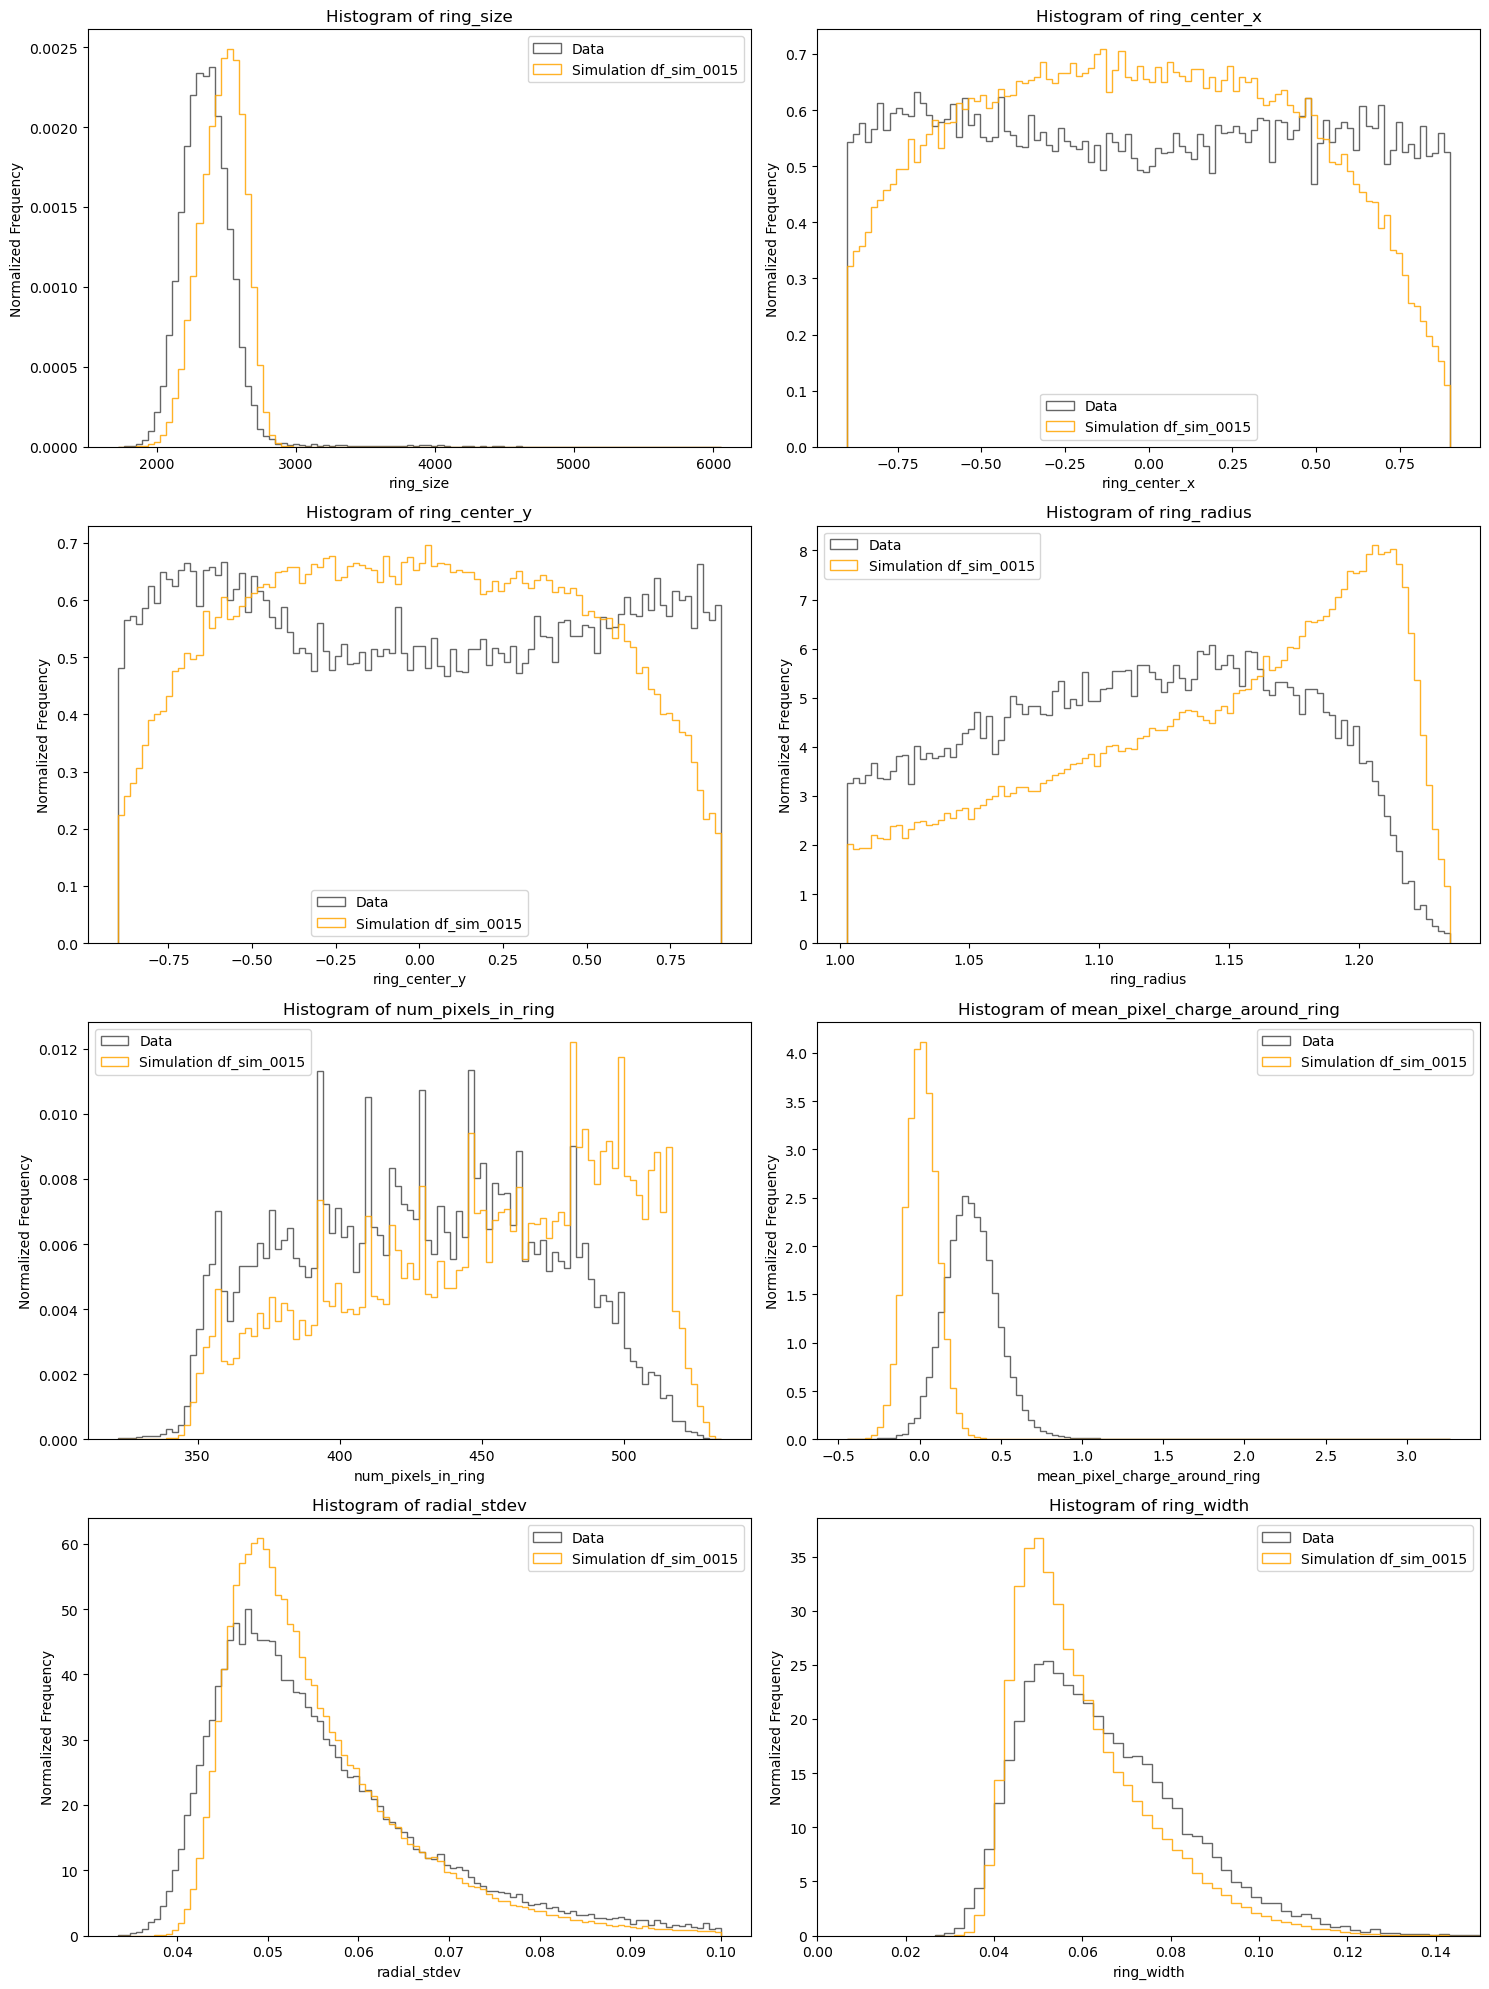

In [23]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('-----------> Data + Simulation for mirror alignment', name[-5:], 'deg <--------------\n')
        print(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, \ncompleteness>{ring_completeness_cut} \ncenter distance<{ring_center_distance_cut},\nimpact distance<{impact_distance_cut}, \nwidth quantile={QUANTILE_CUT}')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name)

## #2.3 completeness > 0.95

In [24]:
QUANTILE_CUT = 1

ring_completeness_cut = 0.95
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 12037 (1.07%)
Events survived for df_sim_00046: 16355 (1.16%)
Events survived for df_sim_00092: 18675 (1.40%)
Events survived for df_sim_0015: 31745 (2.95%)
Events survived for df_sim_002: 57515 (4.32%)
Events survived for winter_data_2024: 4544 (0.30%)


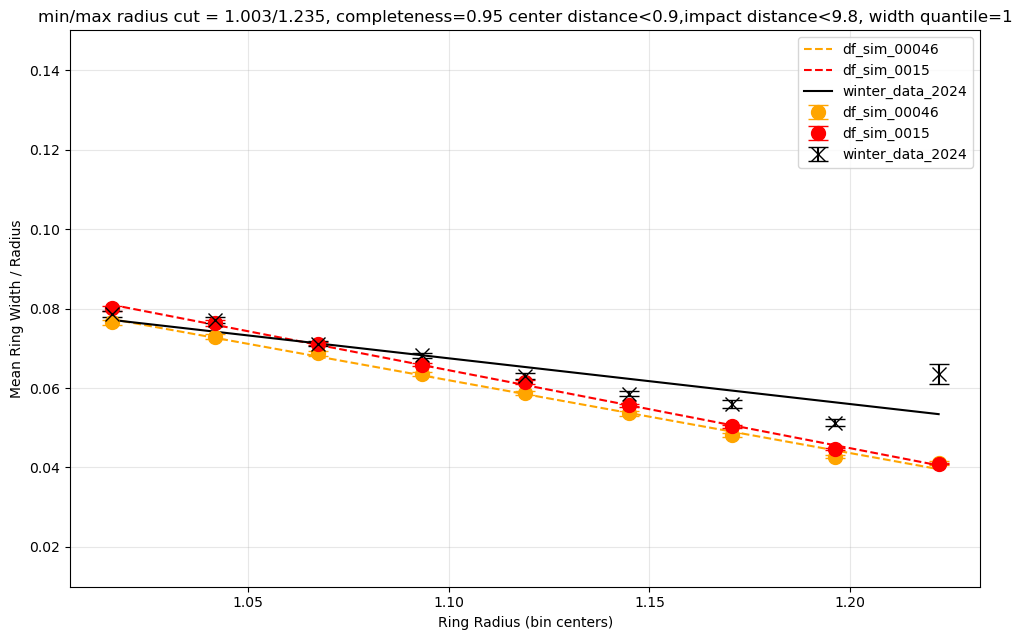

In [25]:
df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name], label=name)

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.15)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



-----------> Data + Simulation for mirror alignment 00046 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.95 
center distance<0.9,
impact distance<9.8, 
width quantile=1




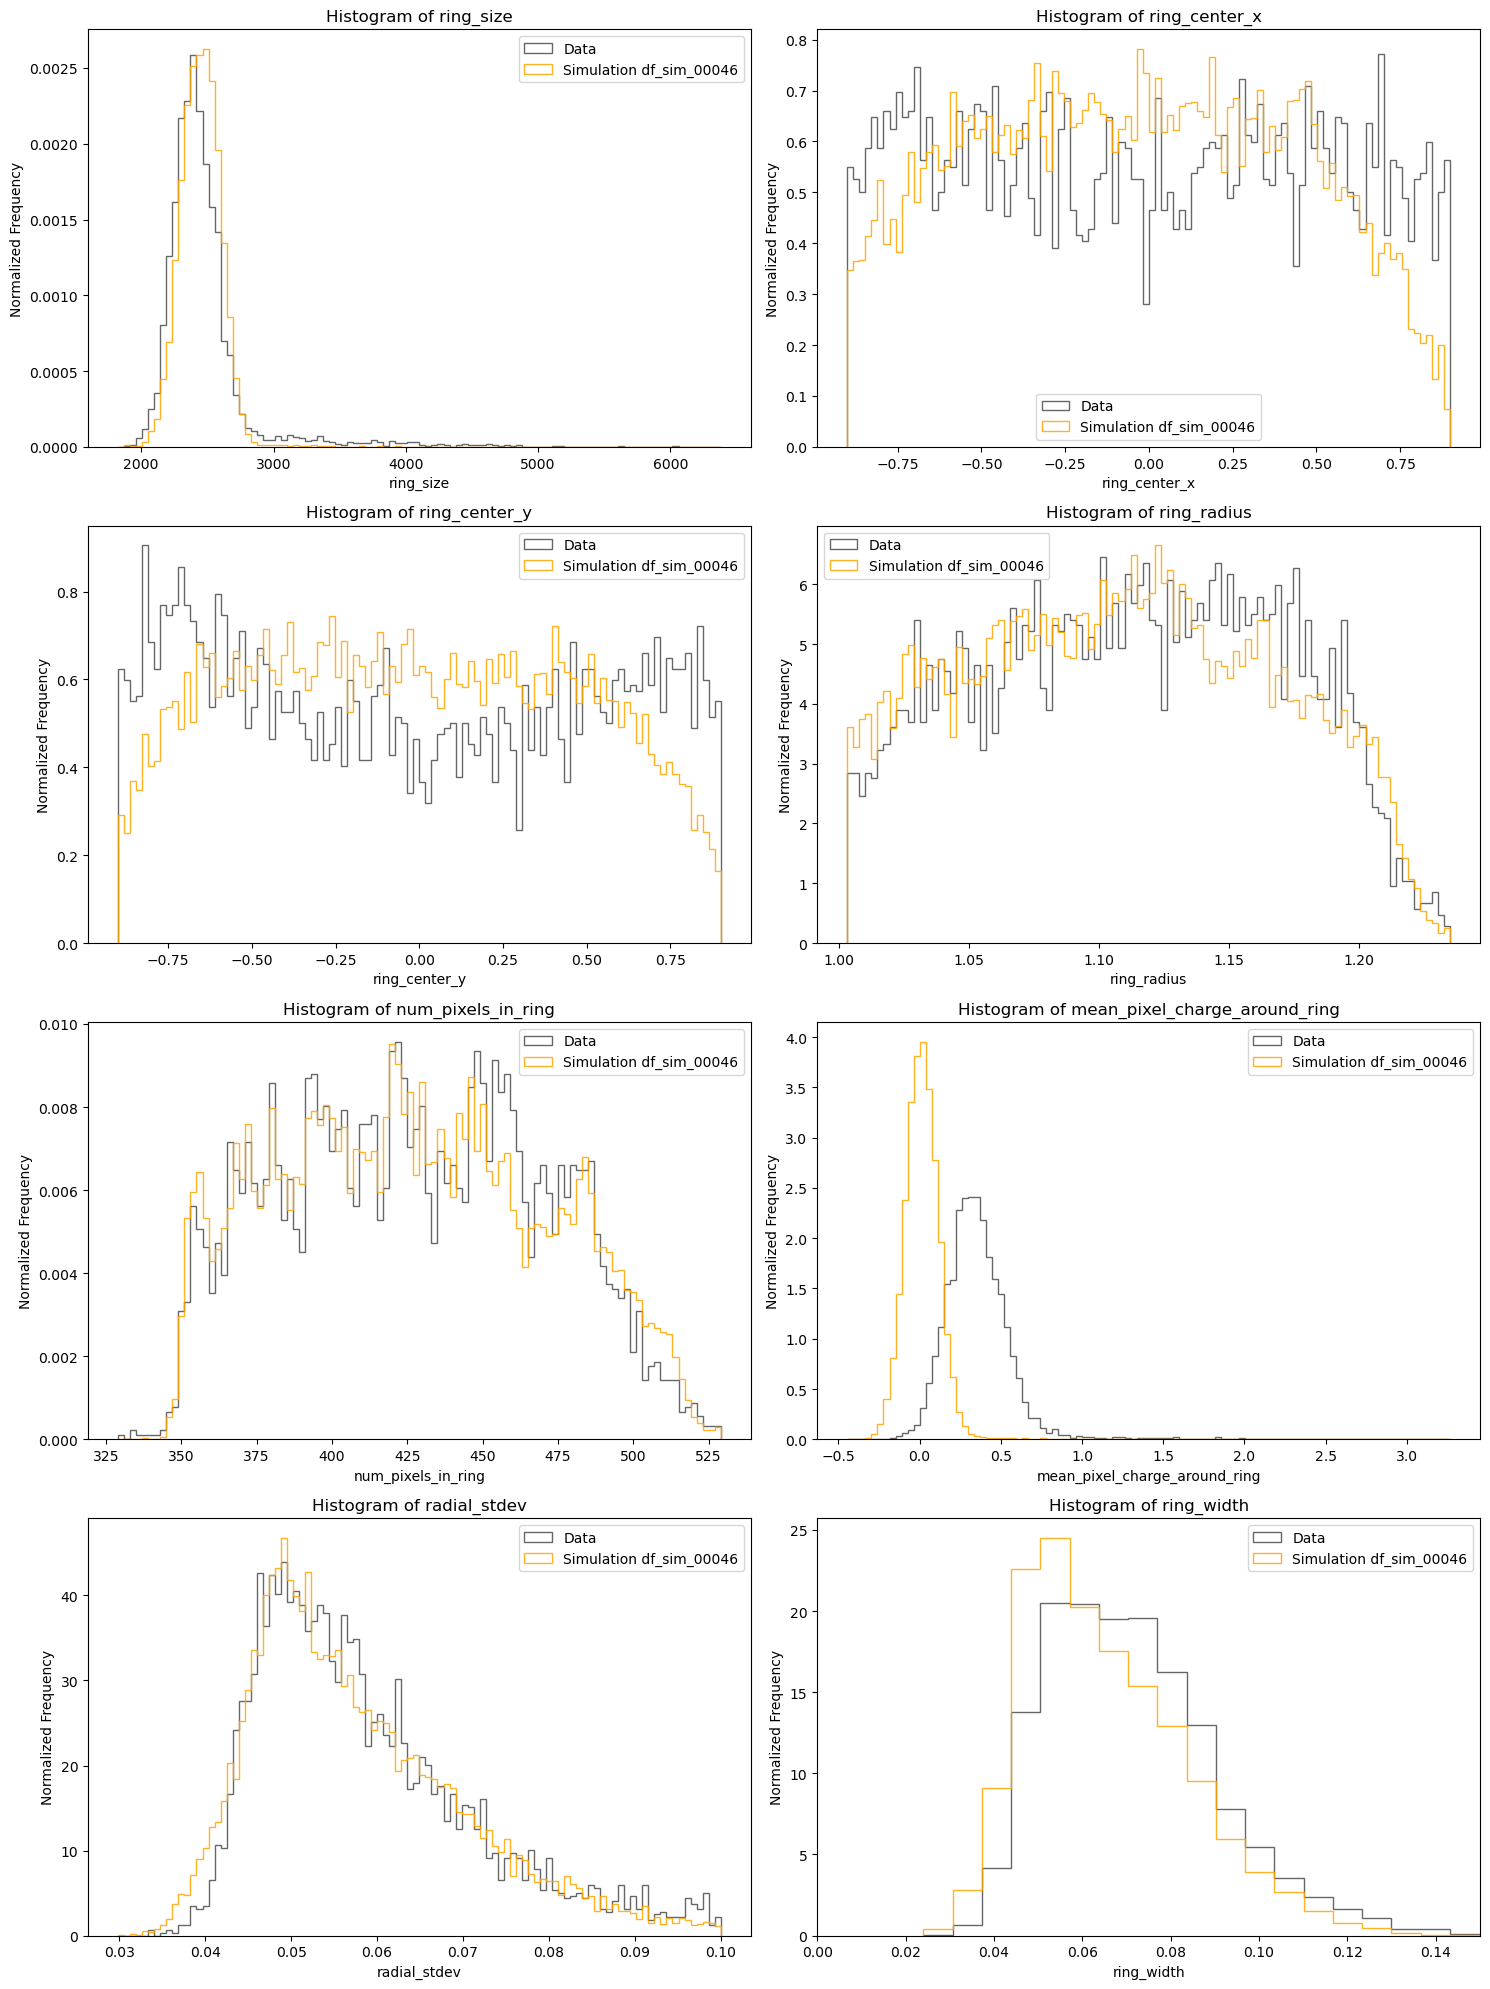



-----------> Data + Simulation for mirror alignment _0015 deg <--------------

min/max radius cut = 1.003/1.235, 
completeness>0.95 
center distance<0.9,
impact distance<9.8, 
width quantile=1




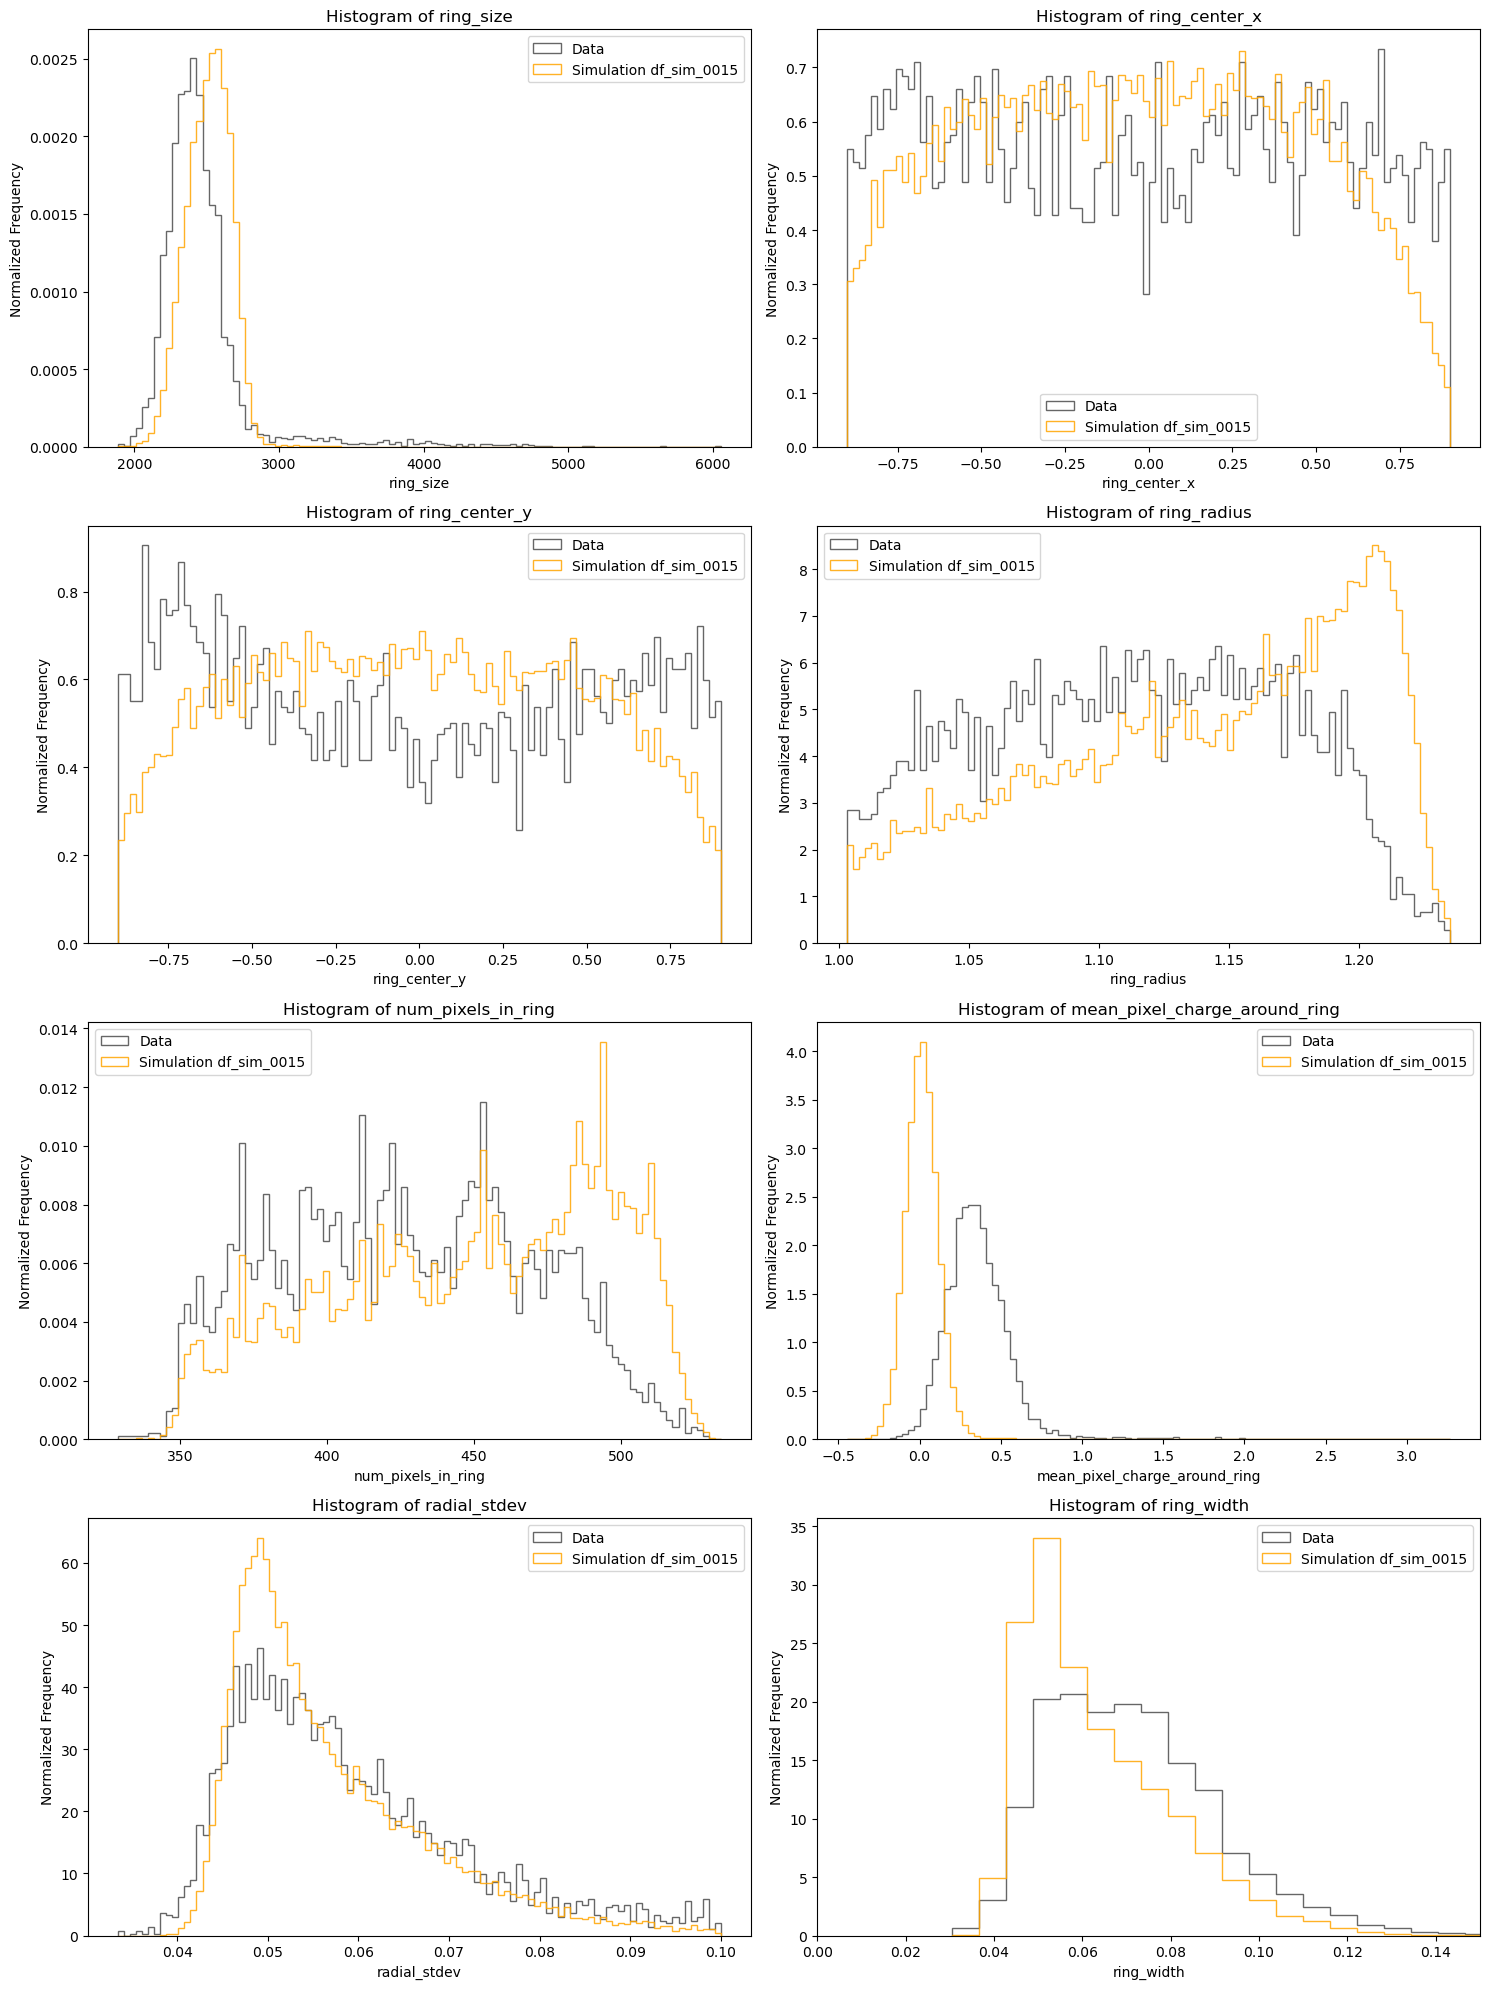

In [26]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('-----------> Data + Simulation for mirror alignment', name[-5:], 'deg <--------------\n')
        print(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, \ncompleteness>{ring_completeness_cut} \ncenter distance<{ring_center_distance_cut},\nimpact distance<{impact_distance_cut}, \nwidth quantile={QUANTILE_CUT}')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name)

# #4 Basic distributions (added cut on 20% percentile of ring width)

In [27]:
QUANTILE_CUT = 0.2

ring_completeness_cut = 0.8
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.2
ring_center_distance_cut = 0.65
impact_distance_cut = 5.5

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 2065 (0.18%)
Events survived for df_sim_00046: 3475 (0.25%)
Events survived for df_sim_00092: 7793 (0.58%)
Events survived for df_sim_0015: 18818 (1.75%)
Events survived for df_sim_002: 30460 (2.29%)
Events survived for winter_data_2024: 7656 (0.50%)


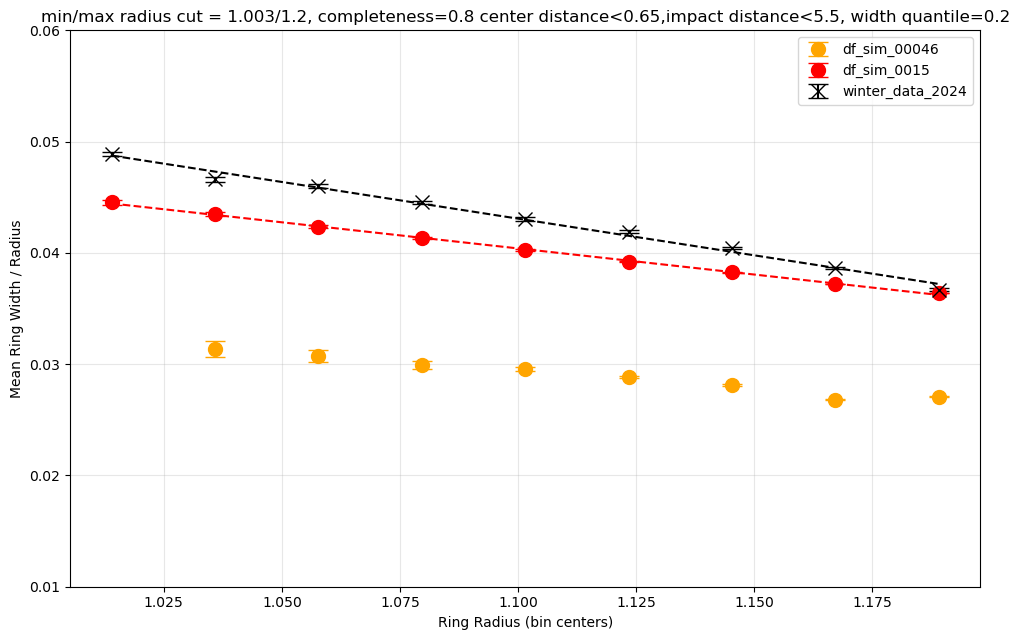

In [28]:

df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}
plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle='--')

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.06)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()  # Adjust layout for better spacing
plt.show()




----------------------------------> Data + Simulation for mirror alignment 00046 deg


min/max radius cut = 1.003/1.2, completeness=0.8 center distance<0.65,impact distance<5.5, width quantile=0.2


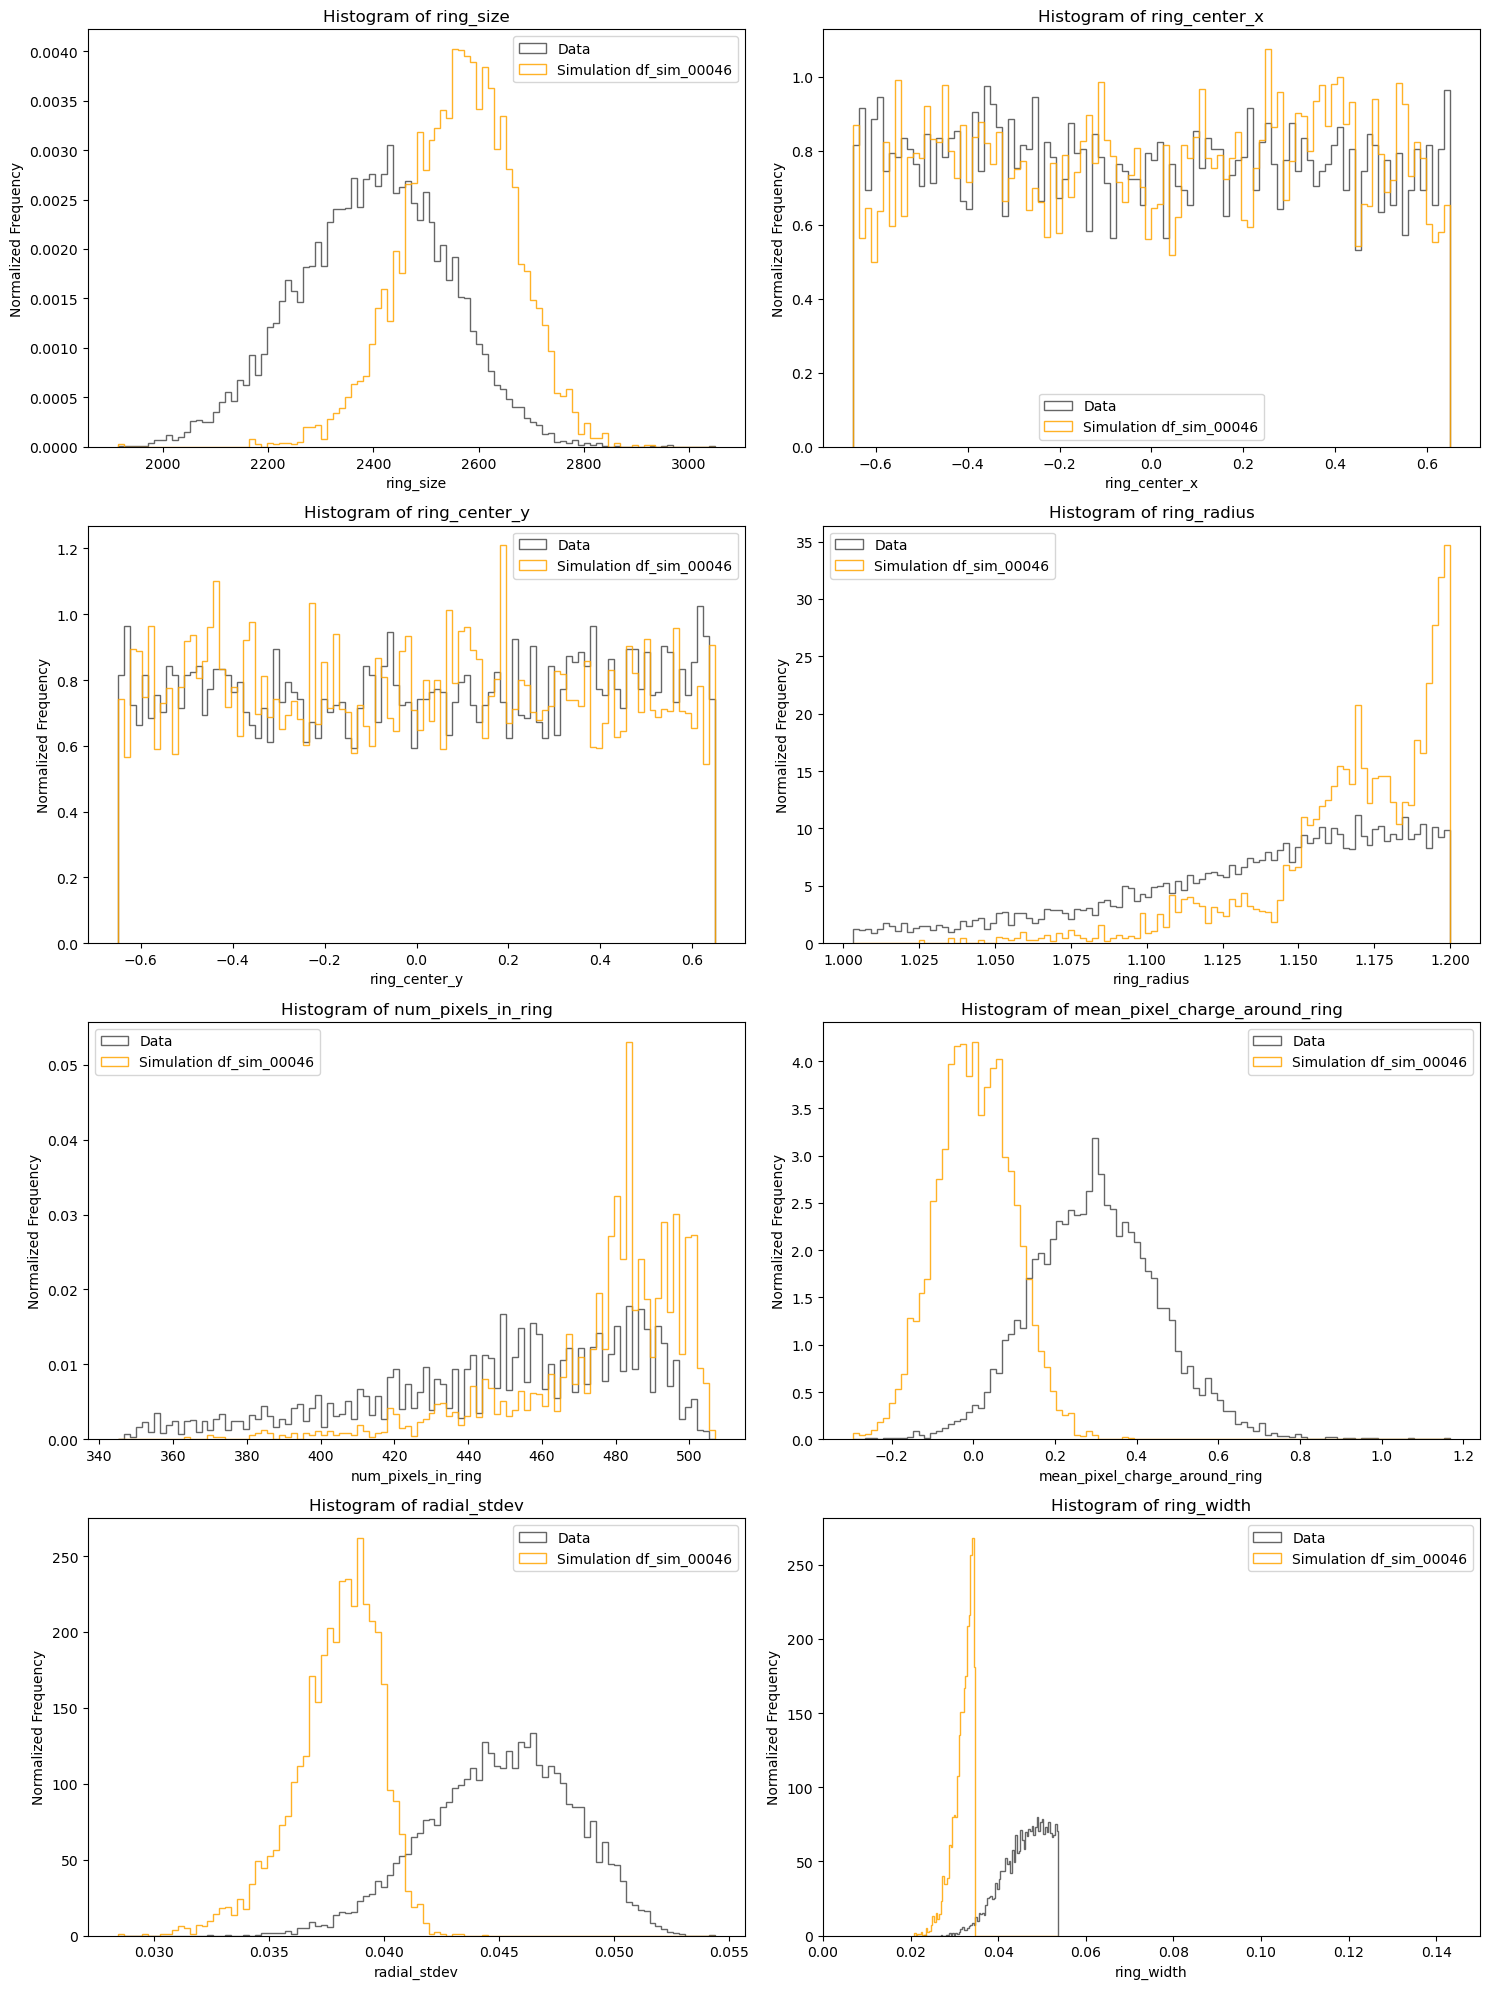



----------------------------------> Data + Simulation for mirror alignment _0015 deg


min/max radius cut = 1.003/1.2, completeness=0.8 center distance<0.65,impact distance<5.5, width quantile=0.2


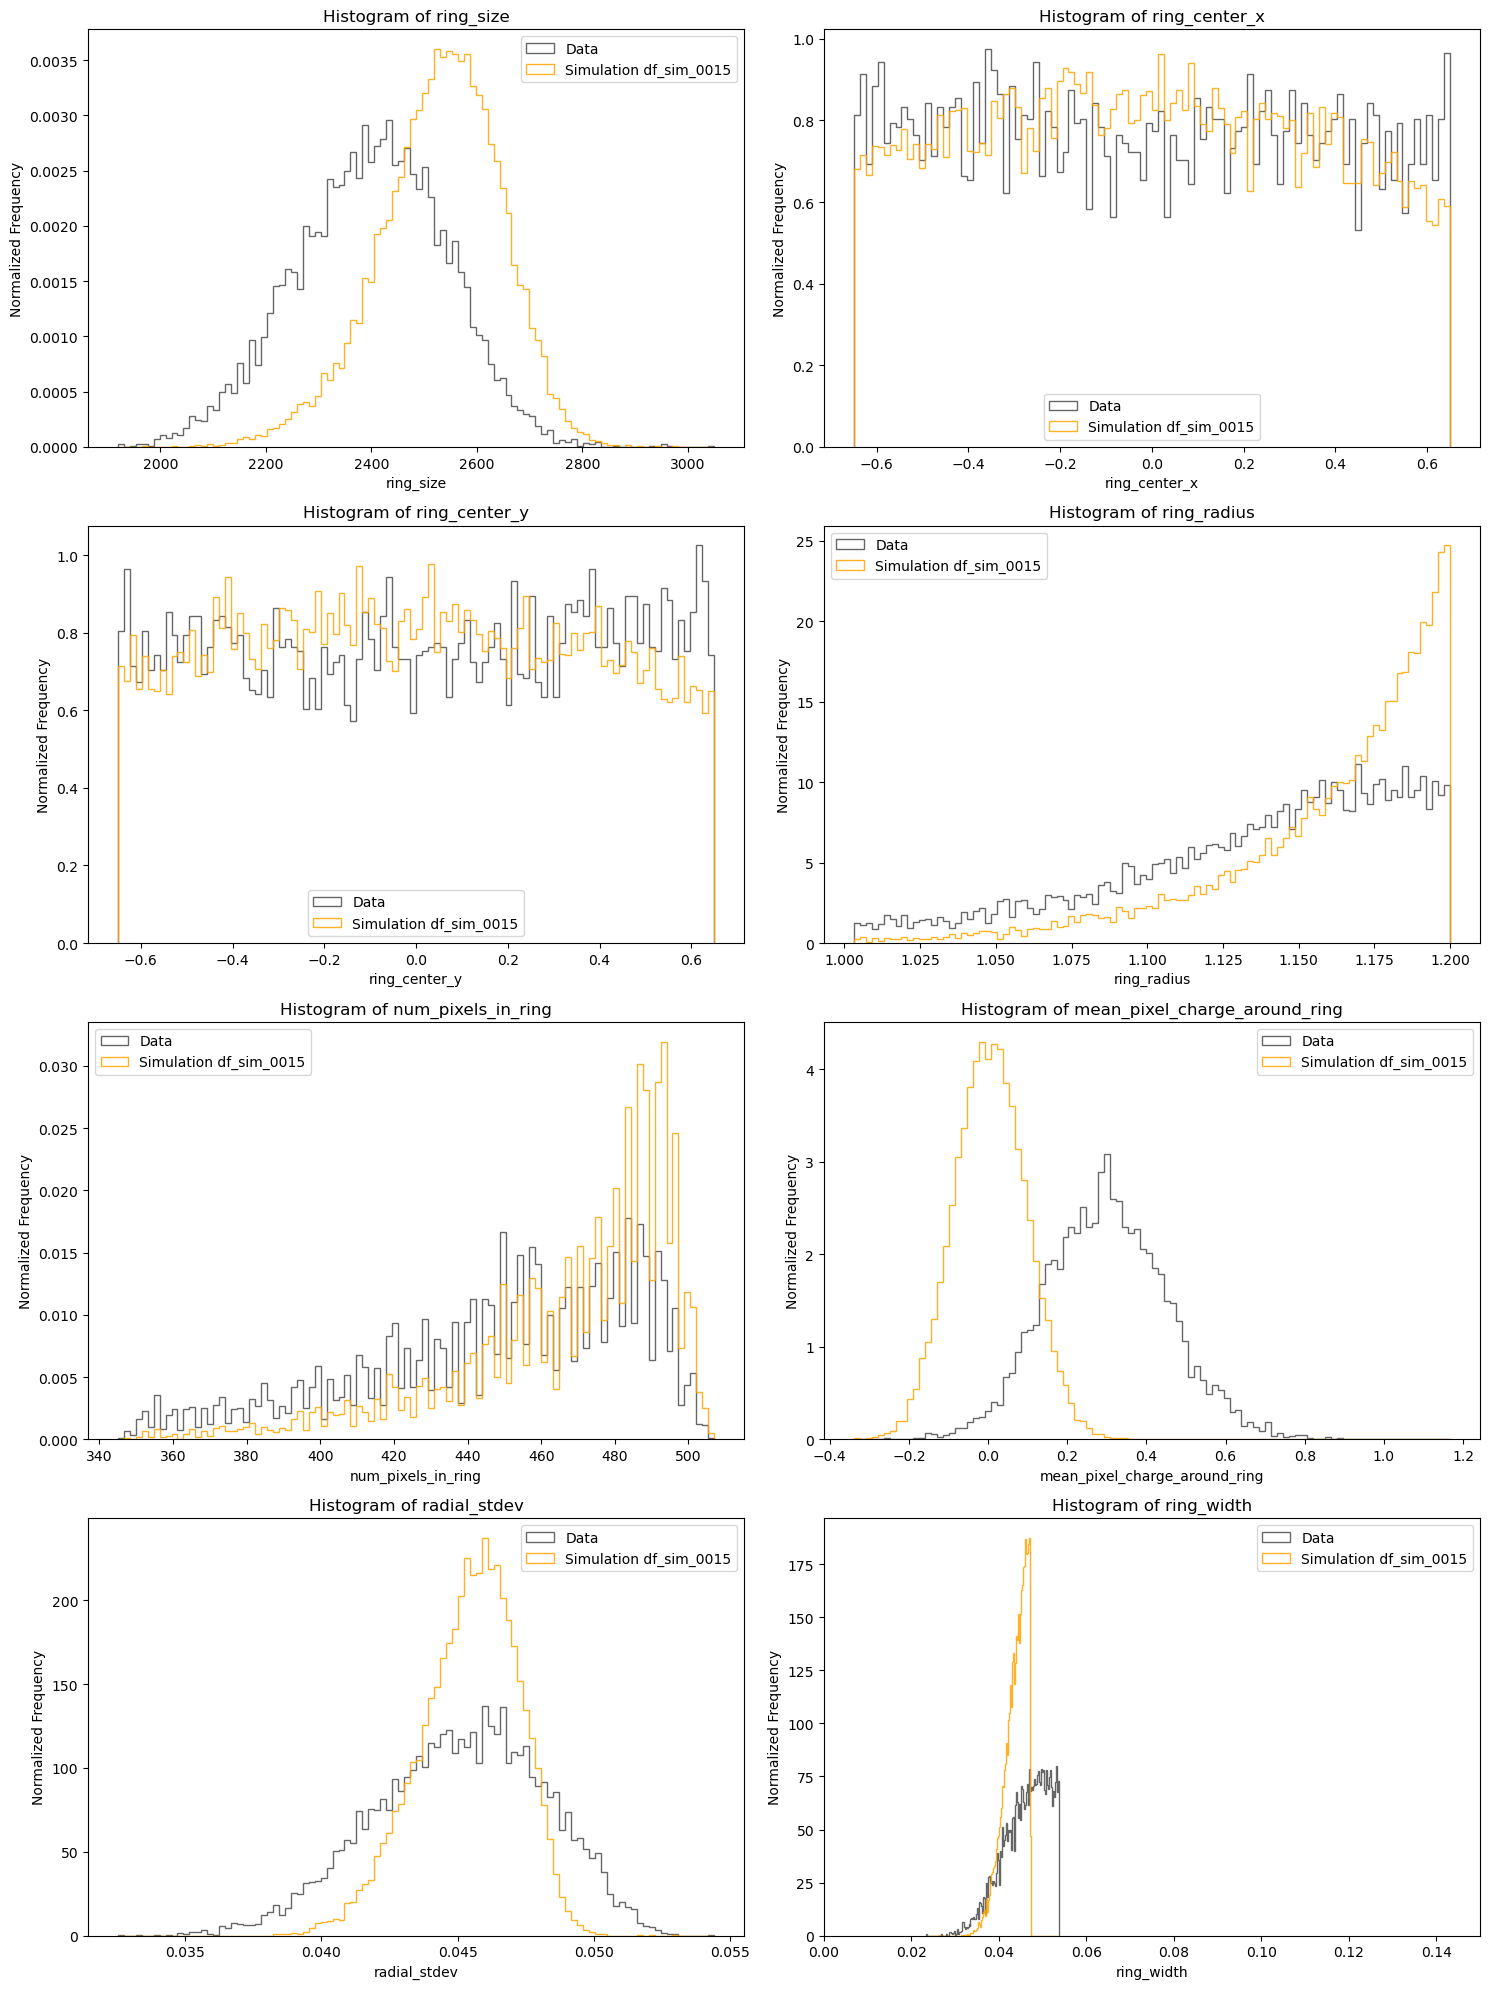

In [29]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('----------------------------------> Data + Simulation for mirror alignment', name[-5:], 'deg')
        print('\n')
        print(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name)

# #5 Basic distributions (ring radius is limited > 1.15)

Events survived for df_sim_00025: 689 (0.06%)
Events survived for df_sim_00046: 1300 (0.09%)
Events survived for df_sim_00092: 4072 (0.30%)
Events survived for df_sim_0015: 21109 (1.96%)
Events survived for df_sim_002: 48456 (3.64%)
Events survived for winter_data_2024: 1602 (0.11%)


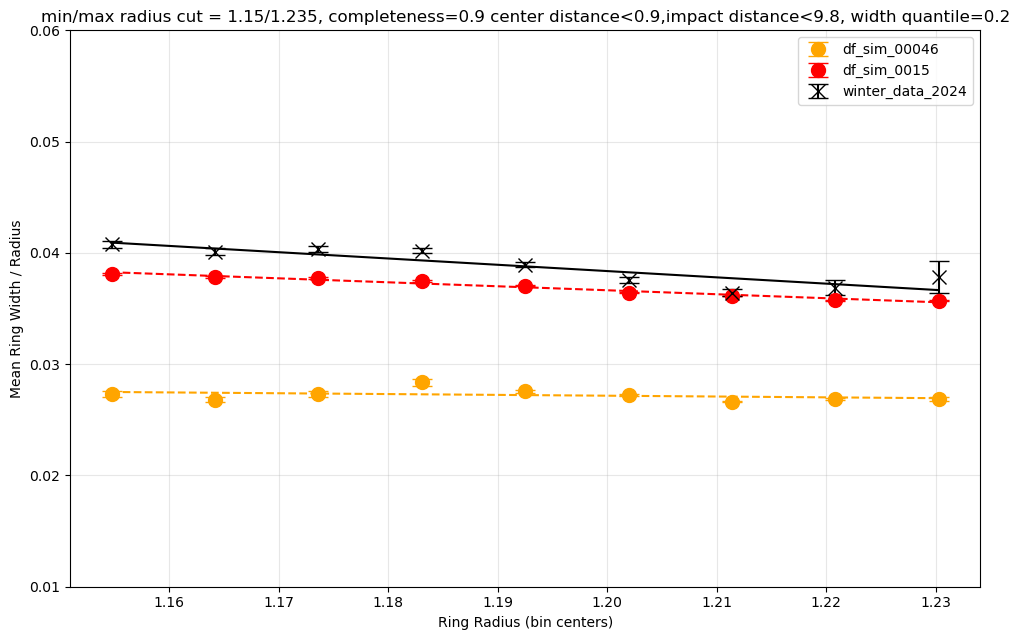

In [30]:
QUANTILE_CUT = 0.2

ring_completeness_cut = 0.9
ring_containment_cut = 0.99
min_radius_cut = 1.15
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")

df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'df_sim_no_int_corr' : True,
    'winter_data_2024': True
} 

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name])

plt.legend()

plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.06)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}')  
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




----------------------------------> Data + Simulation for mirror alignment 00046 deg


min/max radius cut = 1.15/1.235, completeness=0.9 center distance<0.9,impact distance<9.8, width quantile=0.2


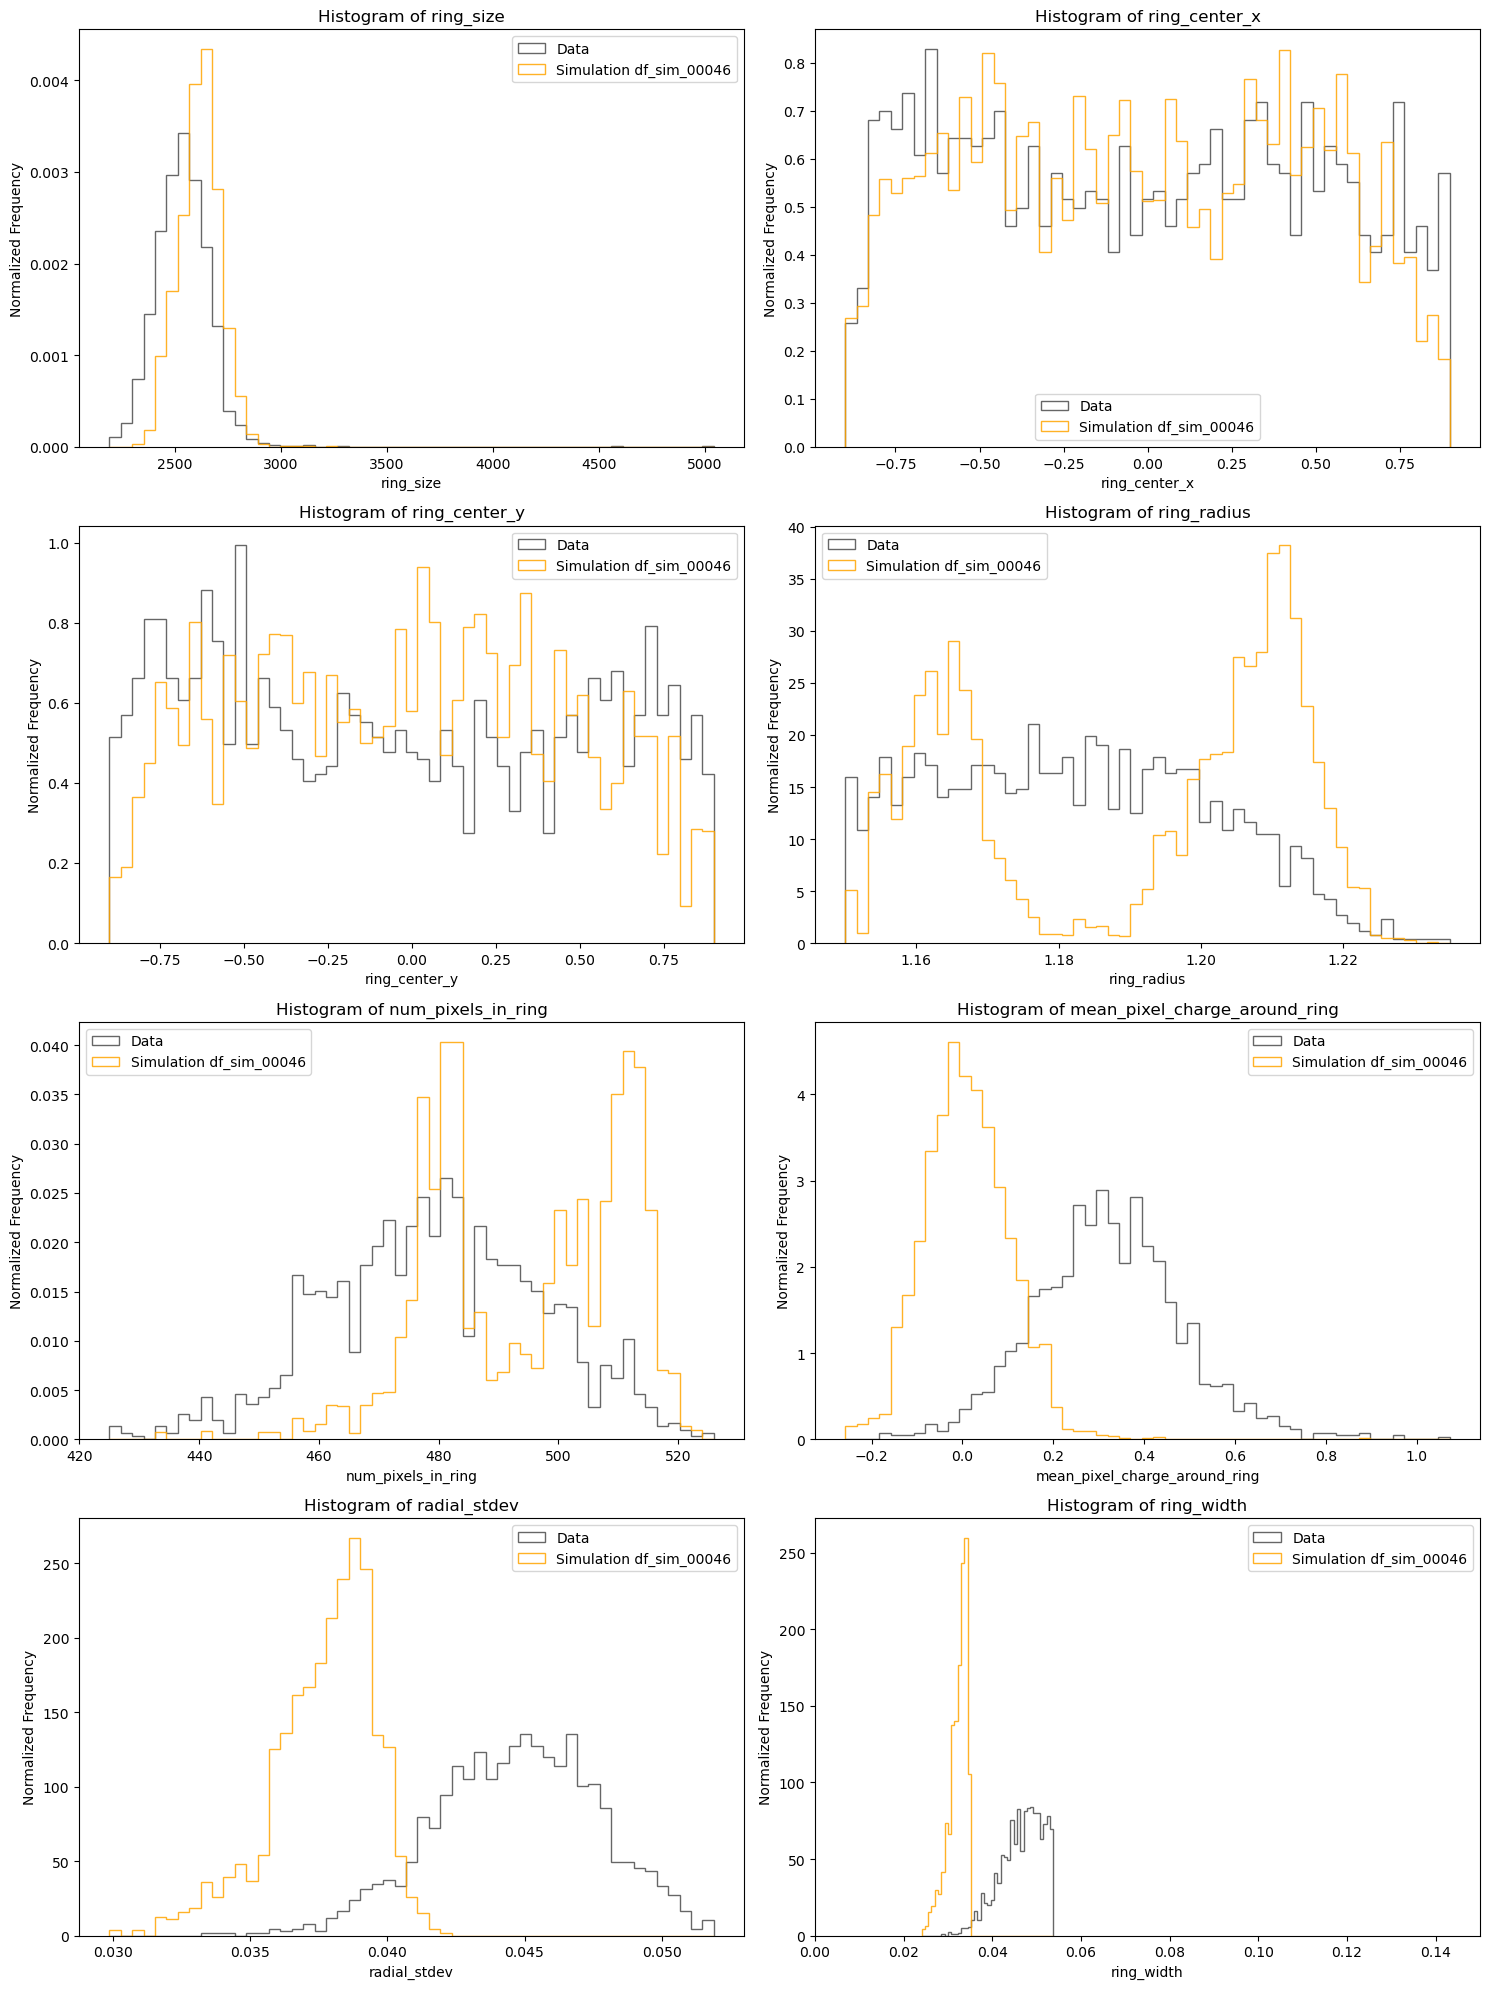



----------------------------------> Data + Simulation for mirror alignment _0015 deg


min/max radius cut = 1.15/1.235, completeness=0.9 center distance<0.9,impact distance<9.8, width quantile=0.2


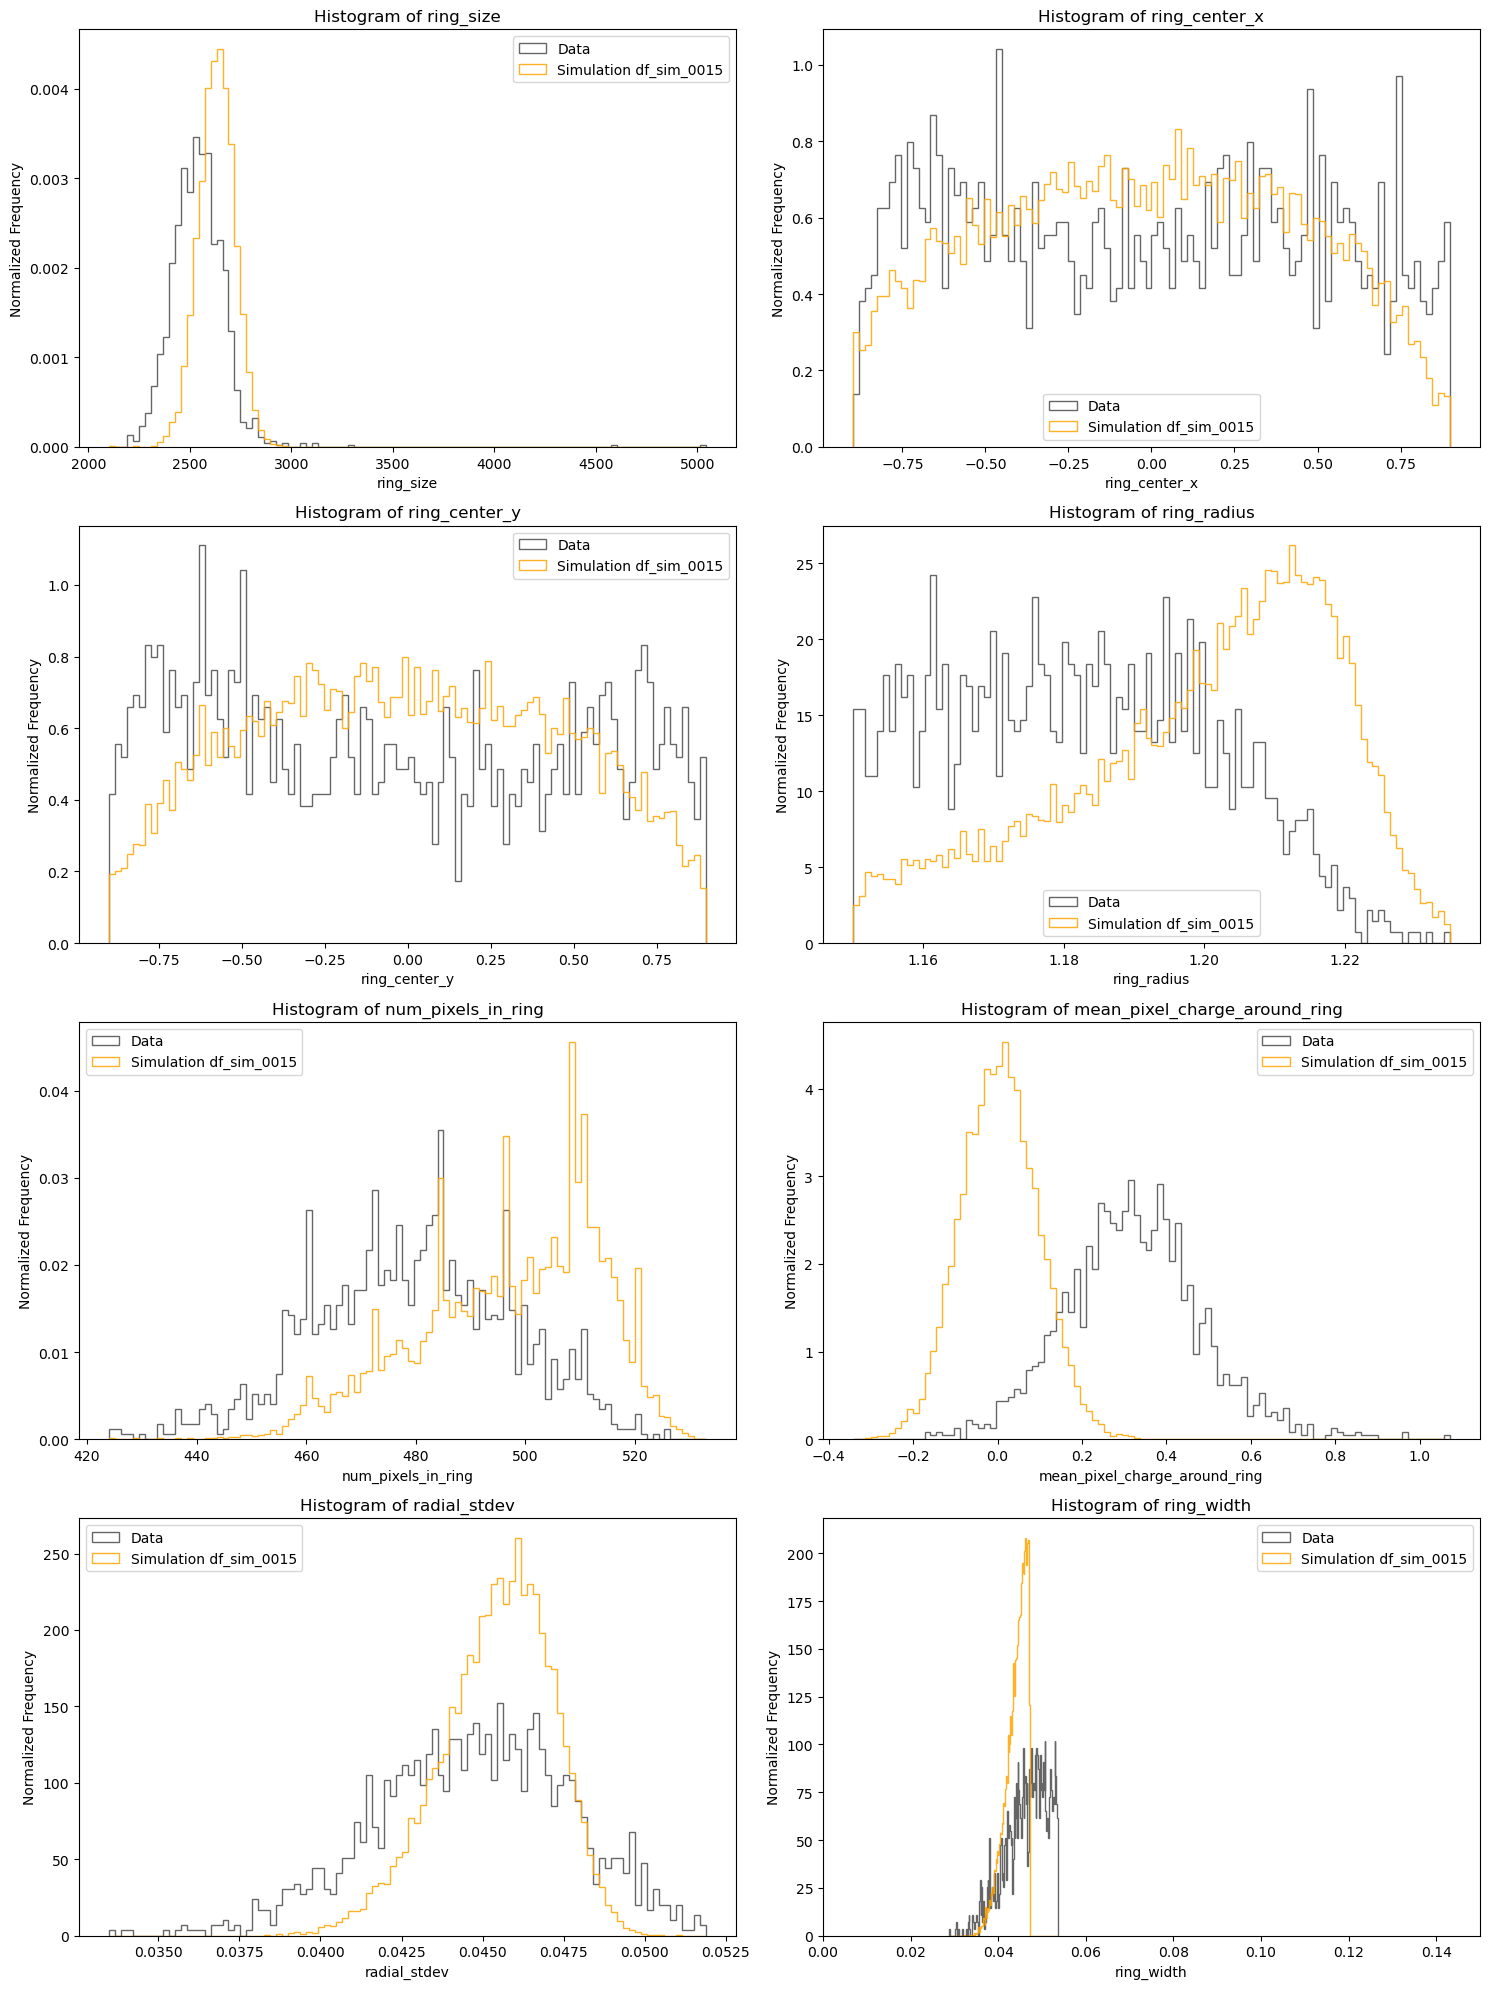

In [31]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('----------------------------------> Data + Simulation for mirror alignment', name[-5:], 'deg')
        print('\n')
        print(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name)

# No reweighting

# #1 Basic distributions, cuts only on ring center and impact point 

In [32]:
QUANTILE_CUT = 1

ring_completeness_cut = 0
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 881123 (77.98%)
Events survived for df_sim_00046: 1105419 (78.12%)
Events survived for df_sim_00092: 1042370 (78.03%)
Events survived for df_sim_0015: 841515 (78.26%)
Events survived for df_sim_002: 1040426 (78.19%)
Events survived for winter_data_2024: 334868 (21.99%)


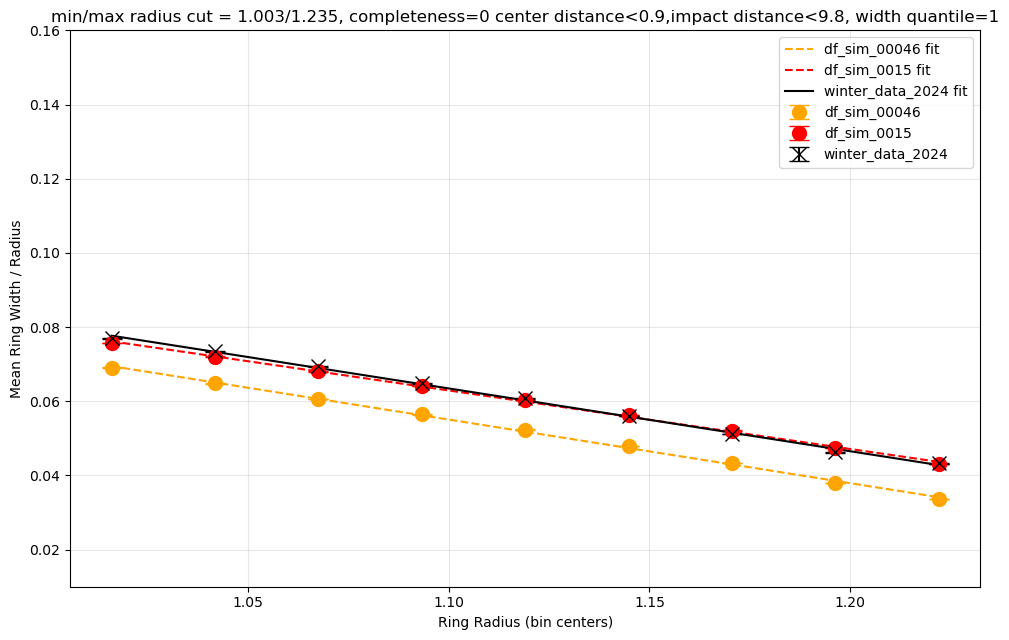

In [33]:
df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name], label=f'{name} fit')

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.16)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()  # Adjust layout for better spacing
plt.show()




----------------------------------> Data + Simulation for mirror alignment 00046 deg




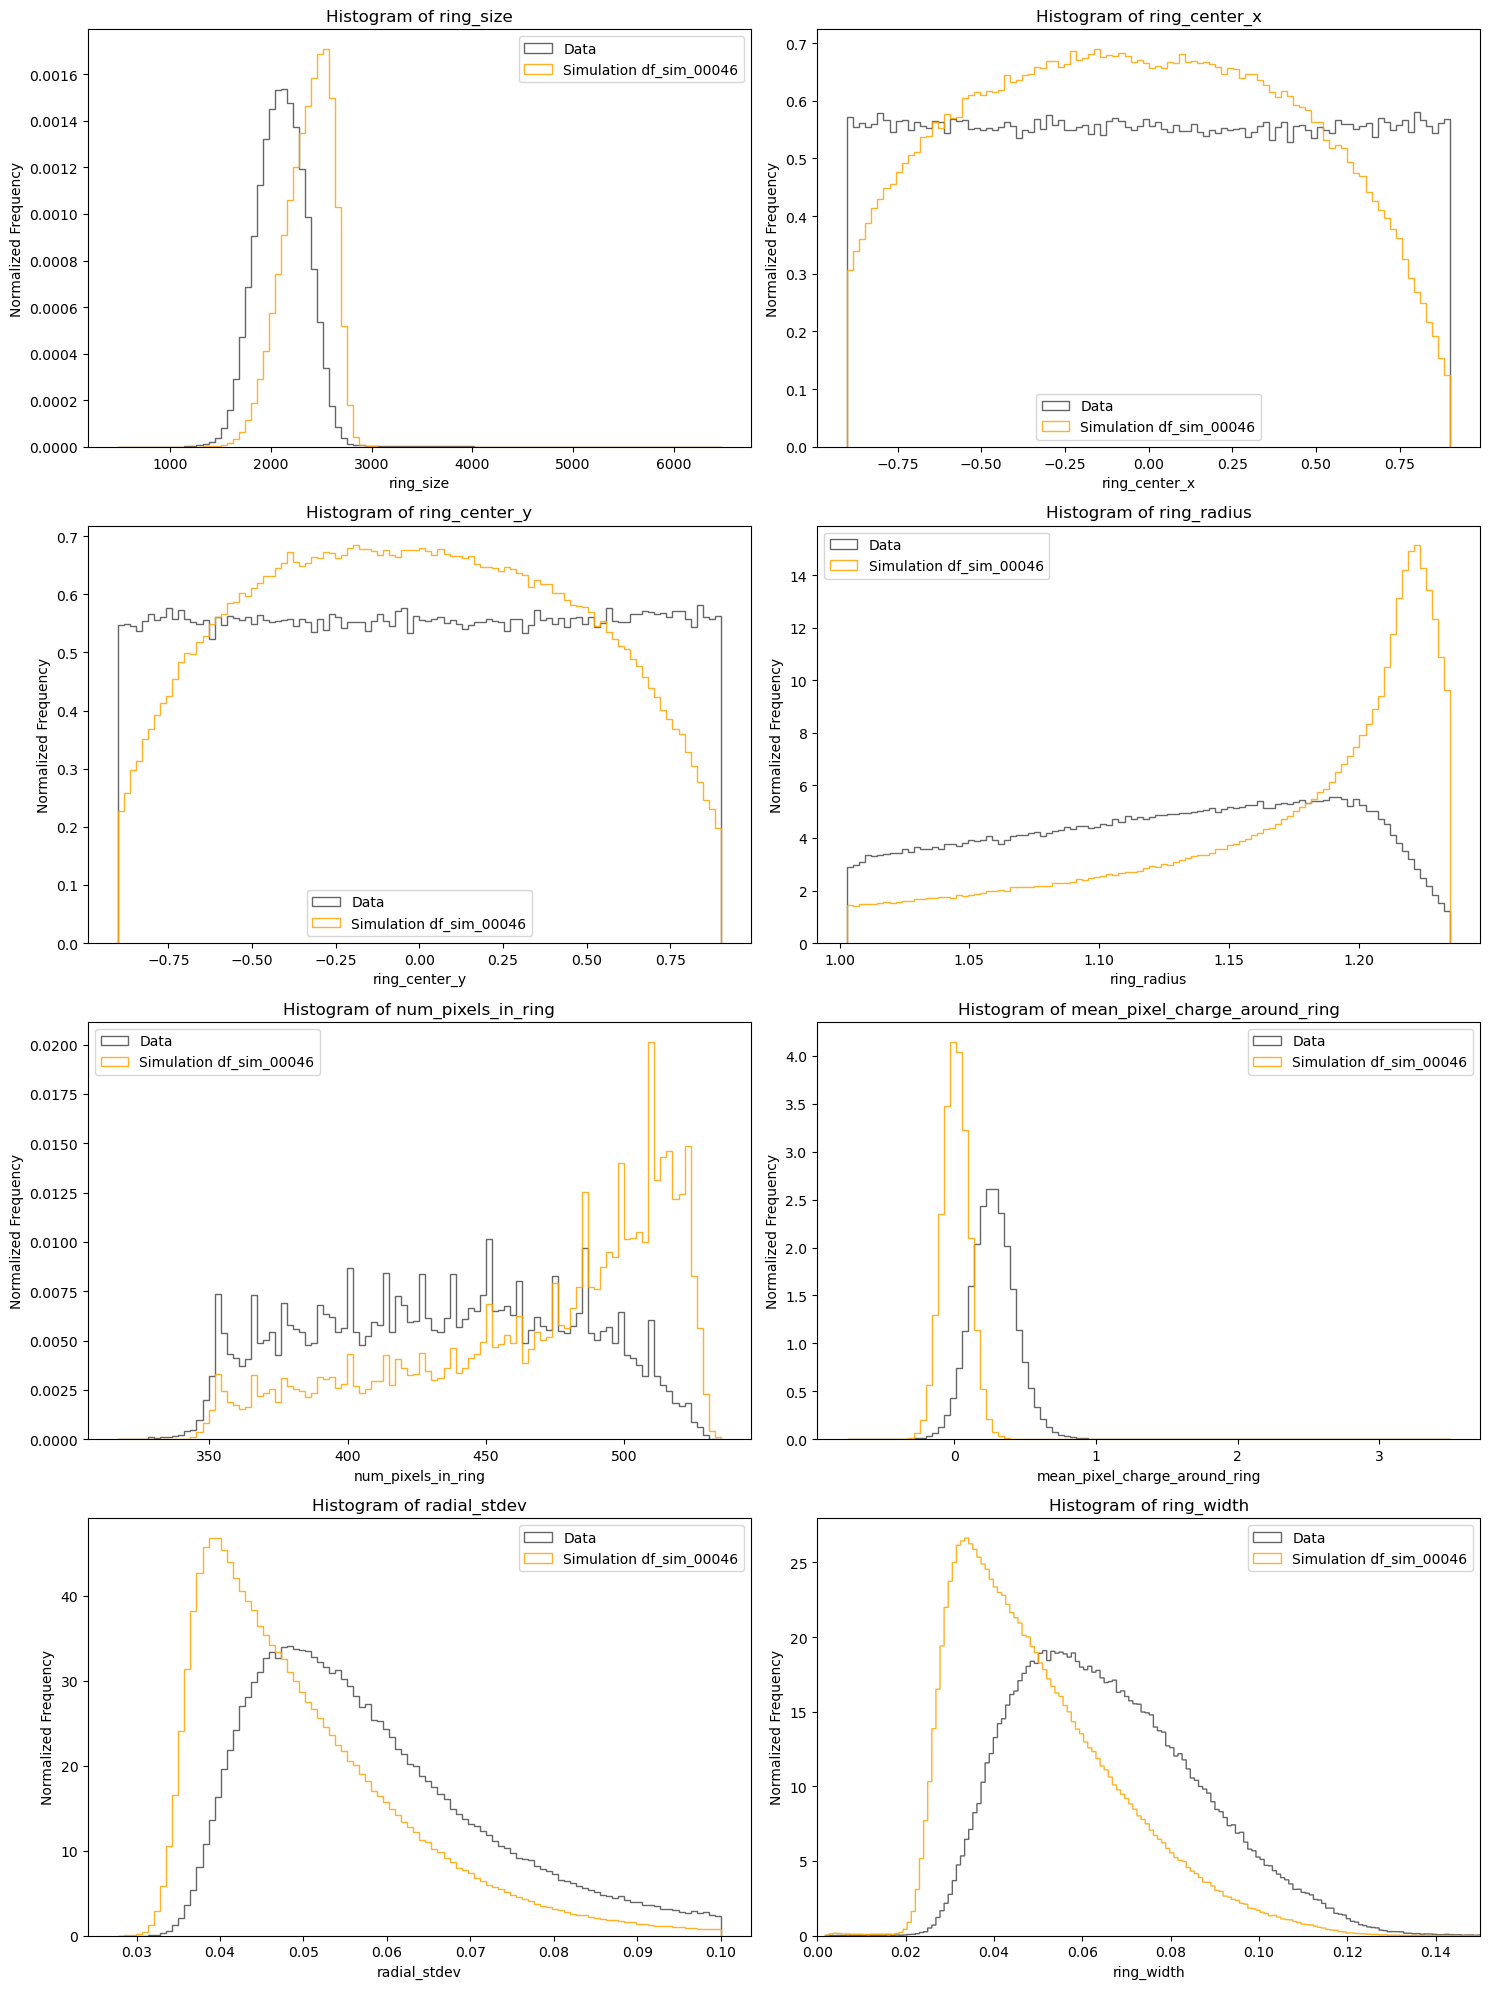



----------------------------------> Data + Simulation for mirror alignment _0015 deg




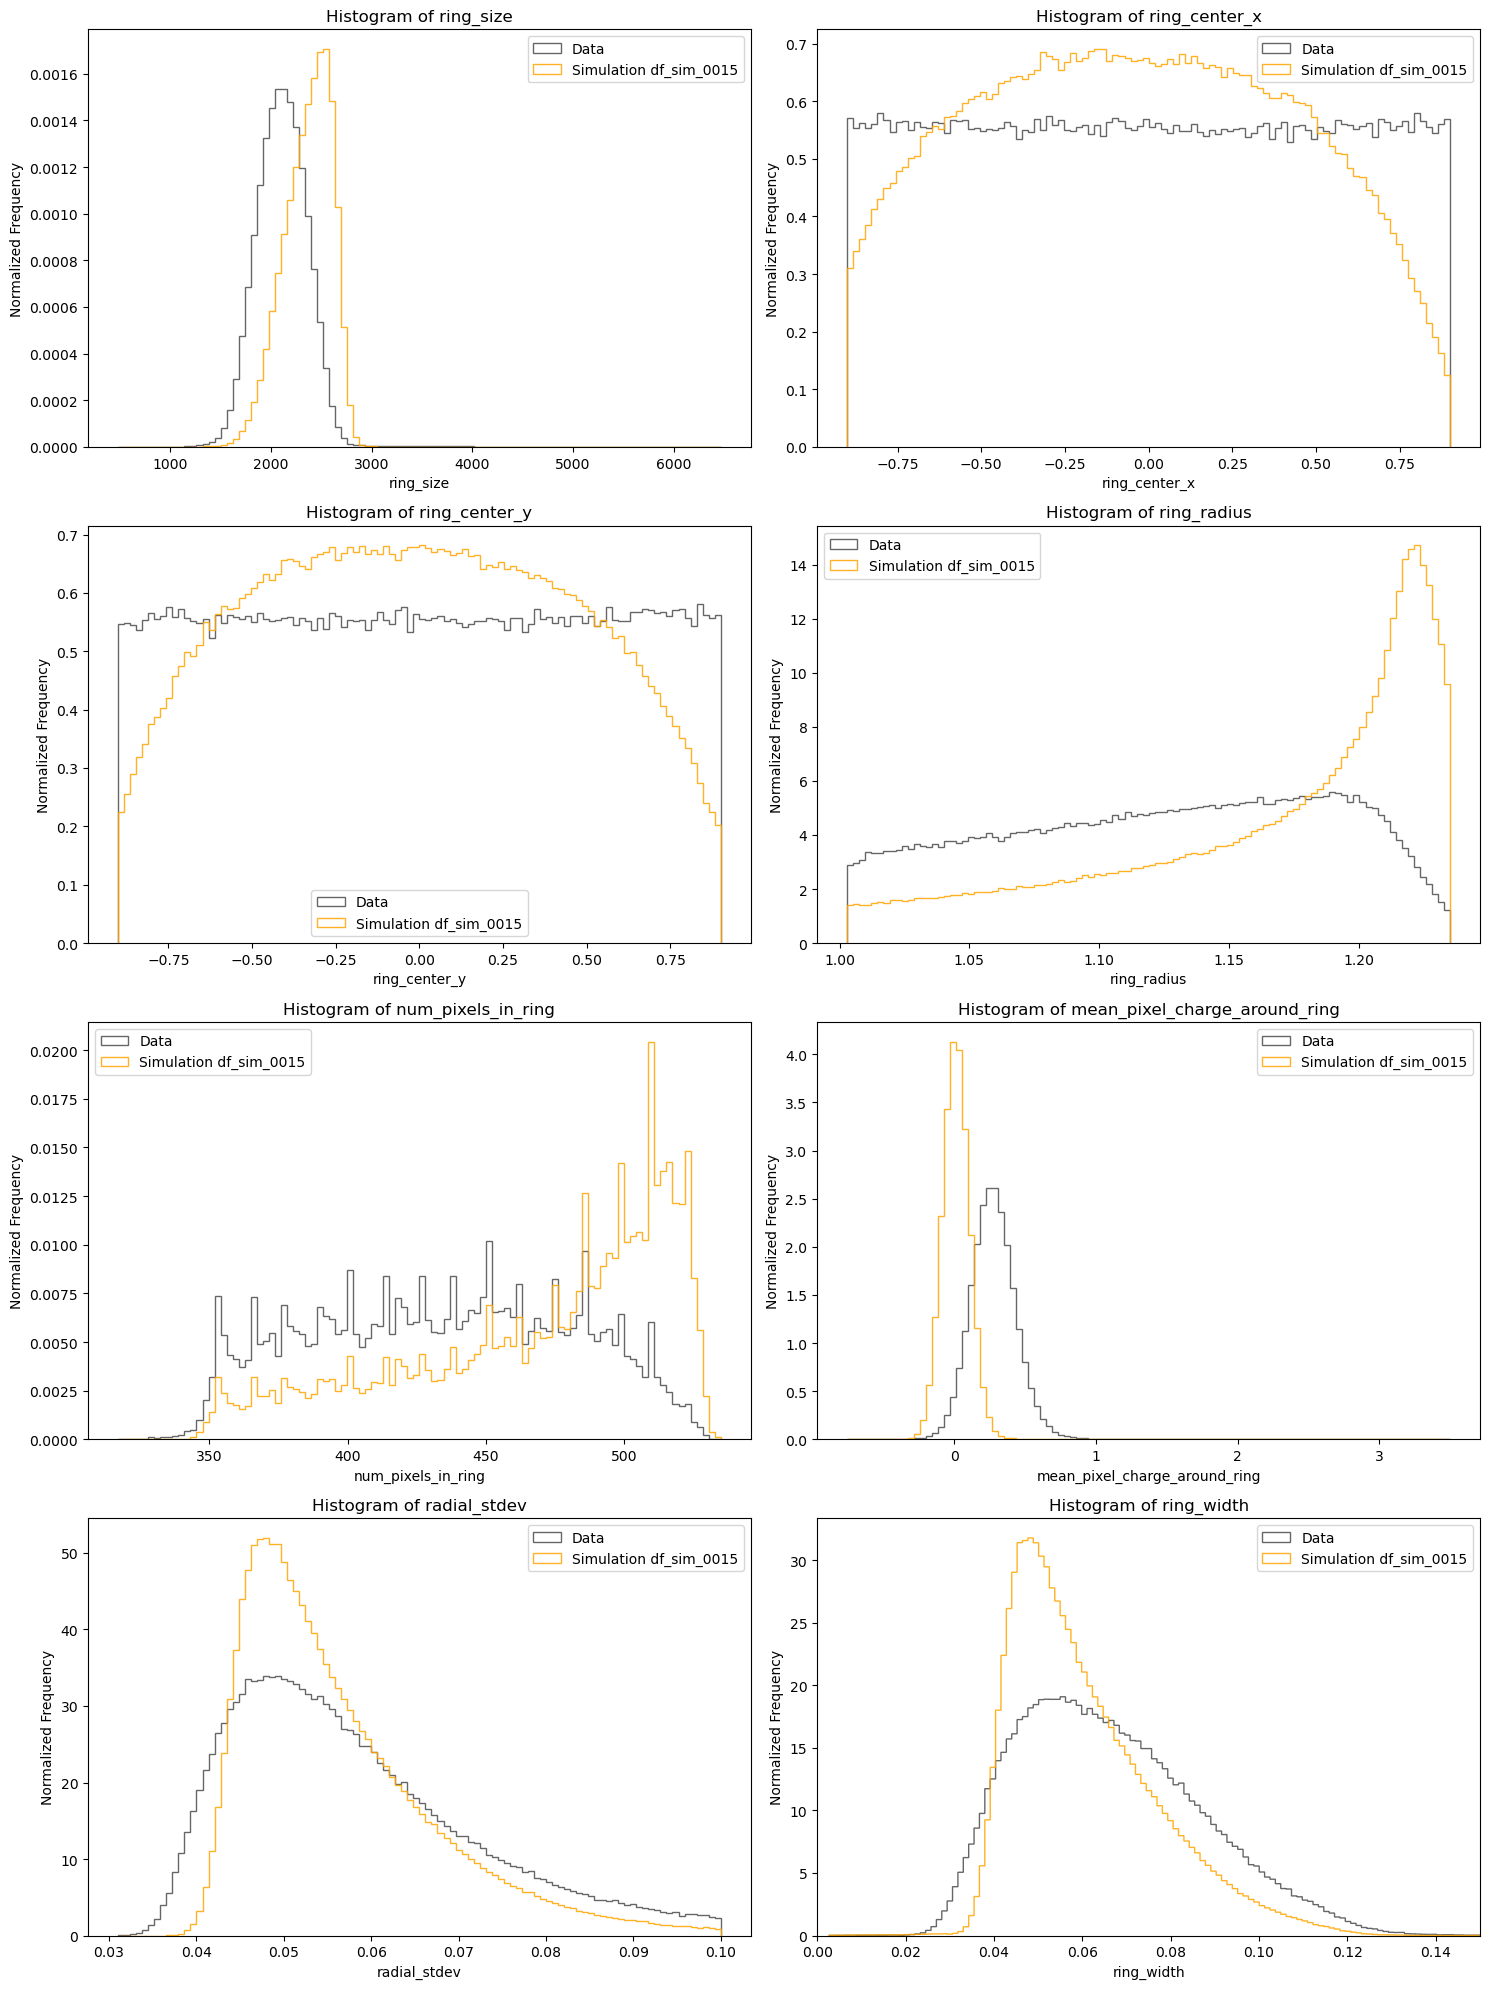

In [34]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('----------------------------------> Data + Simulation for mirror alignment', name[-5:], 'deg')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, df_name = name, apply_weight=False)

# #2 Basic distributions cuts (added cut on ring completeness > 0.9)

In [35]:
QUANTILE_CUT = 1

ring_completeness_cut = 0.9
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 31284 (2.77%)
Events survived for df_sim_00046: 42578 (3.01%)
Events survived for df_sim_00092: 50123 (3.75%)
Events survived for df_sim_0015: 81135 (7.55%)
Events survived for df_sim_002: 135897 (10.21%)
Events survived for winter_data_2024: 11366 (0.75%)


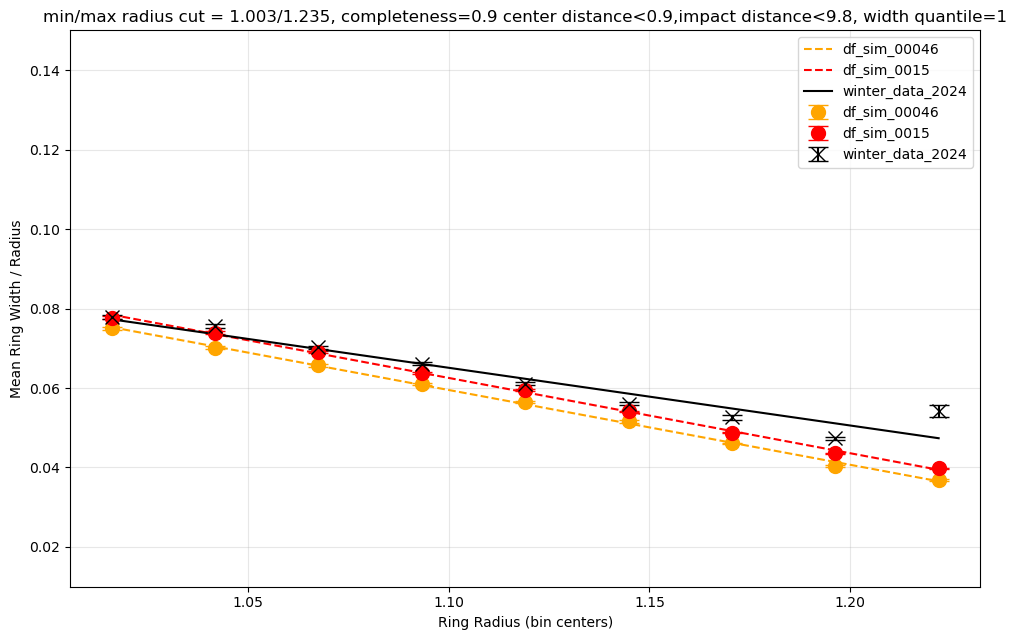

In [36]:
df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name], label=name)

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.15)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



----------------------------------> Data + Simulation for mirror alignment 00046 deg




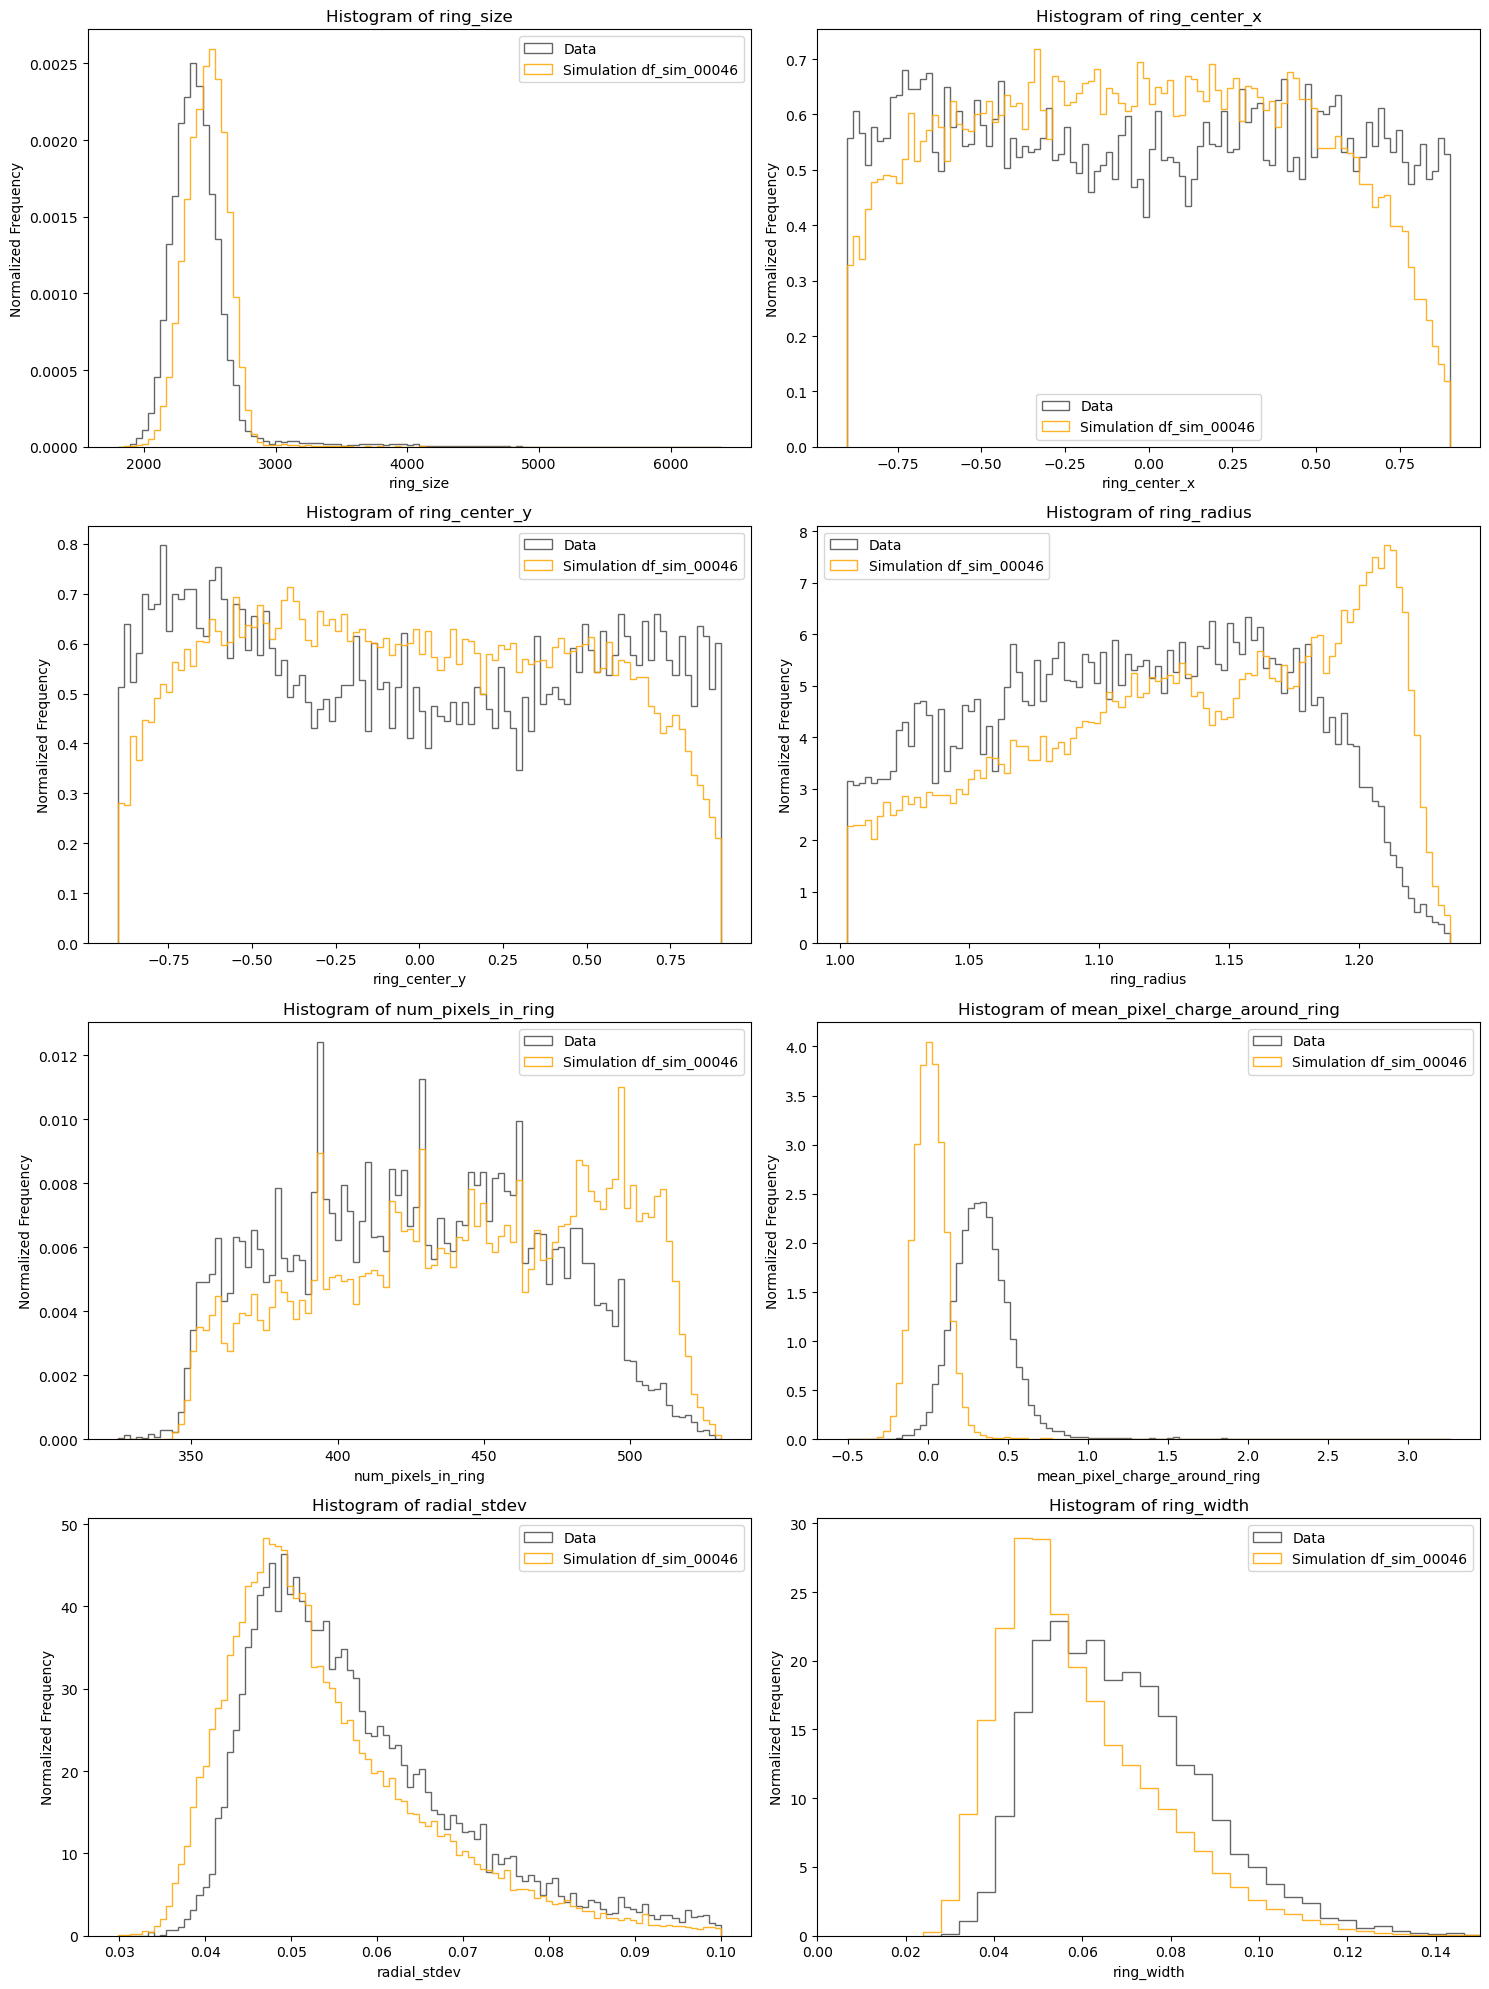



----------------------------------> Data + Simulation for mirror alignment _0015 deg




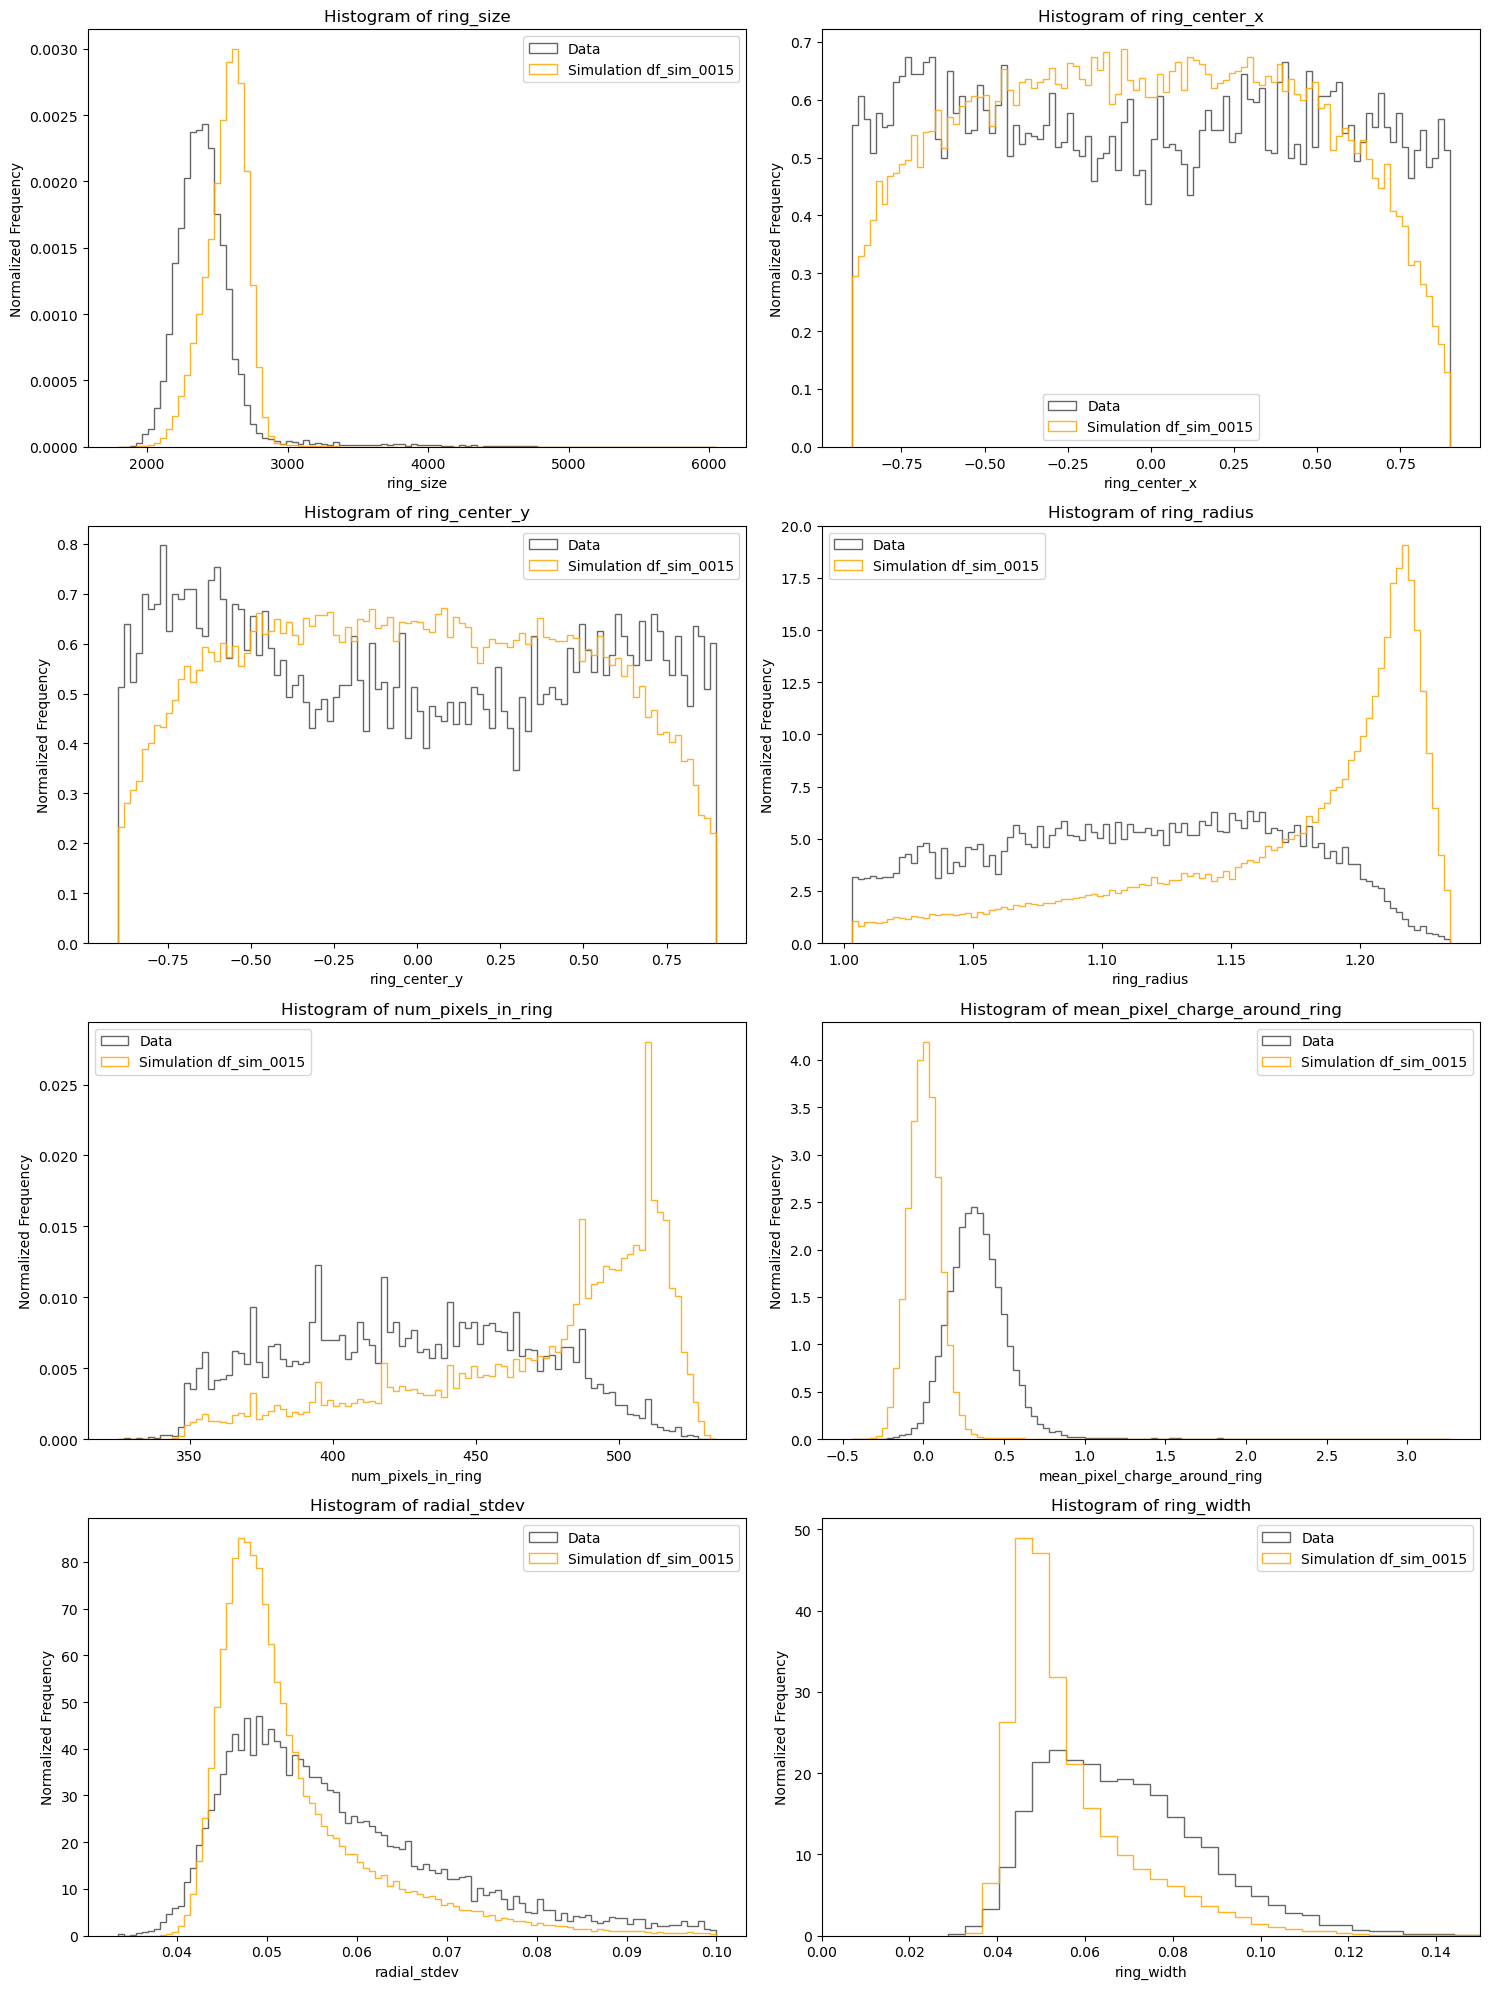

In [37]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('----------------------------------> Data + Simulation for mirror alignment', name[-5:], 'deg')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, apply_weight=False, df_name = name)

# #3 Basic distributions (added cut on 20% percentile of ring width)

In [38]:
QUANTILE_CUT = 0.2

ring_completeness_cut = 0.9
ring_containment_cut = 0
min_radius_cut = 1.003
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")


Events survived for df_sim_00025: 694 (0.06%)
Events survived for df_sim_00046: 1322 (0.09%)
Events survived for df_sim_00092: 4156 (0.31%)
Events survived for df_sim_0015: 21959 (2.04%)
Events survived for df_sim_002: 51106 (3.84%)
Events survived for winter_data_2024: 2665 (0.18%)


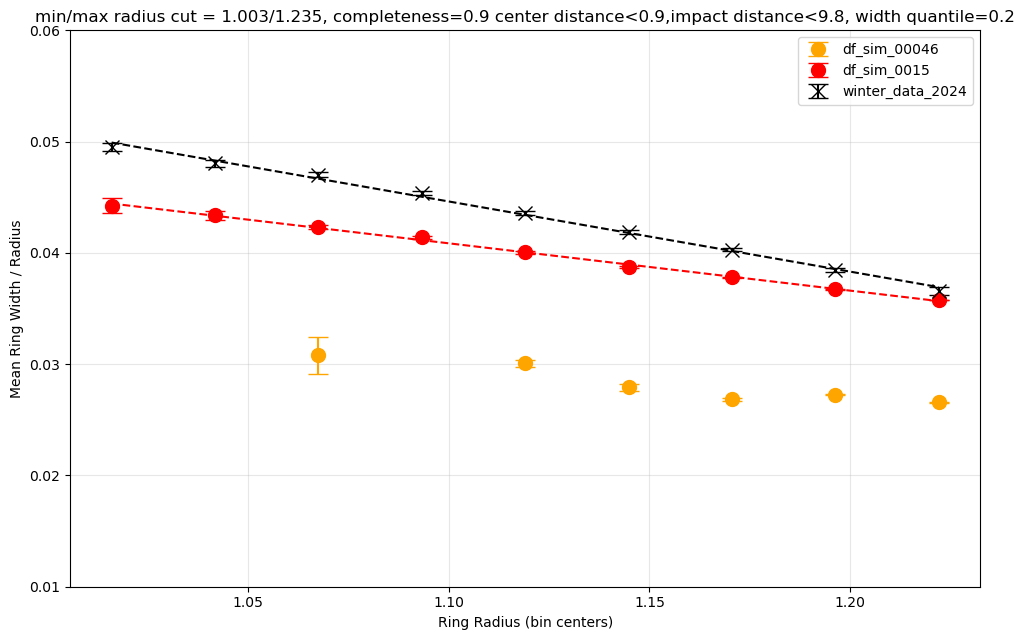

In [39]:

df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
}
plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle='--')

plt.legend()

# Customize the plot
plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.06)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}') 
plt.grid(alpha=0.3)
plt.tight_layout()  # Adjust layout for better spacing
plt.show()




----------------------------------> Data + Simulation for mirror alignment 00046 deg




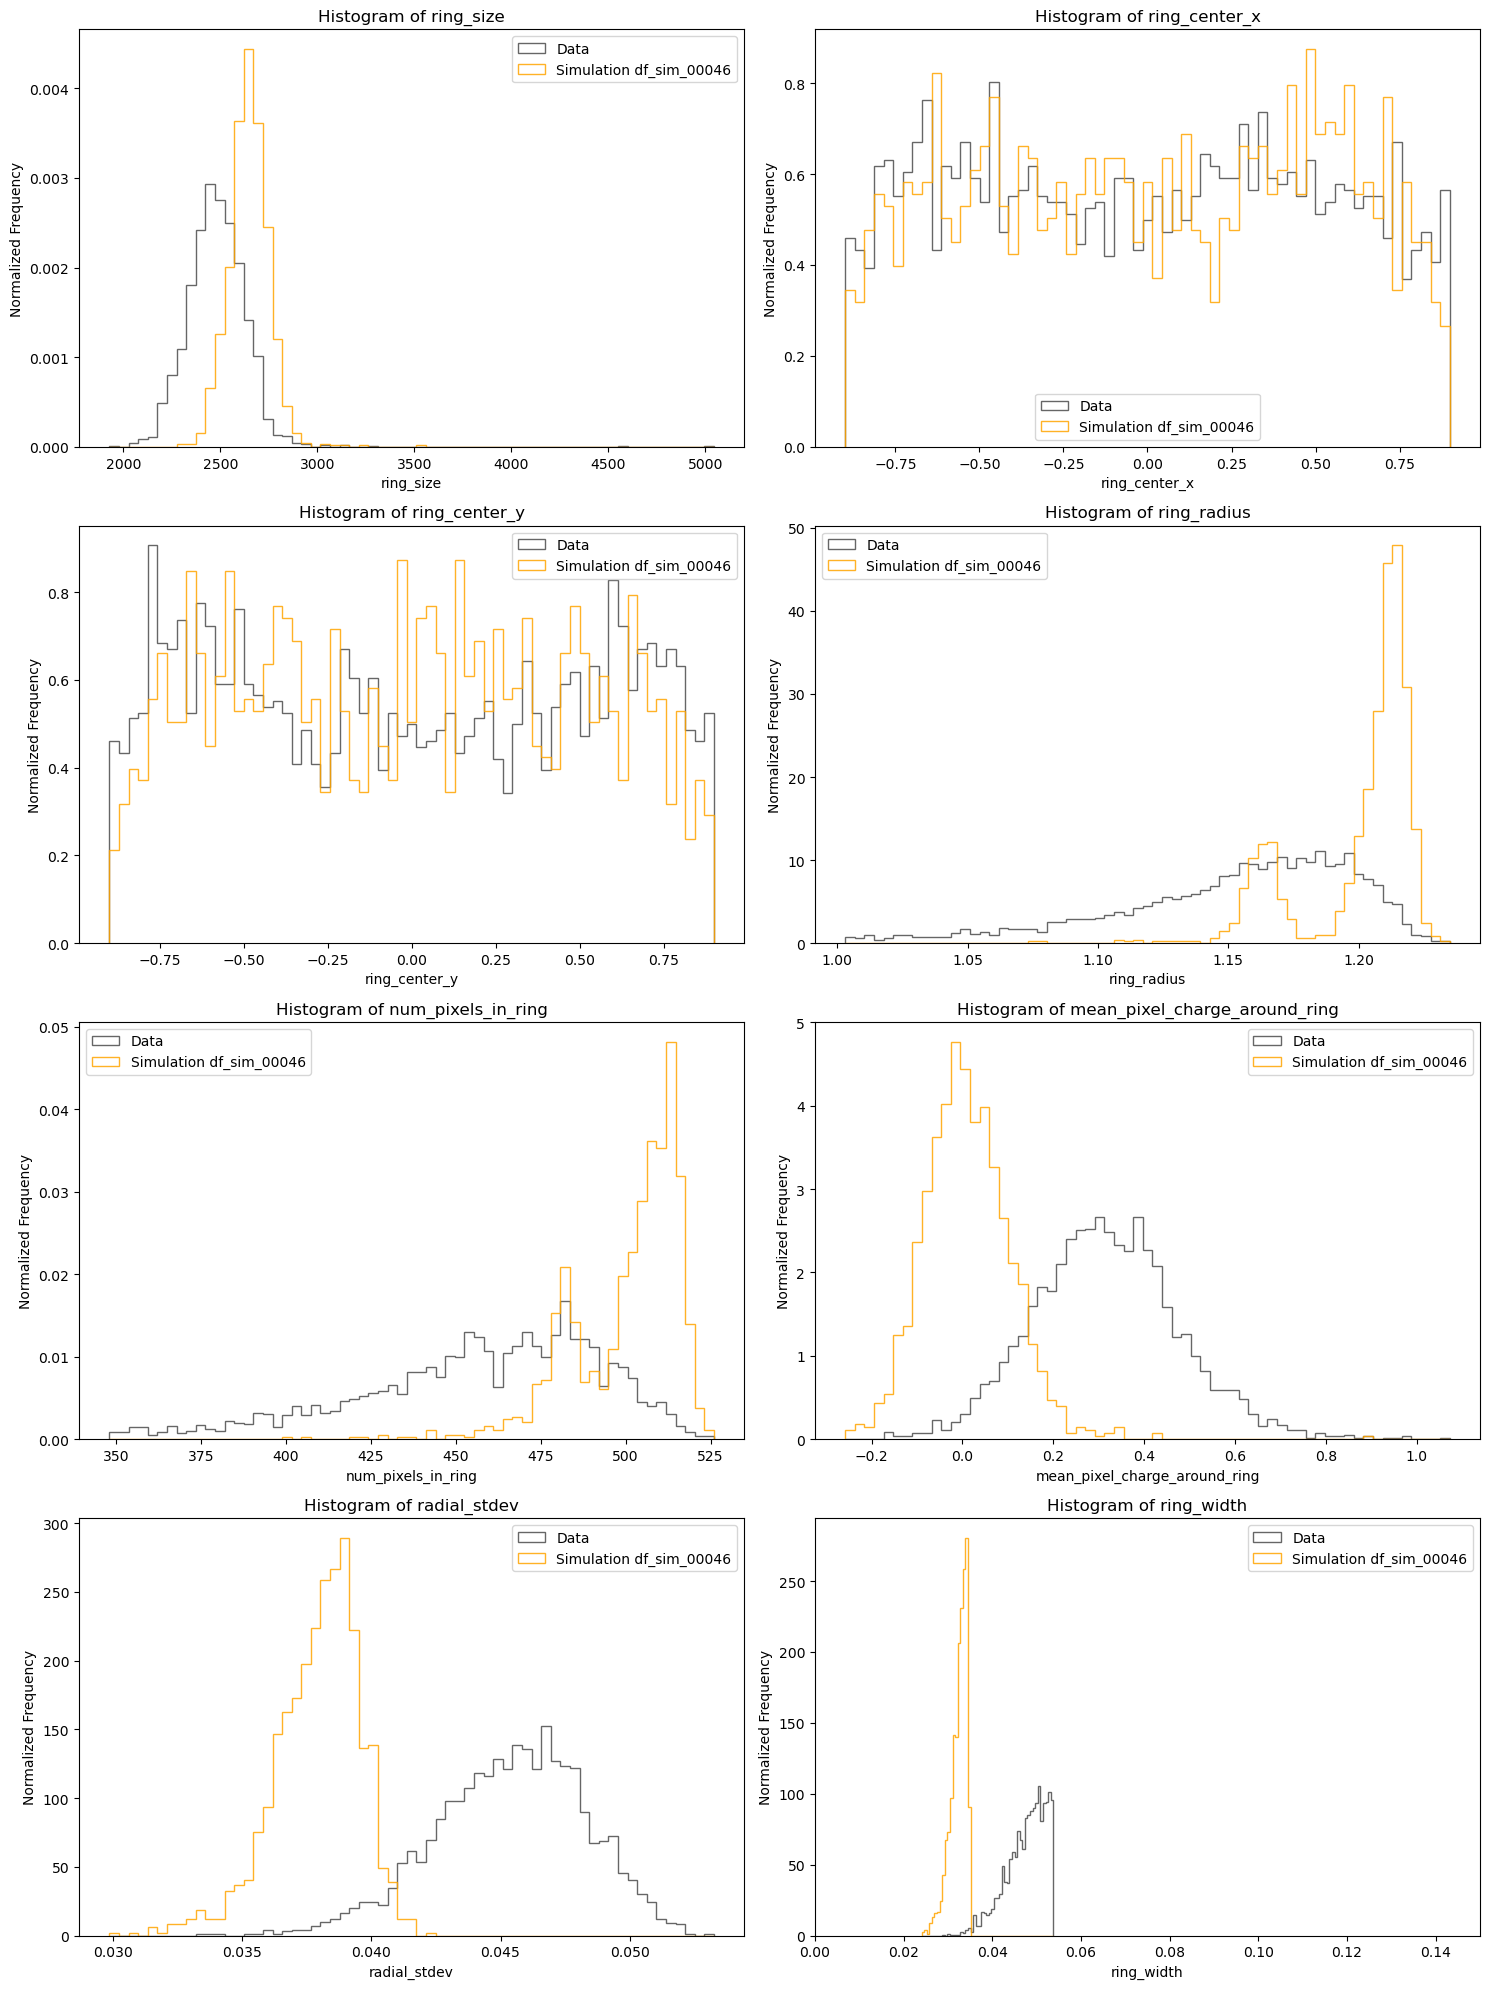



----------------------------------> Data + Simulation for mirror alignment _0015 deg




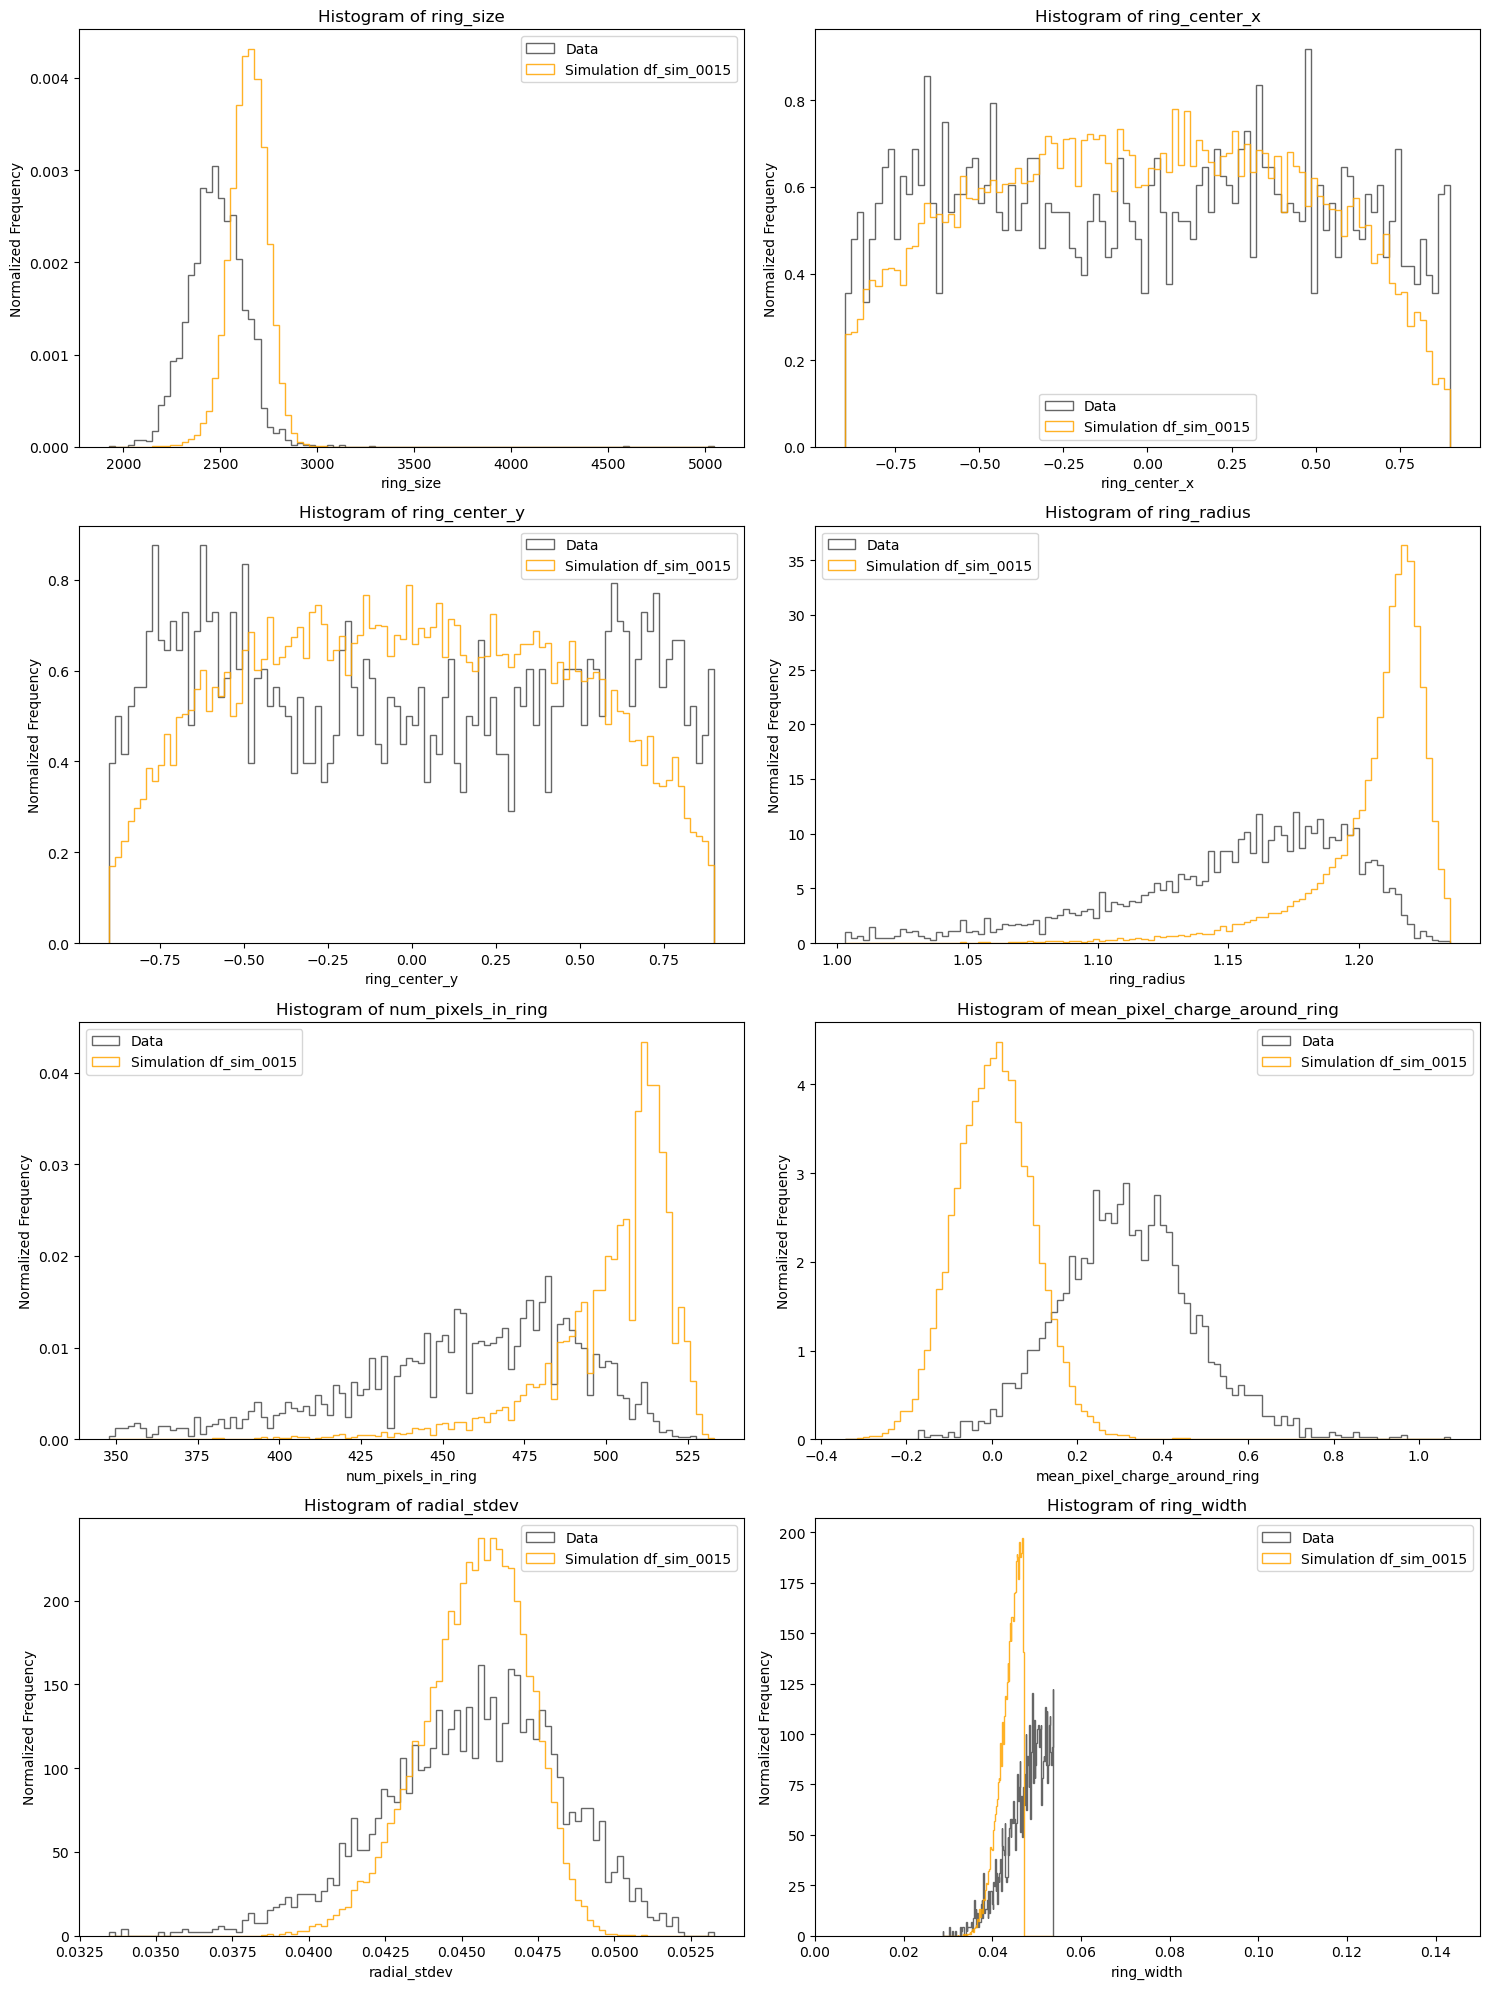

In [40]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('----------------------------------> Data + Simulation for mirror alignment', name[-5:], 'deg')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, apply_weight=False, df_name = name)

# #4 Basic distributions (ring radius is limited > 1.15)

Events survived for df_sim_00025: 689 (0.06%)
Events survived for df_sim_00046: 1300 (0.09%)
Events survived for df_sim_00092: 4072 (0.30%)
Events survived for df_sim_0015: 21111 (1.96%)
Events survived for df_sim_002: 48462 (3.64%)
Events survived for winter_data_2024: 1613 (0.11%)


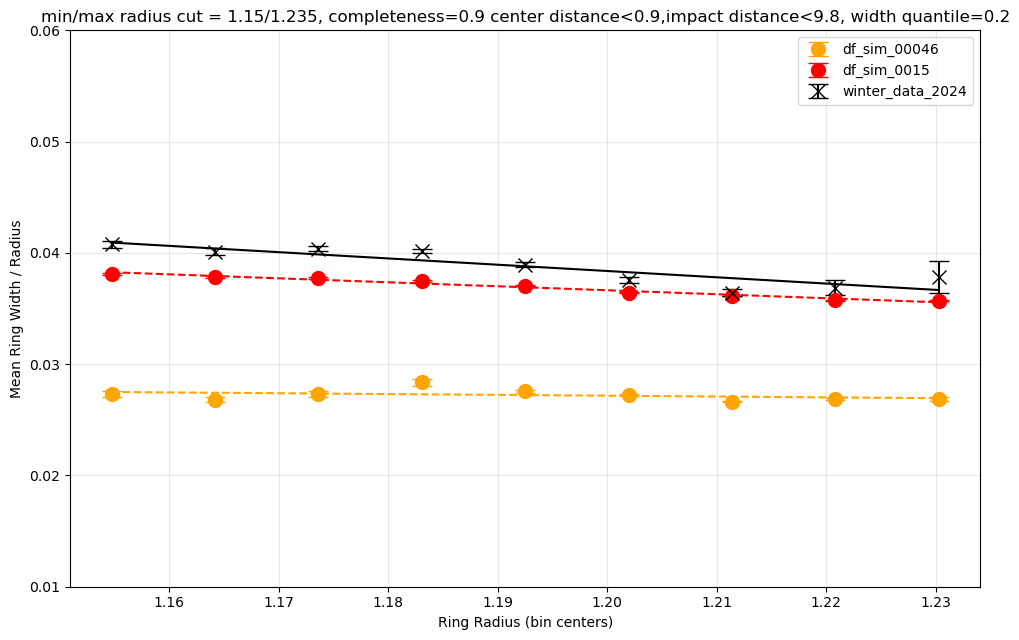

In [41]:
QUANTILE_CUT = 0.2

ring_completeness_cut = 0.9
ring_containment_cut = 0
min_radius_cut = 1.15
max_radius_cut = 1.235
ring_center_distance_cut = 0.9
impact_distance_cut = 9.8

df_list = [df_sim_00025_align, df_sim_00046_align, df_sim_00092_align, df_sim_0015_align, df_sim_002_align, df_winter_data]
cut_datasets = {}
data_width_binned_dict = {}

bin_edges = max_radius_cut - min_radius_cut
bin_bins = np.linspace(min_radius_cut, max_radius_cut, 10)
bin_centers = (bin_bins[1:] + bin_bins[:-1]) / 2

for df in df_list:
    
    cut_datasets[df.name] = apply_cuts(
        df, 
        ring_completeness_cut, 
        ring_containment_cut, 
        min_radius_cut, 
        max_radius_cut, 
        ring_center_distance_cut, 
        impact_distance_cut, 
        QUANTILE_CUT
    ).copy()

    cut_datasets[df.name] = cut_datasets[df.name].assign(
        radius_bin=pd.cut(
            cut_datasets[df.name]['ring_radius'], 
            bins=bin_bins, 
            include_lowest=True
        )
    )
    data_width_binned_dict[df.name] = cut_datasets[df.name].groupby('radius_bin', observed=False)['ring_width'].agg(['mean', 'sum', 'count', 'std']).reset_index()
    data_width_binned_dict[df.name]['error'] = data_width_binned_dict[df.name]['std'] / np.sqrt(data_width_binned_dict[df.name]['count'])
    print(f"Events survived for {df.name}: {len(cut_datasets[df.name])} ({calculate_survival_percentage(df, cut_datasets[df.name]):.2f}%)")

df_to_plot = {
    'df_sim_00025': False,
    'df_sim_00046': True,
    'df_sim_00092': False,
    'df_sim_0015': True,
    'df_sim_002': False,
    'winter_data_2024': True
} 

plt.figure(figsize=(10, 6.5))

for name, df in data_width_binned_dict.items():
    if df_to_plot[name]:
        plt.errorbar(
            bin_centers,
            df['mean'] / bin_centers,
            yerr=df['error'] / bin_centers,
            fmt=fmt_dict[name],
            label=name,
            color=color_dict[name],
            capsize=7,
            markersize=10
        )
    
        slope, intercept = np.polyfit(bin_centers, df['mean'] / bin_centers, 1)
        y_fit = slope * bin_centers + intercept
        plt.plot(bin_centers, y_fit, color=color_dict[name], linestyle=ls_dict[name])

plt.legend()

plt.xlabel('Ring Radius (bin centers)')
plt.ylabel('Mean Ring Width / Radius')
plt.ylim(0.01, 0.06)
plt.title(f'min/max radius cut = {min_radius_cut}/{max_radius_cut}, completeness={ring_completeness_cut} center distance<{ring_center_distance_cut},impact distance<{impact_distance_cut}, width quantile={QUANTILE_CUT}')  
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




----------------------------------> Data + Simulation for mirror alignment 00046 deg




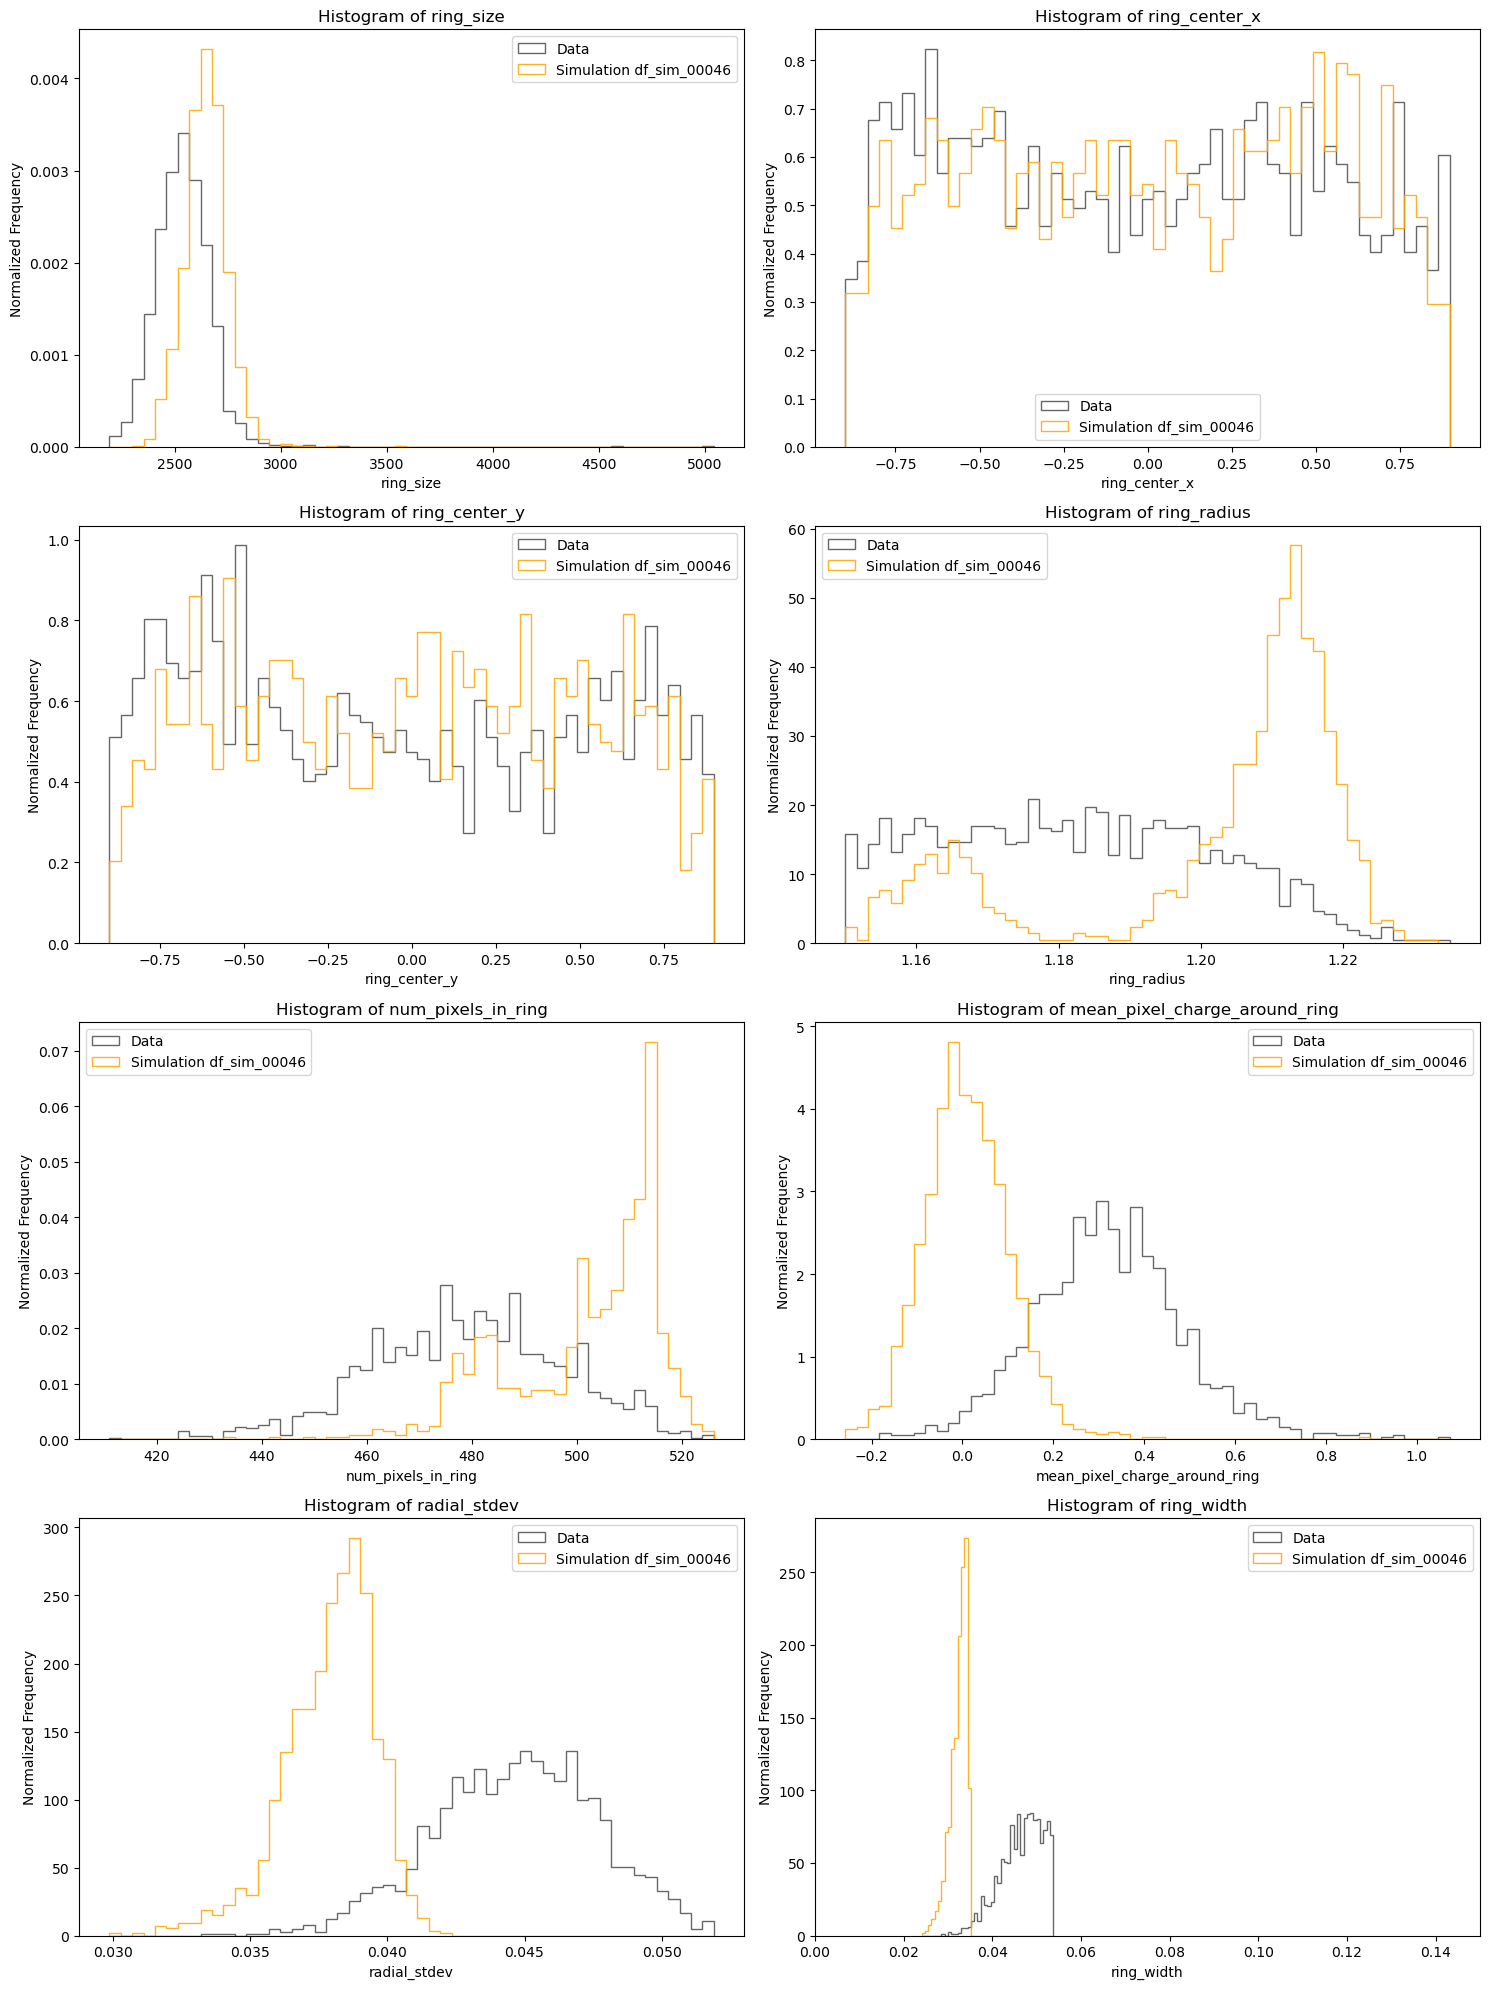



----------------------------------> Data + Simulation for mirror alignment _0015 deg




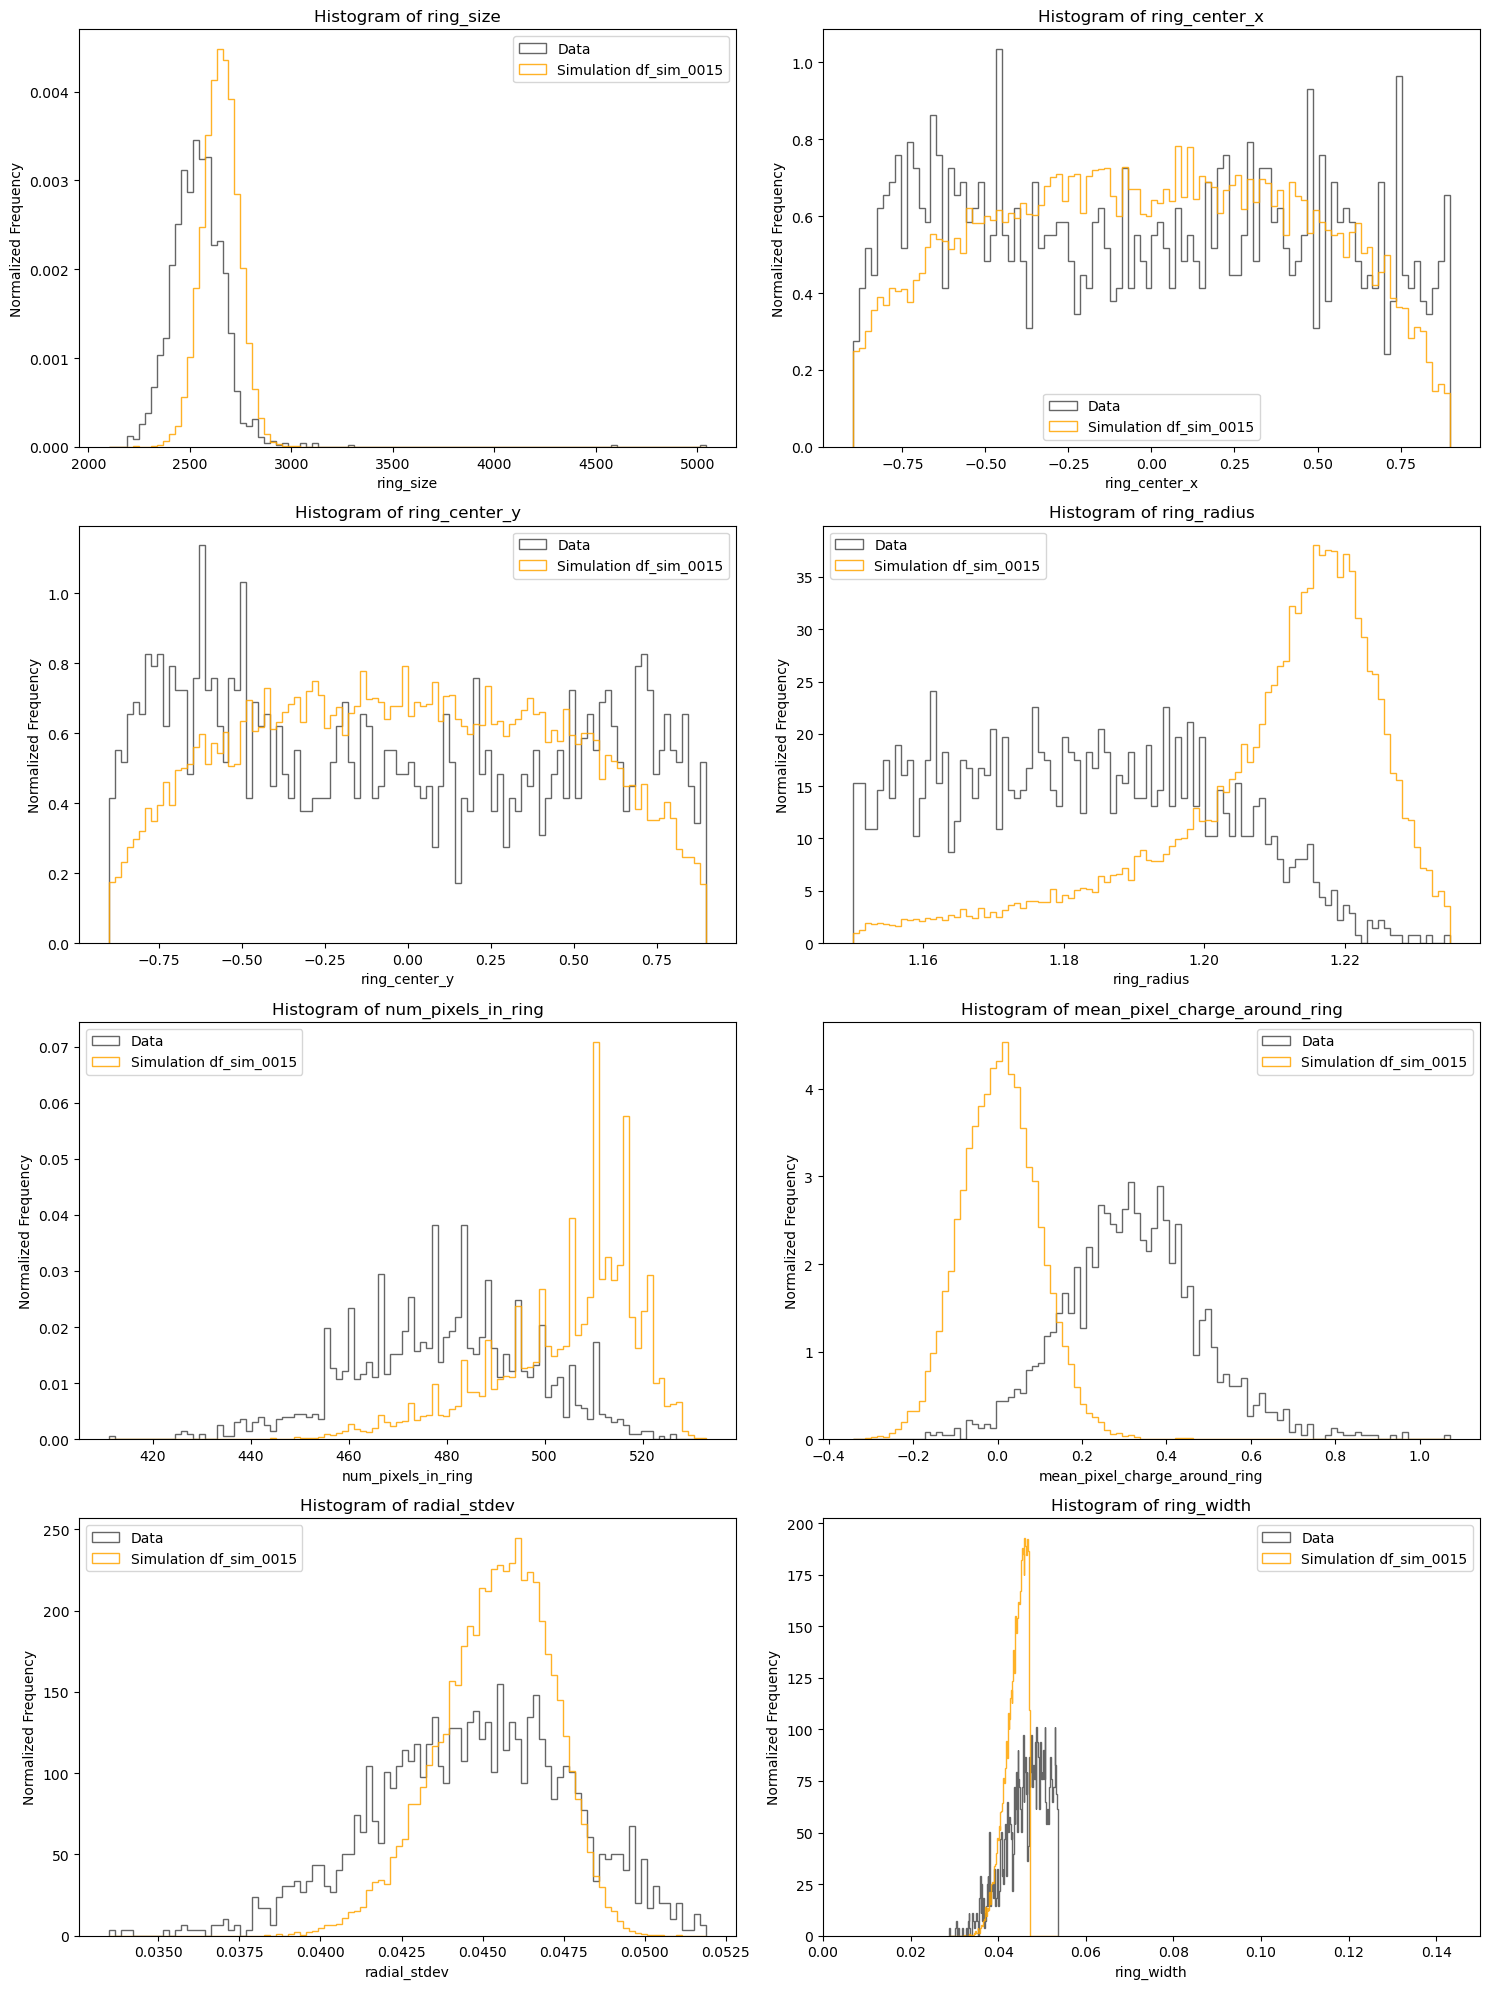

In [42]:
name_of_columns = ['ring_size', 'ring_center_x', 'ring_center_y', 'ring_radius', 'num_pixels_in_ring', 'mean_pixel_charge_around_ring', 'radial_stdev', 'ring_width']
for name,df in cut_datasets.items():
    if df_to_plot[name] and name != 'winter_data_2024':
        print('====================================================')
        print('====================================================')
        print('\n')
        print('----------------------------------> Data + Simulation for mirror alignment', name[-5:], 'deg')
        print('\n')
        print('====================================================')
        print('====================================================')
        plot_columns(cut_datasets['winter_data_2024'], df, name_of_columns, apply_weight=False, df_name = name)